# **Implementasi Optimasi Portofolio Saham IDX30 Menggunakan Adaptive Genetic Algorithm (AGA)**
---

> Notebook ini merupakan implementasi penelitian mengenai optimasi portofolio saham IDX30 menggunakan Adaptive Genetic Algorithm (AGA). Proses implementasi meliputi pengumpulan dan prapemrosesan data, pembentukan dataset penelitian, perhitungan statistik portofolio, perancangan fungsi fitness, hyperparameter tuning menggunakan Grid Search, implementasi Standard Genetic Algorithm (SGA) dan Adaptive Genetic Algorithm (AGA), evaluasi performa algoritma, serta visualisasi hasil optimasi.

#  Libraries

In [ ]:
# ============================================================
# Instalasi library tambahan
# ============================================================
!pip install -q gdown

In [ ]:
# ============================================================
# Import library yang digunakan dalam penelitian
# ============================================================
from google.colab import files
import gdown
import itertools
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import wilcoxon

# Inisialisasi Dataset

> Tahap ini bertujuan untuk mengunduh dataset hasil scraping dari Google Drive dan memuatnya ke dalam DataFrame sebagai data mentah penelitian.

In [ ]:
# ============================================================
# Mengunduh dan memuat dataset hasil scraping
# ============================================================

SCRAPING_URL = "https://drive.google.com/uc?id=1Luxbl6W4IL_1EafwiPJyz2LfbOzrXd3m"

gdown.download(
    SCRAPING_URL,
    "IDX30-Scraping.csv",
    quiet=False
)

df_raw = pd.read_csv("IDX30-Scraping.csv")
df_raw


Downloading...
From: https://drive.google.com/uc?id=1Luxbl6W4IL_1EafwiPJyz2LfbOzrXd3m
To: /content/IDX30-Scraping.csv
100%|██████████| 920k/920k [00:00<00:00, 47.1MB/s]


,Date,ticker,Close
0,2022-12-30,ADRO,1361.351929
1,2023-01-02,ADRO,1358.053223
2,2023-01-03,ADRO,1331.572998
3,2023-01-04,ADRO,1248.349854
4,2023-01-05,ADRO,1172.692261
...,...,...,...
30040,2026-01-20,AADI,7066.990234
30041,2026-01-21,AADI,6996.320312
30042,2026-01-22,AADI,7514.566406
30043,2026-01-23,AADI,7962.142578


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30045 entries, 0 to 30044
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    30045 non-null  object 
 1   ticker  30045 non-null  object 
 2   Close   30045 non-null  float64
dtypes: float64(1), object(2)
memory usage: 704.3+ KB


In [ ]:
saham_awal = df_raw['ticker'].unique()

In [ ]:
jumlah_awal = len(saham_awal)
jumlah_awal

42

# Preprocessing Data

> Tahap ini bertujuan untuk menyiapkan data mentah sebelum digunakan pada proses optimasi. Preprocessing meliputi konversi tipe data, pembersihan data yang tidak valid, serta pengurutan data berdasarkan emiten dan tanggal transaksi.

In [ ]:
# ============================================================
# Prapemrosesan data historis saham
# ============================================================

# Membuat salinan data mentah untuk diproses
df_preprocessed = df_raw.copy()

# Mengubah tipe data kolom tanggal
df_preprocessed["Date"] = pd.to_datetime(
    df_preprocessed["Date"]
)

# Mengubah harga penutupan menjadi numerik
df_preprocessed["Close"] = pd.to_numeric(
    df_preprocessed["Close"],
    errors="coerce"
)

# Menghapus data yang mengandung nilai tidak valid
df_preprocessed = df_preprocessed.dropna()

# Mengurutkan data berdasarkan emiten dan tanggal
df_preprocessed = (
    df_preprocessed
    .sort_values(["ticker", "Date"])
    .reset_index(drop=True)
)

# Menampilkan ukuran dataset hasil preprocessing
print("Shape preprocessing:", df_preprocessed.shape)

Shape preprocessing: (30045, 3)


In [ ]:
df_preprocessed

,Date,ticker,Close
0,2024-12-05,AADI,5880.733887
1,2024-12-06,AADI,7052.458984
2,2024-12-09,AADI,8445.264648
3,2024-12-10,AADI,9086.397461
4,2024-12-11,AADI,8489.480469
...,...,...,...
30040,2026-01-20,UNVR,2320.000000
30041,2026-01-21,UNVR,2290.000000
30042,2026-01-22,UNVR,2280.000000
30043,2026-01-23,UNVR,2250.000000


In [ ]:
df_preprocessed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30045 entries, 0 to 30044
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    30045 non-null  datetime64[ns]
 1   ticker  30045 non-null  object        
 2   Close   30045 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 704.3+ KB


In [ ]:
print("Jumlah data mentah :", len(df_raw))
print("Jumlah data preprocessing :", len(df_preprocessed))
print("Data dihapus :", len(df_raw)-len(df_preprocessed))

Jumlah data mentah : 30045
Jumlah data preprocessing : 30045
Data dihapus : 0


#Preparation

## | Dataset

> Tahap ini bertujuan untuk menentukan saham-saham yang secara konsisten terdaftar dalam indeks IDX30 pada seluruh periode observasi sehingga dataset penelitian memiliki komposisi aset yang tetap.

In [ ]:
# ============================================================
# Memuat daftar konstituen IDX30
# ============================================================

URL_IDX30 = "https://drive.google.com/uc?id=1ojgBgu0_aTLYO14uwNG7kA7AGulREFYt"
FILE_IDX30 = "IDX30-list.csv"

gdown.download(URL_IDX30, FILE_IDX30, quiet=False)

df_idx30 = pd.read_csv(FILE_IDX30)

# Menampilkan jumlah saham unik dalam data IDX30
print("Jumlah saham unik:", df_idx30["ticker"].nunique())


# ============================================================
# Menyeleksi saham IDX30 yang konsisten
# ============================================================

# Mengelompokkan ticker berdasarkan tahun dan periode evaluasi
period_groups = (
    df_idx30
    .groupby(["tahun", "periode"])["ticker"]
    .apply(set)
    .tolist()
)

# Menentukan irisan ticker yang muncul pada seluruh periode
selected_tickers = sorted(
    list(set.intersection(*period_groups))
)

# Menampilkan daftar saham hasil seleksi
selected_tickers

Downloading...
From: https://drive.google.com/uc?id=1ojgBgu0_aTLYO14uwNG7kA7AGulREFYt
To: /content/IDX30-list.csv
100%|██████████| 7.55k/7.55k [00:00<00:00, 17.2MB/s]

Jumlah saham unik: 42


['ADRO',
 'AMRT',
 'ANTM',
 'ASII',
 'BBCA',
 'BBNI',
 'BBRI',
 'BMRI',
 'BRPT',
 'CPIN',
 'GOTO',
 'INCO',
 'INDF',
 'KLBF',
 'MDKA',
 'MEDC',
 'PGAS',
 'PTBA',
 'SMGR',
 'TLKM',
 'UNTR',
 'UNVR']

In [ ]:
# ============================================================
# Membentuk dataset penelitian
# ============================================================

# Menyeleksi data saham yang termasuk dalam ticker terpilih
df_selected = df_preprocessed[
    df_preprocessed["ticker"].isin(selected_tickers)
].copy()

# Mengurutkan data berdasarkan emiten dan tanggal transaksi
df_selected = df_selected.sort_values(
    ["ticker", "Date"]
)
df_selected

,Date,ticker,Close
997,2022-12-30,ADRO,1361.351929
998,2023-01-02,ADRO,1358.053223
999,2023-01-03,ADRO,1331.572998
1000,2023-01-04,ADRO,1248.349854
1001,2023-01-05,ADRO,1172.692261
...,...,...,...
30040,2026-01-20,UNVR,2320.000000
30041,2026-01-21,UNVR,2290.000000
30042,2026-01-22,UNVR,2280.000000
30043,2026-01-23,UNVR,2250.000000


In [ ]:

# Menghitung return harian (Rit) menggunakan simple return
df_selected["Rit"] = (
    df_selected
    .groupby("ticker")["Close"]
    .pct_change()
)

# Menampilkan dataset penelitian
df_selected

,Date,ticker,Close,Rit
997,2022-12-30,ADRO,1361.351929,NaN
998,2023-01-02,ADRO,1358.053223,-0.002423
999,2023-01-03,ADRO,1331.572998,-0.019499
1000,2023-01-04,ADRO,1248.349854,-0.062500
1001,2023-01-05,ADRO,1172.692261,-0.060606
...,...,...,...,...
30040,2026-01-20,UNVR,2320.000000,-0.004292
30041,2026-01-21,UNVR,2290.000000,-0.012931
30042,2026-01-22,UNVR,2280.000000,-0.004367
30043,2026-01-23,UNVR,2250.000000,-0.013158


> Tahap ini membagi dataset penelitian menjadi data pelatihan, validasi, dan pengujian berdasarkan periode waktu yang digunakan dalam penelitian.

In [ ]:
# ============================================================
# Membagi dataset menjadi train, validation, dan test
# ============================================================

df_train = df_selected[
    (df_selected["Date"] >= "2023-01-01") &
    (df_selected["Date"] <= "2024-07-31")
]

df_val = df_selected[
    (df_selected["Date"] > "2024-07-31") &
    (df_selected["Date"] <= "2025-01-27")
]

df_test = df_selected[
    (df_selected["Date"] > "2025-01-27") &
    (df_selected["Date"] <= "2026-01-26")
]

In [ ]:
# ============================================================
# Memverifikasi hasil pembagian dataset
# ============================================================

print("Train :", df_train["Date"].min(), "-", df_train["Date"].max())
print("Val   :", df_val["Date"].min(), "-", df_val["Date"].max())
print("Test  :", df_test["Date"].min(), "-", df_test["Date"].max())

# Memastikan tidak terdapat overlap antar periode
print("\nOverlap check:")
print(set(df_train["Date"]).intersection(set(df_val["Date"])))
print(set(df_val["Date"]).intersection(set(df_test["Date"])))

Train : 2023-01-02 00:00:00 - 2024-07-31 00:00:00
Val   : 2024-08-01 00:00:00 - 2025-01-24 00:00:00
Test  : 2025-01-30 00:00:00 - 2026-01-26 00:00:00

Overlap check:
set()
set()


## | Perhitungan Return, Rata-Rata Return, dan Matriks Kovarians**  

> Tahap ini menghitung **return harian saham**, **rata-rata return (μ)**, dan **matriks kovarians** dari data pelatihan, validasi, dan pengujian. Nilai rata-rata return digunakan untuk merepresentasikan tingkat keuntungan yang diharapkan dari setiap saham, sedangkan matriks kovarians digunakan untuk mengukur hubungan pergerakan antar saham sebagai dasar perhitungan risiko portofolio.

In [ ]:
# ============================================================
# Menghitung statistik portofolio
# ============================================================

def compute_statistics(df):
    """
    Membentuk return matrix serta menghitung rata-rata return
    dan matriks kovarians.
    """

    # Membentuk return matrix (tanggal × saham)
    returns = df.pivot(
        index="Date",
        columns="ticker",
        values="Rit"
    )

    # Menghapus observasi yang masih mengandung nilai kosong
    returns = returns.dropna()

    # Menghitung rata-rata return dan matriks kovarians
    mu = returns.mean()
    cov_matrix = returns.cov()

    return mu, cov_matrix, returns

In [ ]:
# ============================================================
# Menghitung statistik pada data pelatihan
# ============================================================

mu_train, cov_train, returns_train = compute_statistics(
    df_train
)

In [ ]:
mu_train

,0
ticker,
ADRO,0.000622
AMRT,0.000388
ANTM,-0.000600
ASII,0.000118
BBCA,0.000698
BBNI,0.000556
BBRI,0.000274
BMRI,0.001087
BRPT,0.001848


In [ ]:
cov_train

ticker,ADRO,AMRT,ANTM,ASII,BBCA,BBNI,BBRI,BMRI,BRPT,CPIN,...,INDF,KLBF,MDKA,MEDC,PGAS,PTBA,SMGR,TLKM,UNTR,UNVR
ticker,,,,,,,,,,,,,,,,,,,,,
ADRO,0.000448,0.000031,0.000113,4.855426e-05,2.619020e-05,0.000016,0.000032,0.000030,0.000129,7.040770e-06,...,-0.000007,-1.014611e-05,0.000092,0.000260,0.000139,0.000250,0.000019,0.000002,0.000221,1.450398e-05
AMRT,0.000031,0.000304,0.000016,4.024059e-05,4.396640e-05,0.000040,0.000058,0.000047,0.000064,1.017699e-04,...,0.000032,3.209720e-05,0.000033,-0.000029,0.000042,0.000006,0.000041,0.000035,0.000029,1.832095e-05
ANTM,0.000113,0.000016,0.000365,3.652455e-05,1.662186e-05,0.000027,0.000029,0.000039,0.000071,3.365228e-05,...,0.000002,-2.530589e-05,0.000199,0.000146,0.000057,0.000107,0.000038,0.000011,0.000079,-3.692290e-05
ASII,0.000049,0.000040,0.000037,2.295580e-04,3.369717e-05,0.000040,0.000065,0.000047,0.000102,3.313004e-07,...,0.000031,2.846167e-05,0.000034,0.000058,0.000065,0.000072,0.000068,0.000052,0.000092,9.951405e-06
BBCA,0.000026,0.000044,0.000017,3.369717e-05,1.544494e-04,0.000074,0.000089,0.000095,0.000040,3.616040e-05,...,0.000020,1.460605e-05,0.000013,0.000023,0.000016,0.000026,0.000033,0.000040,0.000021,6.054222e-07
BBNI,0.000016,0.000040,0.000027,4.043978e-05,7.411880e-05,0.000232,0.000127,0.000147,0.000058,2.508060e-05,...,0.000031,1.052727e-05,0.000063,0.000006,0.000018,0.000039,0.000059,0.000055,0.000007,6.848834e-06
BBRI,0.000032,0.000058,0.000029,6.517196e-05,8.931197e-05,0.000127,0.000242,0.000130,0.000079,5.402922e-05,...,0.000025,2.981267e-05,0.000039,0.000026,0.000045,0.000040,0.000057,0.000050,0.000017,1.271213e-05
BMRI,0.000030,0.000047,0.000039,4.661906e-05,9.481301e-05,0.000147,0.000130,0.000270,0.000067,4.527891e-05,...,0.000022,1.981973e-05,0.000083,0.000061,0.000031,0.000061,0.000062,0.000043,0.000032,-1.182911e-05
BRPT,0.000129,0.000064,0.000071,1.016655e-04,3.972264e-05,0.000058,0.000079,0.000067,0.001755,1.574827e-04,...,0.000019,3.330580e-05,0.000112,0.000213,0.000063,0.000075,0.000118,0.000067,0.000046,6.725163e-05


In [ ]:
returns_train

ticker,ADRO,AMRT,ANTM,ASII,BBCA,BBNI,BBRI,BMRI,BRPT,CPIN,...,INDF,KLBF,MDKA,MEDC,PGAS,PTBA,SMGR,TLKM,UNTR,UNVR
Date,,,,,,,,,,,,,,,,,,,,,
2023-01-02,-0.002423,0.033962,-0.002519,0.000000,0.000000,0.000000,-0.014170,-0.005038,0.013245,0.004425,...,0.007435,-0.014354,0.002427,0.073892,-0.011364,0.000000,0.007604,0.013333,-0.010546,-0.017021
2023-01-03,-0.019499,0.010949,0.010101,-0.008772,0.000000,0.005420,-0.004107,0.007595,0.058824,0.017621,...,-0.003690,0.029126,0.046005,0.022936,-0.002874,0.010840,0.011321,0.015790,0.003876,-0.004329
2023-01-04,-0.062500,-0.010830,0.025000,0.004425,-0.023392,-0.010782,-0.016495,0.007538,-0.018519,-0.017316,...,0.014815,-0.014151,0.000000,-0.035874,-0.043228,-0.029491,0.011194,-0.010363,-0.067567,0.008696
2023-01-05,-0.060606,0.025547,-0.041463,-0.052863,-0.011976,-0.019074,-0.027254,-0.019950,-0.012579,0.030837,...,0.000000,-0.009569,-0.027778,-0.069767,-0.063253,-0.058011,-0.011070,-0.013089,0.021739,0.019397
2023-01-06,0.012903,-0.003559,0.010178,0.013953,0.006061,-0.011111,-0.004310,-0.002544,0.044586,0.025641,...,0.014599,-0.009662,0.021429,0.035000,0.019293,0.005865,0.055970,-0.015915,0.012158,0.006343
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-25,-0.012618,0.003509,-0.022901,-0.008830,0.022333,-0.014706,-0.016736,0.015444,-0.028169,0.004630,...,0.016667,0.009524,0.008299,0.000000,-0.018927,-0.003817,-0.019704,0.009804,0.003021,-0.084559
2024-07-26,0.015975,-0.003497,0.011719,0.026726,0.002427,-0.004975,0.012766,-0.003802,0.028986,-0.023041,...,0.004098,-0.009434,-0.016461,0.043307,0.016077,0.019157,0.007538,0.003236,0.003012,0.000000
2024-07-29,0.000000,-0.003509,0.011583,0.000000,-0.007264,0.005000,0.004202,-0.011450,0.023474,-0.023585,...,-0.008163,-0.009524,0.004184,-0.011321,0.015823,0.003759,-0.004988,-0.016129,-0.012012,-0.012048


In [ ]:
_, _, returns_val = compute_statistics(df_val)
_, _, returns_test  = compute_statistics(df_test )

In [ ]:
# ============================================================
# Expected Return Setiap Saham
# ============================================================


expected_return_df = mu_train.reset_index()

expected_return_df.columns = [
    "Ticker",
    "Expected Return"
]

# Membulatkan menjadi 5 angka di belakang koma
expected_return_df["Expected Return"] = (
    expected_return_df["Expected Return"]
    .round(6)
)

display(expected_return_df)

expected_return_df.to_csv(
    "expected_return_per_saham.csv",
    index=False
)

files.download("expected_return_per_saham.csv")

,Ticker,Expected Return
0,ADRO,0.000622
1,AMRT,0.000388
2,ANTM,-0.000600
3,ASII,0.000118
4,BBCA,0.000698
5,BBNI,0.000556
6,BBRI,0.000274
7,BMRI,0.001087
8,BRPT,0.001848
9,CPIN,0.000047


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# Matriks kovarians return saham
# ============================================================

covariance_df = cov_train.copy()

display(covariance_df)

covariance_df.to_csv(
    "covariance_matrix.csv"
)

files.download("covariance_matrix.csv")

ticker,ADRO,AMRT,ANTM,ASII,BBCA,BBNI,BBRI,BMRI,BRPT,CPIN,...,INDF,KLBF,MDKA,MEDC,PGAS,PTBA,SMGR,TLKM,UNTR,UNVR
ticker,,,,,,,,,,,,,,,,,,,,,
ADRO,0.000448,0.000031,0.000113,4.855426e-05,2.619020e-05,0.000016,0.000032,0.000030,0.000129,7.040770e-06,...,-0.000007,-1.014611e-05,0.000092,0.000260,0.000139,0.000250,0.000019,0.000002,0.000221,1.450398e-05
AMRT,0.000031,0.000304,0.000016,4.024059e-05,4.396640e-05,0.000040,0.000058,0.000047,0.000064,1.017699e-04,...,0.000032,3.209720e-05,0.000033,-0.000029,0.000042,0.000006,0.000041,0.000035,0.000029,1.832095e-05
ANTM,0.000113,0.000016,0.000365,3.652455e-05,1.662186e-05,0.000027,0.000029,0.000039,0.000071,3.365228e-05,...,0.000002,-2.530589e-05,0.000199,0.000146,0.000057,0.000107,0.000038,0.000011,0.000079,-3.692290e-05
ASII,0.000049,0.000040,0.000037,2.295580e-04,3.369717e-05,0.000040,0.000065,0.000047,0.000102,3.313004e-07,...,0.000031,2.846167e-05,0.000034,0.000058,0.000065,0.000072,0.000068,0.000052,0.000092,9.951405e-06
BBCA,0.000026,0.000044,0.000017,3.369717e-05,1.544494e-04,0.000074,0.000089,0.000095,0.000040,3.616040e-05,...,0.000020,1.460605e-05,0.000013,0.000023,0.000016,0.000026,0.000033,0.000040,0.000021,6.054222e-07
BBNI,0.000016,0.000040,0.000027,4.043978e-05,7.411880e-05,0.000232,0.000127,0.000147,0.000058,2.508060e-05,...,0.000031,1.052727e-05,0.000063,0.000006,0.000018,0.000039,0.000059,0.000055,0.000007,6.848834e-06
BBRI,0.000032,0.000058,0.000029,6.517196e-05,8.931197e-05,0.000127,0.000242,0.000130,0.000079,5.402922e-05,...,0.000025,2.981267e-05,0.000039,0.000026,0.000045,0.000040,0.000057,0.000050,0.000017,1.271213e-05
BMRI,0.000030,0.000047,0.000039,4.661906e-05,9.481301e-05,0.000147,0.000130,0.000270,0.000067,4.527891e-05,...,0.000022,1.981973e-05,0.000083,0.000061,0.000031,0.000061,0.000062,0.000043,0.000032,-1.182911e-05
BRPT,0.000129,0.000064,0.000071,1.016655e-04,3.972264e-05,0.000058,0.000079,0.000067,0.001755,1.574827e-04,...,0.000019,3.330580e-05,0.000112,0.000213,0.000063,0.000075,0.000118,0.000067,0.000046,6.725163e-05


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# Ringkasan matriks kovarians
# ============================================================

from google.colab import files

covariance_values = cov_train.values

# Elemen diagonal (variansi masing-masing saham)
diagonal_values = np.diag(covariance_values)

# Elemen di luar diagonal (kovarians antar saham)
off_diagonal_values = covariance_values[
    ~np.eye(covariance_values.shape[0], dtype=bool)
]

summary_covariance = pd.DataFrame({
    "Keterangan": [
        "Ukuran matriks kovarians",
        "Jumlah elemen diagonal (variansi)",
        "Kovarians minimum",
        "Kovarians maksimum",
        "Rata-rata kovarians",
        "Rata-rata variansi"
    ],
    "Nilai": [
        f"{cov_train.shape[0]} × {cov_train.shape[1]}",
        len(diagonal_values),
        f"{off_diagonal_values.min():.5f}",
        f"{off_diagonal_values.max():.5f}",
        f"{off_diagonal_values.mean():.5f}",
        f"{diagonal_values.mean():.5f}"
    ]
})

display(summary_covariance)

,Keterangan,Nilai
0,Ukuran matriks kovarians,22 × 22
1,Jumlah elemen diagonal (variansi),22
2,Kovarians minimum,-0.00006
3,Kovarians maksimum,0.00026
4,Rata-rata kovarians,0.00005
5,Rata-rata variansi,0.00052


In [ ]:
summary_covariance.to_csv(
    "summary_covariance.csv",
    index=False
)

files.download("summary_covariance.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

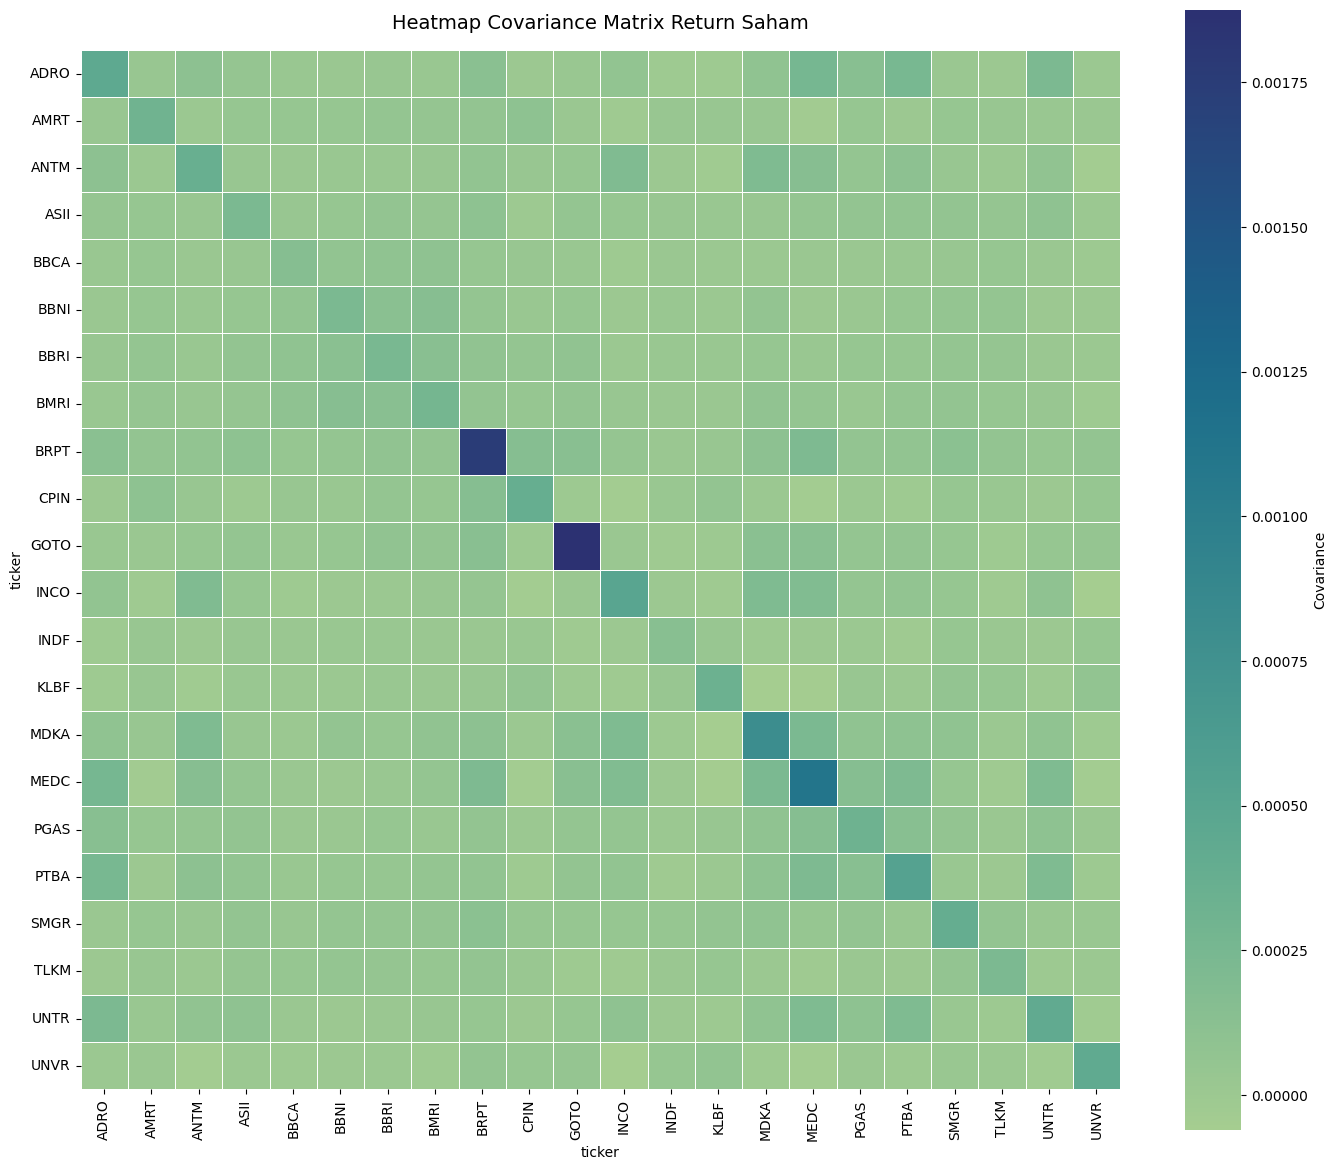

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# Heatmap covariance matrix
# ============================================================

covariance_df = cov_train.copy()

plt.figure(figsize=(14, 12))

sns.heatmap(
    covariance_df,
    cmap="crest",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Covariance"}
)

plt.title(
    "Heatmap Covariance Matrix Return Saham",
    fontsize=14,
    pad=15
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "heatmap_covariance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

files.download("heatmap_covariance.png")

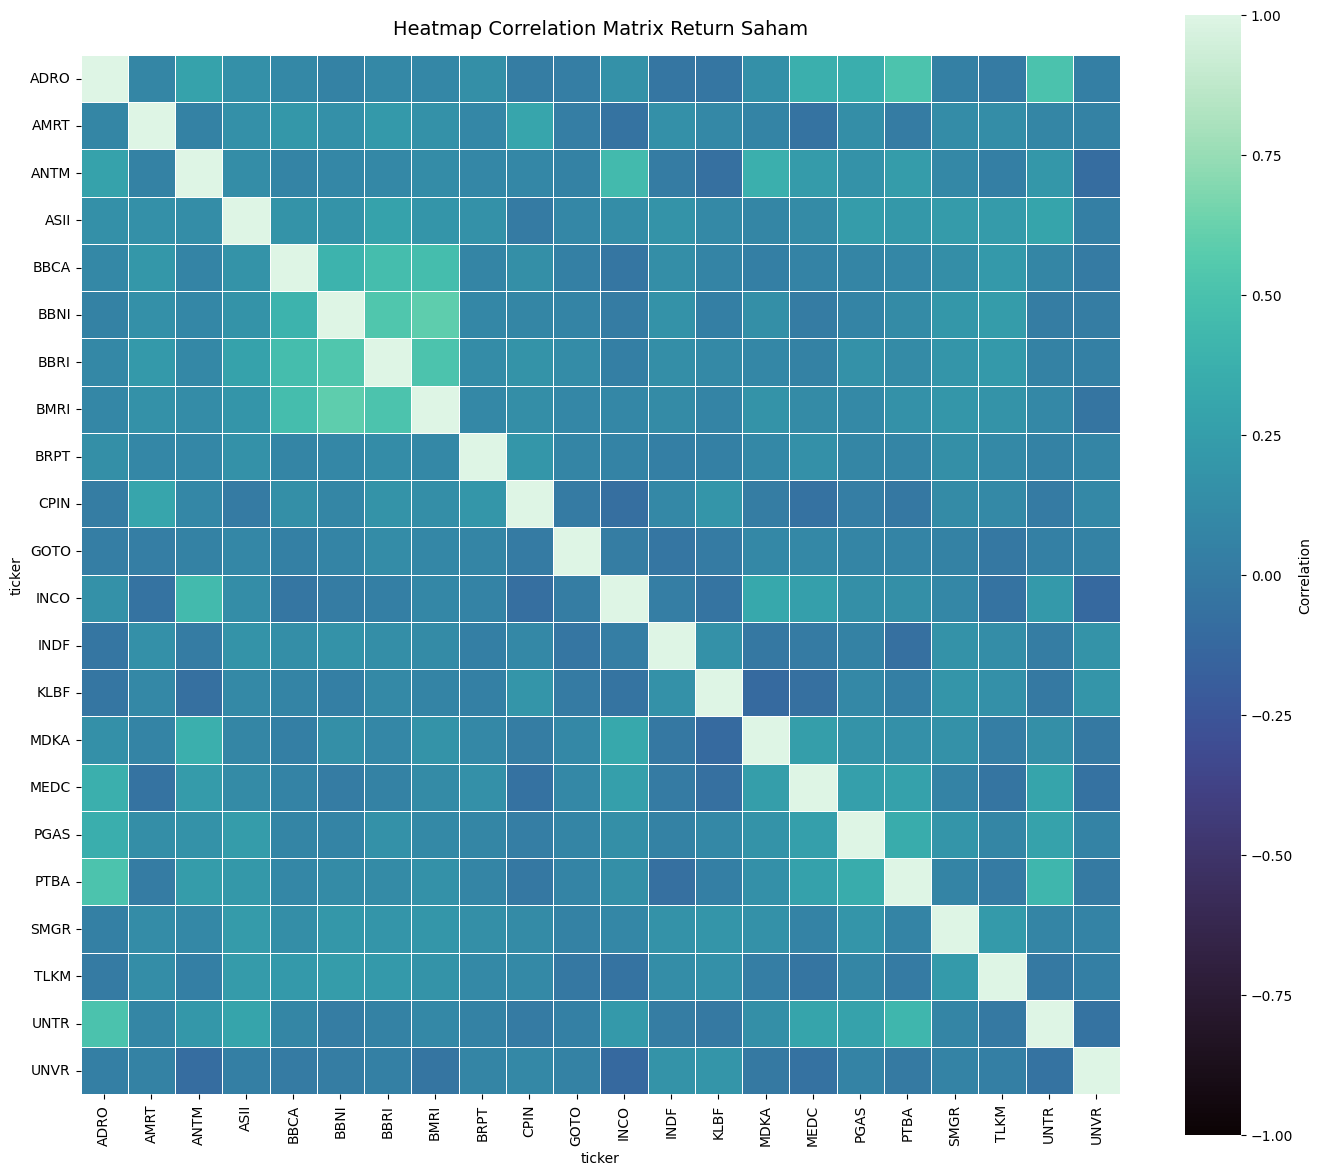

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# Correlation matrix
# ============================================================

correlation_df = returns_train.corr()

# ============================================================
# Heatmap correlation matrix
# ============================================================

import seaborn as sns

plt.figure(figsize=(14, 12))

sns.heatmap(
    correlation_df,
    cmap="mako",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation"}
)

plt.title(
    "Heatmap Correlation Matrix Return Saham",
    fontsize=14,
    pad=15
)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "heatmap_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

files.download("heatmap_correlation.png")

In [ ]:
# ============================================================
# Ringkasan statistik return harian data pelatihan
# ============================================================

from google.colab import files

# Gabungkan seluruh return menjadi satu vektor
all_returns = returns_train.values.flatten()

# Hapus nilai kosong (jika ada)
all_returns = all_returns[~np.isnan(all_returns)]

summary_return = pd.DataFrame({
    "Statistik": [
        "Jumlah saham",
        "Total observasi",
        "Return harian minimum",
        "Return harian maksimum",
        "Rata-rata return harian",
        "Standar deviasi return harian"
    ],
    "Nilai": [
        returns_train.shape[1],
        len(all_returns),
        all_returns.min(),
        all_returns.max(),
        all_returns.mean(),
        all_returns.std(ddof=1)
    ]
})

display(summary_return)

# ============================================================
# Simpan hasil
# ============================================================

summary_return.to_csv(
    "summary_daily_return.csv",
    index=False
)

files.download("summary_daily_return.csv")

,Statistik,Nilai
0,Jumlah saham,22.000000
1,Total observasi,8184.000000
2,Return harian minimum,-0.203704
3,Return harian maksimum,0.348624
4,Rata-rata return harian,0.000115
5,Standar deviasi return harian,0.022840


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# Ringkasan Statistik Tambahan untuk BAB IV
# ============================================================

print("=" * 60)
print("RINGKASAN DATASET PENELITIAN")
print("=" * 60)

# ------------------------------------------------------------
# Ringkasan preprocessing
# ------------------------------------------------------------
print("\n[1] PREPROCESSING DATA")
print(f"Jumlah data mentah                : {len(df_raw):,}")
print(f"Jumlah data preprocessing         : {len(df_preprocessed):,}")
print(f"Data dihapus                     : {len(df_raw) - len(df_preprocessed):,}")

print(f"Jumlah saham awal                : {df_raw['ticker'].nunique()}")
print(f"Jumlah saham konsisten           : {len(selected_tickers)}")

# ------------------------------------------------------------
# Ringkasan dataset
# ------------------------------------------------------------
print("\n[2] PEMBAGIAN DATASET")

print(f"Training")
print(f"  Periode        : {df_train['Date'].min().date()} s.d. {df_train['Date'].max().date()}")
print(f"  Hari trading   : {len(returns_train)}")

print(f"\nValidation")
print(f"  Periode        : {df_val['Date'].min().date()} s.d. {df_val['Date'].max().date()}")
print(f"  Hari trading   : {len(returns_val)}")

print(f"\nTesting")
print(f"  Periode        : {df_test['Date'].min().date()} s.d. {df_test['Date'].max().date()}")
print(f"  Hari trading   : {len(returns_test)}")

# ------------------------------------------------------------
# Expected Return
# ------------------------------------------------------------
print("\n[3] EXPECTED RETURN")

print(f"Jumlah saham                     : {len(mu_train)}")
print(f"Expected return positif          : {(mu_train > 0).sum()}")
print(f"Expected return negatif          : {(mu_train < 0).sum()}")

print(f"Minimum                          : {mu_train.min():.6f}")
print(f"Maksimum                         : {mu_train.max():.6f}")
print(f"Rata-rata                        : {mu_train.mean():.6f}")
print(f"Standar deviasi                  : {mu_train.std():.6f}")

# ------------------------------------------------------------
# Kovarians
# ------------------------------------------------------------
print("\n[4] MATRIKS KOVARIANS")

cov_values = cov_train.values

off_diag = cov_values[np.triu_indices_from(cov_values, k=1)]
diag = np.diag(cov_values)

print(f"Ukuran matriks                   : {cov_train.shape[0]} x {cov_train.shape[1]}")
print(f"Jumlah variansi (diagonal)       : {len(diag)}")

print(f"Kovarians positif                : {(off_diag > 0).sum()}")
print(f"Kovarians negatif                : {(off_diag < 0).sum()}")
print(f"Kovarians nol                    : {(off_diag == 0).sum()}")

print(f"Kovarians minimum                : {off_diag.min():.6f}")
print(f"Kovarians maksimum               : {off_diag.max():.6f}")

print(f"Rata-rata kovarians              : {off_diag.mean():.6f}")
print(f"Rata-rata variansi               : {diag.mean():.6f}")

# ------------------------------------------------------------
# Korelasi
# ------------------------------------------------------------
print("\n[5] MATRIKS KORELASI")

corr = returns_train.corr().values
corr_upper = corr[np.triu_indices_from(corr, k=1)]

strong = np.sum(corr_upper >= 0.70)
moderate = np.sum((corr_upper >= 0.30) & (corr_upper < 0.70))
weak = np.sum((corr_upper >= 0.00) & (corr_upper < 0.30))
negative = np.sum(corr_upper < 0.00)

print(f"Korelasi kuat (>=0.70)           : {strong}")
print(f"Korelasi sedang (0.30-0.69)      : {moderate}")
print(f"Korelasi lemah (0.00-0.29)       : {weak}")
print(f"Korelasi negatif (<0.00)         : {negative}")

print(f"Korelasi minimum                 : {corr_upper.min():.4f}")
print(f"Korelasi maksimum                : {corr_upper.max():.4f}")
print(f"Rata-rata korelasi               : {corr_upper.mean():.4f}")

print("=" * 60)
print("SELESAI")
print("=" * 60)

RINGKASAN DATASET PENELITIAN

[1] PREPROCESSING DATA
Jumlah data mentah                : 30,045
Jumlah data preprocessing         : 30,045
Data dihapus                     : 0
Jumlah saham awal                : 42
Jumlah saham konsisten           : 22

[2] PEMBAGIAN DATASET
Training
  Periode        : 2023-01-02 s.d. 2024-07-31
  Hari trading   : 372

Validation
  Periode        : 2024-08-01 s.d. 2025-01-24
  Hari trading   : 121

Testing
  Periode        : 2025-01-30 s.d. 2026-01-26
  Hari trading   : 235

[3] EXPECTED RETURN
Jumlah saham                     : 22
Expected return positif          : 14
Expected return negatif          : 8
Minimum                          : -0.001440
Maksimum                         : 0.001848
Rata-rata                        : 0.000115
Standar deviasi                  : 0.000888

[4] MATRIKS KOVARIANS
Ukuran matriks                   : 22 x 22
Jumlah variansi (diagonal)       : 22
Kovarians positif                : 204
Kovarians negatif                :

# Fungsi Objektif

In [ ]:
# ============================================================
# Inisialisasi parameter fungsi fitness
# ============================================================

# Nilai awal sebelum proses hyperparameter tuning
max_weight = 0.3
lambda_div_default = 0.1

In [ ]:
# ============================================================
# Fungsi fitness optimasi portofolio
# ============================================================

def fitness_function(
    weights,
    mu,
    cov_matrix,
    lambda_div=lambda_div_default,
    max_weight=max_weight
):
    """
    Menghitung nilai fitness berbasis minimisasi dengan
    mengintegrasikan Sharpe Ratio, diversification penalty,
    dan maximum weight penalty.
    """

    # Mengubah bobot menjadi numpy array
    weights = np.array(weights)

    # Menghitung expected return portofolio
    E = weights @ mu

    # Menghitung risiko portofolio (standar deviasi)
    V = weights.T @ cov_matrix @ weights
    sigma = np.sqrt(V + 1e-6)

    # Menghitung Sharpe Ratio
    sharpe = E / sigma

    # Menghitung diversification penalty
    diversification = np.sum(weights**2)

    # Menghitung penalti pelanggaran batas bobot
    penalty_max = 0

    if max_weight is not None:
        violations = np.maximum(
            0,
            weights - max_weight
        )

        penalty_max = (
            1000 * np.sum(violations**2)
        )

    # Menghitung nilai fitness akhir
    fitness = (
        -sharpe
        + (lambda_div * diversification)
        + penalty_max
    )

    return fitness

#Set Random

In [ ]:
# ============================================================
# Inisialisasi random seed
# ============================================================

SEED = 29

# Menjamin reproduktibilitas hasil eksperimen
np.random.seed(SEED)
random.seed(SEED)

# Default Algorithm

In [ ]:
# ============================================================
# Inisialisasi populasi
# ============================================================

def initialize_population(
    pop_size,
    n_assets,
    max_weight=max_weight
):
    """
    Membentuk populasi awal portofolio secara acak
    dengan mempertimbangkan batas maksimum bobot aset.
    """

    pop = []

    for _ in range(pop_size):
        w = np.random.rand(n_assets)

        # Membatasi bobot sesuai maximum weight
        w = np.minimum(w, max_weight)

        # Normalisasi agar total bobot sama dengan 1
        w /= w.sum()

        pop.append(w)

    return np.array(pop)

In [ ]:
# ============================================================
# Seleksi individu menggunakan tournament selection
# ============================================================

def tournament_selection(
    population,
    fitness,
    k=3
):
    """
    Memilih individu terbaik dari sejumlah kandidat
    yang dipilih secara acak.
    """

    idx = np.random.choice(
        len(population),
        k,
        replace=False
    )

    best = idx[np.argmin(fitness[idx])]

    return int(best)

In [ ]:
# ============================================================
# Perbaikan bobot portofolio
# ============================================================

def repair_weights(
    w,
    max_weight=max_weight
):
    """
    Memastikan bobot portofolio memenuhi seluruh
    kendala investasi.
    """

    # Membatasi bobot pada rentang yang diperbolehkan
    w = np.clip(w, 0, max_weight)

    total = w.sum()

    # Menginisialisasi ulang apabila seluruh bobot bernilai nol
    if total == 0:
        w = np.clip(
            np.random.rand(len(w)),
            0,
            max_weight
        )

        total = w.sum()

    # Normalisasi awal
    w = w / total

    # Redistribusi bobot yang melebihi batas maksimum
    max_iters = 15
    iters = 0

    # Redistribusi bobot yang melebihi batas maksimum
    max_iters = 15
    iters = 0

    while np.any(w > max_weight) and iters < max_iters:

        # Hitung total kelebihan bobot yang melanggar constraint
        excess = w - max_weight
        excess[excess < 0] = 0
        total_excess = excess.sum()

        # Batasi bobot agar tidak melebihi max_weight
        w = np.minimum(w, max_weight)

        # Identifikasi saham yang masih dapat menerima alokasi
        idx_under_max = w < max_weight
        sum_under_max = w[idx_under_max].sum()
        count_under_max = np.sum(idx_under_max)

        if count_under_max > 0:

            # Redistribusi kelebihan bobot secara proporsional
            # atau merata jika seluruh bobot bernilai nol
            if sum_under_max > 0:
                w[idx_under_max] += (
                    total_excess * (w[idx_under_max] / sum_under_max)
                )
            else:
                w[idx_under_max] += (
                    total_excess / count_under_max
                )
        else:
            break

        iters += 1

    # Normalisasi agar total bobot portofolio kembali menjadi 100%
    return w / w.sum()

    # Normalisasi akhir
    return w / w.sum()

In [ ]:
# ============================================================
# Arithmetic crossover
# ============================================================

def crossover(
    p1,
    p2,
    pc=0.9
):
    """
    Membentuk offspring melalui kombinasi linier
    dua parent.
    """

    if np.random.rand() > pc:
        return p1.copy()

    alpha = np.random.rand()

    child = (
        alpha * p1
        + (1 - alpha) * p2
    )

    return child

In [ ]:
# ============================================================
# Gaussian mutation
# ============================================================

def mutation(
    individual,
    pm=0.1,
    scale=0.05,
    max_weight=max_weight
):
    """
    Melakukan mutasi menggunakan distribusi Gaussian
    pada setiap gen sesuai probabilitas mutasi.
    """

    child = individual.copy()

    for i in range(len(child)):

        if np.random.rand() < pm:
            child[i] += np.random.normal(
                0,
                scale
            )

    return child

# Standard Genetic Algorithm (SGA)

In [ ]:
# =========================
# Genetic Algorithm (Standard)
# =========================
def genetic_algorithm(
    mu,
    cov_matrix,
    pop_size=100,
    generations=100,
    max_weight=max_weight,
    seed=SEED,
    init_pop=None,
    save_pop_history=False,
    pc=0.9,
    pm=0.1
):
    start_time = time.time()
    np.random.seed(seed)
    n_assets = len(mu)

    if init_pop is not None:
        population = init_pop.copy()
    else:
        population = initialize_population(pop_size, n_assets, max_weight)

    # =========================
    # Logging Metrics (Sama dengan AGA)
    # =========================
    best_hist = []
    avg_hist = []
    diversity_hist = []

    pc_hist = []
    pm_hist = []

    best_weights_history = []
    pop_history = []

    global_best_fitness = np.inf
    global_best_weights = None

    last_improvement_gen = None
    tol = 1e-6

    # =========================
    # Main Loop
    # =========================
    for gen in range(generations):

        fitness = np.array([
            fitness_function(w, mu, cov_matrix)
            for w in population
        ])

        best_idx = np.argmin(fitness)
        best_fit = fitness[best_idx]

        # =========================
        # Tracking Global Best
        # =========================
        if best_fit < global_best_fitness - tol:
            global_best_fitness = best_fit
            global_best_weights = population[best_idx].copy()
            last_improvement_gen = gen

        # =========================
        # Logging
        # =========================
        best_hist.append(best_fit)
        avg_hist.append(fitness.mean())
        diversity_hist.append(np.mean(np.std(population, axis=0)))

        best_weights_history.append(population[best_idx].copy())

        if save_pop_history:
            pop_history.append(population.copy())

        # =========================
        # Create New Population
        # =========================
        new_pop = []

        pc_list = []
        pm_list = []

        while len(new_pop) < pop_size:

            idx1 = tournament_selection(population, fitness)
            idx2 = tournament_selection(population, fitness)

            p1 = population[idx1]
            p2 = population[idx2]

            # Standard Crossover
            child = crossover(p1, p2, pc=pc)

            # Standard Mutation
            child = mutation(child, pm=pm, scale=0.05, max_weight=max_weight)

            # Repair
            child = repair_weights(child, max_weight)

            new_pop.append(child)

            pc_list.append(pc)
            pm_list.append(pm)

        population = np.array(new_pop)

        pc_hist.append(np.mean(pc_list))
        pm_hist.append(np.mean(pm_list))

    # =========================
    # Convergence Definition
    # =========================
    if last_improvement_gen is None:
        convergence_gen = generations
    else:
        convergence_gen = last_improvement_gen

    # =========================
    # Final Evaluation
    # =========================
    port_return = np.dot(global_best_weights, mu)
    port_risk = np.sqrt(global_best_weights @ cov_matrix @ global_best_weights)

    sharpe = port_return / port_risk if port_risk != 0 else 0
    runtime = time.time() - start_time

    return {
        "best_weights": global_best_weights,
        "best_fitness": global_best_fitness,
        "best_return": port_return,
        "best_risk": port_risk,
        "best_sharpe": sharpe,

        "history_best": best_hist,
        "history_avg": avg_hist,
        "history_diversity": diversity_hist,

        "history_pc": pc_hist,
        "history_pm": pm_hist,

        "best_weights_history": best_weights_history,
        "population_history": pop_history if save_pop_history else None,

        "convergence_generation": convergence_gen,
        "runtime": runtime
    }

# Adaptive Genetic Algorithm (AGA)

In [ ]:
# ============================================================
# Perhitungan probabilitas adaptif
# ============================================================

def calculate_adaptive_rates(
    fc,
    f_ind,
    f_min,
    f_max,
    f_avg,
    k1=0.9,
    k2=0.9,
    k3=0.3,
    k4=0.1,
    k5=0.1,
    k6=0.03
):
    """
    Menghitung probabilitas crossover dan mutasi adaptif
    berdasarkan distribusi fitness populasi.
    """

    # Menghindari pembagian dengan nol
    denom_crossover = f_avg - f_min
    denom_mutation = f_avg - f_min

    # Menggunakan parameter standar apabila populasi telah konvergen
    if denom_crossover <= 1e-4:
        return k1, k4

    # Menghitung probabilitas crossover adaptif
    if fc <= f_avg:

        pc_adaptive = (
            k1
            - ((k1 - k3)
               * (f_avg - fc)
               / denom_crossover)
        )

        pc = max(pc_adaptive, k3)

    else:
        pc = k2

    # Menghitung probabilitas mutasi adaptif
    if f_ind <= f_avg:

        pm_adaptive = (
            k4
            - ((k4 - k6)
               * (f_avg - f_ind)
               / denom_mutation)
        )

        pm = max(pm_adaptive, k6)

    else:
        pm = k5

    return pc, pm

In [ ]:
# ============================================================
# Implementasi Adaptive Genetic Algorithm (AGA)
# ============================================================

def adaptive_genetic_algorithm(
    mu,
    cov_matrix,
    pop_size=100,
    generations=100,
    max_weight=max_weight,
    seed=None,
    init_pop=None,
    save_pop_history=False,
    adaptive_func=calculate_adaptive_rates
):
    """
    Menjalankan proses optimasi portofolio menggunakan
    Adaptive Genetic Algorithm (AGA) dengan menyesuaikan
    probabilitas crossover dan mutasi secara adaptif
    berdasarkan distribusi fitness populasi untuk menjaga
    keseimbangan antara eksplorasi dan eksploitasi.
    """

    # Inisialisasi parameter eksperimen
    start_time = time.time()

    if seed is not None:
        np.random.seed(seed)

    n_assets = len(mu)

    # Membentuk populasi awal
    if init_pop is not None:
        population = init_pop.copy()
    else:
        population = initialize_population(
            pop_size,
            n_assets,
            max_weight
        )

    # Inisialisasi penyimpanan riwayat evolusi
    best_hist, avg_hist, diversity_hist = [], [], []
    pc_hist, pm_hist = [], []
    best_weights_history, pop_history = [], []

    # Inisialisasi solusi terbaik global
    global_best_fitness = np.inf
    global_best_weights = None
    last_improvement_gen = None
    tol = 1e-6

    # Proses evolusi pada setiap generasi
    for gen in range(generations):

        # Menghitung fitness seluruh individu
        fitness = np.array([
            fitness_function(w, mu, cov_matrix)
            for w in population
        ])

        f_max = np.max(fitness)
        f_min = np.min(fitness)
        f_avg = np.mean(fitness)

        best_idx = np.argmin(fitness)
        best_fit = fitness[best_idx]

        # Memperbarui solusi terbaik
        if best_fit < global_best_fitness - tol:
            global_best_fitness = best_fit
            global_best_weights = population[best_idx].copy()
            last_improvement_gen = gen

        # Mencatat metrik evolusi
        best_hist.append(best_fit)
        avg_hist.append(f_avg)

        diversity_hist.append(
            np.mean(np.std(population, axis=0))
        )

        best_weights_history.append(
            population[best_idx].copy()
        )

        if save_pop_history:
            pop_history.append(population.copy())

        # Membentuk populasi generasi berikutnya
        new_pop, pc_list, pm_list = [], [], []

        while len(new_pop) < pop_size:

            # Seleksi parent
            idx1 = tournament_selection(
                population,
                fitness
            )

            idx2 = tournament_selection(
                population,
                fitness
            )

            p1, p2 = population[idx1], population[idx2]
            f1, f2 = fitness[idx1], fitness[idx2]

            # Menempatkan parent terbaik sebagai acuan reproduksi
            if f2 < f1:
                p1, p2 = p2, p1
                f1, f2 = f2, f1

            # Menghitung probabilitas adaptif
            fc = min(f1, f2)
            f_child_est = (f1 + f2) / 2

            pc_adapt, pm_adapt = adaptive_func(
                fc,
                f_child_est,
                f_min,
                f_max,
                f_avg
            )

            # Crossover adaptif
            child = crossover(
                p1,
                p2,
                pc=pc_adapt
            )

            # Mutasi adaptif
            child = mutation(
                child,
                pm=pm_adapt,
                scale=0.05,
                max_weight=max_weight
            )

            # Perbaikan bobot agar memenuhi kendala
            child = repair_weights(
                child,
                max_weight
            )

            new_pop.append(child)

            pc_list.append(pc_adapt)
            pm_list.append(pm_adapt)

        population = np.array(new_pop)

        pc_hist.append(np.mean(pc_list))
        pm_hist.append(np.mean(pm_list))

    # Menentukan generasi konvergensi
    convergence_gen = (
        generations
        if last_improvement_gen is None
        else last_improvement_gen
    )

    # Menghitung performa portofolio terbaik
    port_return = np.dot(
        global_best_weights,
        mu
    )

    port_risk = np.sqrt(
        global_best_weights
        @ cov_matrix
        @ global_best_weights
    )

    # Mengembalikan hasil optimasi dan riwayat evolusi
    return {
        "best_weights": global_best_weights,
        "best_fitness": global_best_fitness,
        "best_return": port_return,
        "best_risk": port_risk,
        "best_sharpe": (
            port_return / port_risk
            if port_risk != 0 else 0
        ),
        "history_best": best_hist,
        "history_avg": avg_hist,
        "history_diversity": diversity_hist,
        "history_pc": pc_hist,
        "history_pm": pm_hist,
        "best_weights_history": best_weights_history,
        "population_history": (
            pop_history if save_pop_history else None
        ),
        "convergence_generation": convergence_gen,
        "runtime": time.time() - start_time
    }

# Cek Algoritma

In [ ]:
result_ga = genetic_algorithm(
    mu_train,
    cov_train,
    pop_size=100,
    generations=100
)

In [ ]:
result_aga = adaptive_genetic_algorithm(
    mu_train,
    cov_train,
    pop_size=100,
    generations=100
)

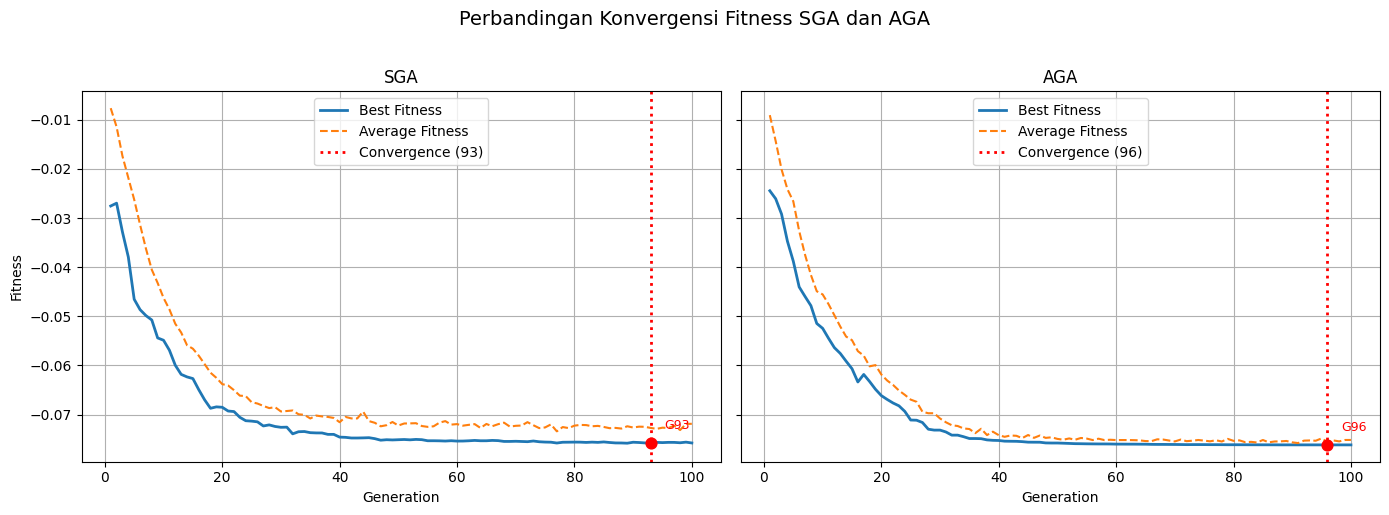

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# Perbandingan Konvergensi Fitness SGA dan AGA
# ============================================================

from google.colab import files

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5),
    sharey=True
)

# ============================================================
# SGA
# ============================================================

best_sga = result_ga["history_best"]
avg_sga = result_ga["history_avg"]

gen_sga = np.arange(1, len(best_sga) + 1)

conv_sga = result_ga["convergence_generation"] + 1

axes[0].plot(
    gen_sga,
    best_sga,
    linewidth=2,
    label="Best Fitness"
)

axes[0].plot(
    gen_sga,
    avg_sga,
    linestyle="--",
    label="Average Fitness"
)

# Titik konvergensi
axes[0].axvline(
    conv_sga,
    color="red",
    linestyle=":",
    linewidth=2,
    label=f"Convergence ({conv_sga})"
)

axes[0].scatter(
    conv_sga,
    best_sga[conv_sga - 1],
    color="red",
    s=60,
    zorder=5
)

axes[0].annotate(
    f"G{conv_sga}",
    xy=(conv_sga, best_sga[conv_sga - 1]),
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=9,
    color="red"
)

axes[0].set_title("SGA")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Fitness")
axes[0].grid(True)
axes[0].legend()

# ============================================================
# AGA
# ============================================================

best_aga = result_aga["history_best"]
avg_aga = result_aga["history_avg"]

gen_aga = np.arange(1, len(best_aga) + 1)

conv_aga = result_aga["convergence_generation"] + 1

axes[1].plot(
    gen_aga,
    best_aga,
    linewidth=2,
    label="Best Fitness"
)

axes[1].plot(
    gen_aga,
    avg_aga,
    linestyle="--",
    label="Average Fitness"
)

# Titik konvergensi
axes[1].axvline(
    conv_aga,
    color="red",
    linestyle=":",
    linewidth=2,
    label=f"Convergence ({conv_aga})"
)

axes[1].scatter(
    conv_aga,
    best_aga[conv_aga - 1],
    color="red",
    s=60,
    zorder=5
)

axes[1].annotate(
    f"G{conv_aga}",
    xy=(conv_aga, best_aga[conv_aga - 1]),
    xytext=(10, 10),
    textcoords="offset points",
    fontsize=9,
    color="red"
)

axes[1].set_title("AGA")
axes[1].set_xlabel("Generation")
axes[1].grid(True)
axes[1].legend()

fig.suptitle(
    "Perbandingan Konvergensi Fitness SGA dan AGA",
    fontsize=14,
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "comparison_fitness_convergence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

files.download(
    "comparison_fitness_convergence.png"
)

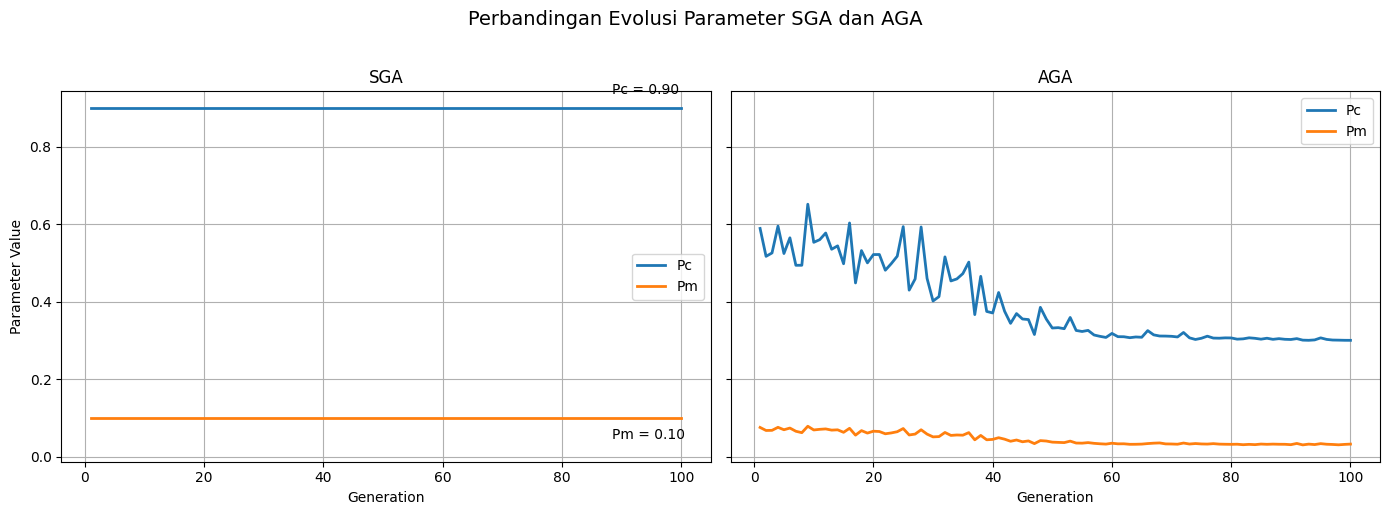

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# Perbandingan Evolusi Parameter SGA dan AGA
# ============================================================

from google.colab import files

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5),
    sharey=True
)

# ============================================================
# SGA
# ============================================================

pc_sga = np.array(result_ga["history_pc"])
pm_sga = np.array(result_ga["history_pm"])

gen_sga = np.arange(1, len(pc_sga) + 1)

axes[0].plot(
    gen_sga,
    pc_sga,
    label="Pc",
    linewidth=2
)

axes[0].plot(
    gen_sga,
    pm_sga,
    label="Pm",
    linewidth=2
)

# Anotasi nilai tetap
axes[0].annotate(
    f"Pc = {pc_sga[0]:.2f}",
    xy=(gen_sga[-1], pc_sga[-1]),
    xytext=(-50, 10),
    textcoords="offset points"
)

axes[0].annotate(
    f"Pm = {pm_sga[0]:.2f}",
    xy=(gen_sga[-1], pm_sga[-1]),
    xytext=(-50, -15),
    textcoords="offset points"
)

axes[0].set_title("SGA")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Parameter Value")
axes[0].grid(True)
axes[0].legend()

# ============================================================
# AGA
# ============================================================

pc_aga = np.array(result_aga["history_pc"])
pm_aga = np.array(result_aga["history_pm"])

gen_aga = np.arange(1, len(pc_aga) + 1)

axes[1].plot(
    gen_aga,
    pc_aga,
    label="Pc",
    linewidth=2
)

axes[1].plot(
    gen_aga,
    pm_aga,
    label="Pm",
    linewidth=2
)

# ============================================================
# Titik stabilisasi parameter AGA
# ============================================================

threshold = 1e-4

delta_pc = np.abs(np.diff(pc_aga))
delta_pm = np.abs(np.diff(pm_aga))

last_pc_change = np.where(delta_pc > threshold)[0]
last_pm_change = np.where(delta_pm > threshold)[0]


axes[1].set_title("AGA")
axes[1].set_xlabel("Generation")
axes[1].grid(True)
axes[1].legend()

fig.suptitle(
    "Perbandingan Evolusi Parameter SGA dan AGA",
    fontsize=14,
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "comparison_parameter_evolution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

files.download(
    "comparison_parameter_evolution.png"
)

#Evaluasi Performa SGA-AGA terhadap Equal Weight

In [ ]:
def run_comparison(mu, cov_matrix, n_runs=10):

    results = []

    # ============================================================
    # Evaluasi GA dan AGA
    # ============================================================
    for algo_name, algo_func in [
        ("GA", genetic_algorithm),
        ("AGA", adaptive_genetic_algorithm)
    ]:

        fitness_list = []
        return_list = []
        risk_list = []
        sharpe_list = []
        time_list = []
        convergence_list = []

        for run in range(n_runs):

            # Populasi awal yang sama
            init_pop = initialize_population(
                100,
                len(mu),
                max_weight
            )

            result = algo_func(
                mu,
                cov_matrix,
                pop_size=100,
                generations=100,
                seed=run,
                init_pop=init_pop
            )

            fitness_list.append(result["best_fitness"])
            return_list.append(result["best_return"])
            risk_list.append(result["best_risk"])
            sharpe_list.append(result["best_sharpe"])
            time_list.append(result["runtime"])
            convergence_list.append(
                result["convergence_generation"]
            )

        results.append({
            "Algorithm": algo_name,
            "Mean Fitness": np.mean(fitness_list),
            "Std Fitness": np.std(fitness_list),
            "Mean Return": np.mean(return_list),
            "Mean Risk": np.mean(risk_list),
            "Mean Sharpe": np.mean(sharpe_list),
            "Mean Time (s)": np.mean(time_list),
            "Std Time (s)": np.std(time_list),
            "Convergence Gen": np.nanmean(convergence_list)
        })


    return pd.DataFrame(results)

In [ ]:
# Execution
comparison_table = run_comparison(
    mu_train,
    cov_train,
    n_runs=10
)

In [ ]:
# ============================================================
# Simpan hasil perbandingan algoritma
# ============================================================

# Salin agar tidak mengubah data asli
comparison_result = comparison_table.copy()

# Ubah nama algoritma agar konsisten dengan skripsi
comparison_result["Algorithm"] = (
    comparison_result["Algorithm"]
    .replace({
        "GA": "SGA",
        "AGA": "AGA",
        "Equal Weight": "Equal Weight"
    })
)

# Bulatkan seluruh kolom numerik menjadi 5 desimal
numeric_cols = comparison_result.select_dtypes(
    include=["number"]
).columns

comparison_result[numeric_cols] = (
    comparison_result[numeric_cols]
    .round(5)
)

display(comparison_result)

# ============================================================
# Simpan ke CSV
# ============================================================

comparison_result.to_csv(
    "comparison_algorithm_verification.csv",
    index=False,
    float_format="%.5f"
)

files.download(
    "comparison_algorithm_verification.csv"
)

,Algorithm,Mean Fitness,Std Fitness,Mean Return,Mean Risk,Mean Sharpe,Mean Time (s),Std Time (s),Convergence Gen
0,SGA,-0.07590,0.00007,0.00091,0.01024,0.08905,4.15089,1.24114,92.4
1,AGA,-0.07618,0.00000,0.00091,0.01021,0.08945,3.44022,0.35679,97.5


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# VISUALISASI FINAL GA VS AGA
# ============================================================

def run_full_single_comparison(
    mu_data,
    cov_data,
    asset_names,
    title="Portfolio"
):

    # ========================================================
    # 1. Sinkronisasi Nama Ticker
    # ========================================================

    if len(asset_names) != len(mu_data):
        asset_names = [
            f"Asset {i+1}"
            for i in range(len(mu_data))
        ]

    # ========================================================
    # 2. Inisialisasi Populasi Awal yang Sama
    # ========================================================

    n_assets = len(mu_data)

    init_pop = initialize_population(
        pop_size=100,
        n_assets=n_assets,
        max_weight=max_weight
    )

    # ========================================================
    # 3. Jalankan GA
    # ========================================================

    res_ga = genetic_algorithm(
        mu_data,
        cov_data,
        pop_size=100,
        generations=100,
        seed=29,
        init_pop=init_pop.copy()
    )

    # ========================================================
    # 4. Jalankan AGA
    # ========================================================

    res_aga = adaptive_genetic_algorithm(
        mu_data,
        cov_data,
        pop_size=100,
        generations=100,
        seed=29,
        init_pop=init_pop.copy()
    )

    # ========================================================
    # VISUALISASI 1
    # FITNESS CONVERGENCE
    # ========================================================

    gen = np.arange(
        1,
        len(res_ga["history_best"]) + 1
    )

    plt.figure(figsize=(10, 5))

    # ---------- AGA (BIRU) ----------
    plt.plot(
        gen,
        res_aga["history_best"],
        color="tab:blue",
        linewidth=2.5,
        label="AGA Best"
    )

    plt.plot(
        gen,
        res_aga["history_avg"],
        color="tab:blue",
        linestyle="--",
        linewidth=2,
        alpha=0.8,
        label="AGA Average"
    )

    # ---------- GA (HIJAU) ----------
    plt.plot(
        gen,
        res_ga["history_best"],
        color="tab:green",
        linewidth=2.5,
        label="GA Best"
    )

    plt.plot(
        gen,
        res_ga["history_avg"],
        color="tab:green",
        linestyle="--",
        linewidth=2,
        alpha=0.8,
        label="GA Average"
    )

    plt.xlabel("Generation")
    plt.ylabel("Fitness")
    plt.title(
        f"Fitness Convergence Comparison ({title})"
    )

    plt.legend()
    plt.grid(
        True,
        linestyle="--",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

    # ========================================================
    # VISUALISASI 2
    # PERBANDINGAN BOBOT SELURUH SAHAM
    # ========================================================

    weight_df = pd.DataFrame({
        "Ticker": asset_names,
        "GA_Weights": res_ga["best_weights"],
        "AGA_Weights": res_aga["best_weights"]
    })

    plt.figure(figsize=(18, 7))

    x = np.arange(len(asset_names))
    width = 0.4

    # ---------- GA ----------
    bars_ga = plt.bar(
        x - width/2,
        weight_df["GA_Weights"],
        width,
        color="tab:green",
        alpha=0.85,
        label="GA"
    )

    # ---------- AGA ----------
    bars_aga = plt.bar(
        x + width/2,
        weight_df["AGA_Weights"],
        width,
        color="tab:blue",
        alpha=0.85,
        label="AGA"
    )

    # ========================================================
    # LABEL NILAI BOBOT
    # ========================================================

    for bar in bars_ga:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.1%}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

    for bar in bars_aga:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width()/2,
            height,
            f"{height:.1%}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

    # ========================================================
    # FORMAT GRAFIK
    # ========================================================

    plt.xticks(
        x,
        asset_names,
        rotation=45,
        ha="right"
    )

    plt.xlabel("Ticker")
    plt.ylabel("Portfolio Weight")

    plt.title(
        f"Portfolio Weight Comparison ({title})"
    )

    plt.legend()

    plt.grid(
        axis="y",
        linestyle="--",
        alpha=0.3
    )

    plt.tight_layout()

    plt.show()

    # ========================================================
    # TABEL BOBOT LENGKAP
    # ========================================================

    print("\n=== Portfolio Weights (%) ===")

    weight_display = weight_df.copy()

    weight_display["GA (%)"] = (
        weight_display["GA_Weights"] * 100
    ).round(2)

    weight_display["AGA (%)"] = (
        weight_display["AGA_Weights"] * 100
    ).round(2)

    weight_display = weight_display[
        ["Ticker", "GA (%)", "AGA (%)"]
    ]

    display(weight_display)

    # ========================================================
    # TABEL RINGKASAN PERFORMA
    # ========================================================

    summary_df = pd.DataFrame({

        "Metric": [
            "Best Fitness",
            "Expected Return",
            "Risk (Std Dev)",
            "Sharpe Ratio",
            "Runtime (s)",
            "Convergence Generation"
        ],

        "GA": [
            res_ga["best_fitness"],
            res_ga["best_return"],
            res_ga["best_risk"],
            res_ga["best_sharpe"],
            res_ga["runtime"],
            res_ga["convergence_generation"]
        ],

        "AGA": [
            res_aga["best_fitness"],
            res_aga["best_return"],
            res_aga["best_risk"],
            res_aga["best_sharpe"],
            res_aga["runtime"],
            res_aga["convergence_generation"]
        ]
    })

    summary_df["GA"] = summary_df["GA"].round(4)
    summary_df["AGA"] = summary_df["AGA"].round(4)

    print("\n=== Performance Summary ===")

    return summary_df

RUNNING : IDX30 SELECTED STOCKS


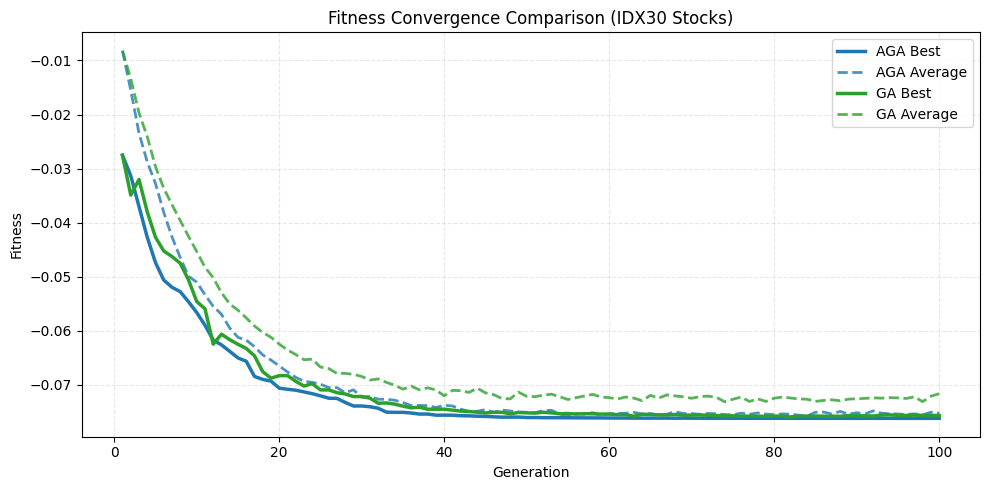

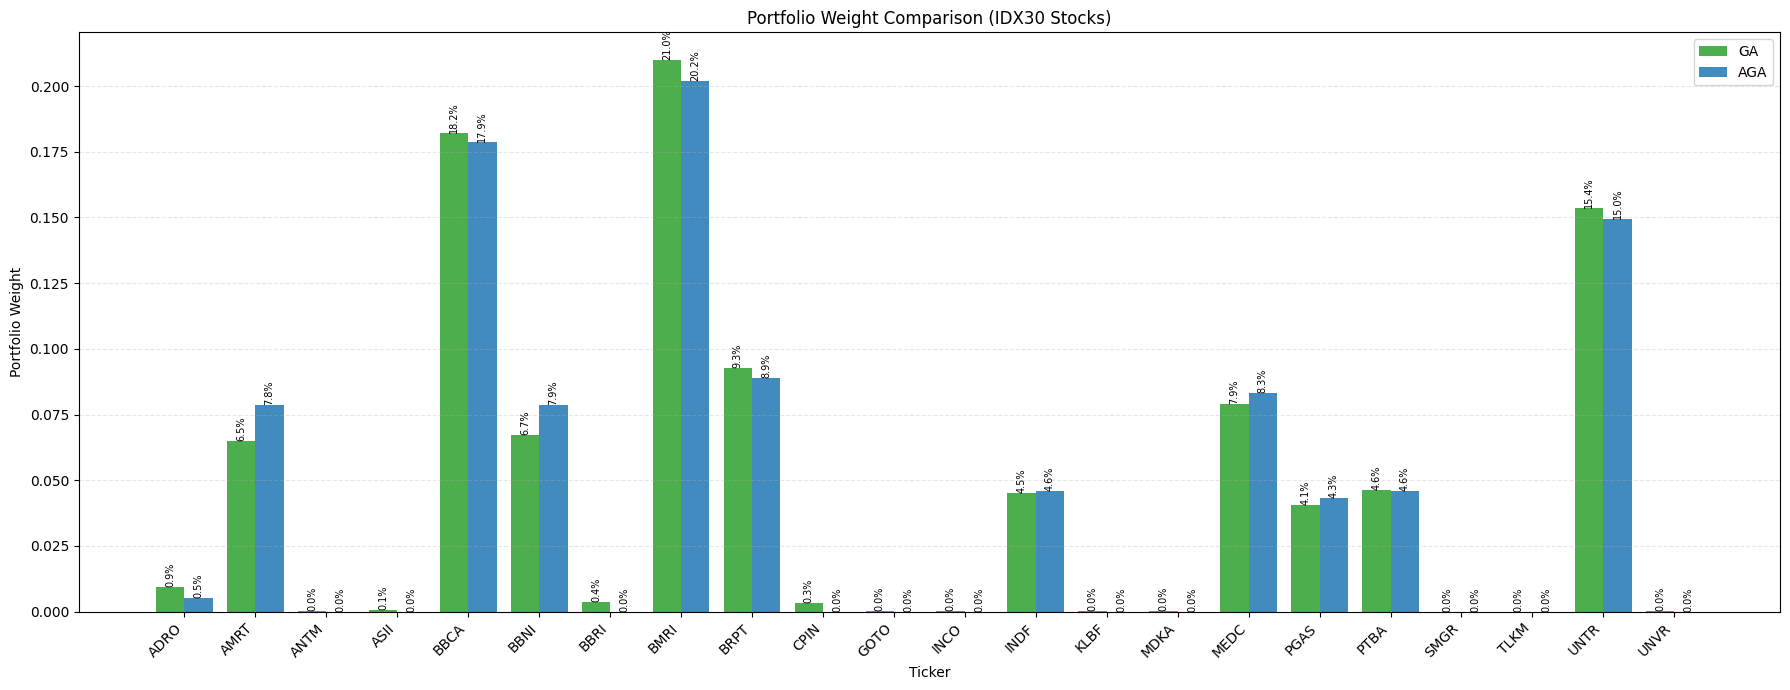


=== Portfolio Weights (%) ===


,Ticker,GA (%),AGA (%)
0,ADRO,0.95,0.51
1,AMRT,6.48,7.85
2,ANTM,0.03,0.00
3,ASII,0.06,0.00
4,BBCA,18.20,17.87
5,BBNI,6.73,7.87
6,BBRI,0.37,0.00
7,BMRI,21.00,20.19
8,BRPT,9.27,8.89
9,CPIN,0.32,0.00



=== Performance Summary ===


,Metric,GA,AGA
0,Best Fitness,-0.0759,-0.0762
1,Expected Return,0.0009,0.0009
2,Risk (Std Dev),0.0103,0.0102
3,Sharpe Ratio,0.0894,0.0894
4,Runtime (s),4.3954,3.6088
5,Convergence Generation,81.0000,98.0000


In [ ]:
print("=" * 50)
print("RUNNING : IDX30 SELECTED STOCKS")
print("=" * 50)

hasil = run_full_single_comparison(
    mu_train,
    cov_train,
    selected_tickers,
    title="IDX30 Stocks"
)

display(hasil)

#Tracking Algoritma SGA-AGA

## Tracking Algoritma SGA


> Tahap ini digunakan untuk menelusuri proses evolusi pada Standard Genetic Algorithm (GA), meliputi seleksi parent, crossover, mutasi, perbaikan bobot, serta pembentukan populasi baru. Tracking dilakukan pada skenario sederhana untuk mempermudah interpretasi mekanisme algoritma

In [ ]:
# ============================================================
# Tracking proses crossover pada Standard GA
# ============================================================

def track_crossover(
    p1,
    p2,
    pc=0.9,
    verbose=True
):
    """
    Menampilkan proses arithmetic crossover secara rinci,
    termasuk keputusan crossover dan offspring yang dihasilkan.
    """

    if verbose:
        print("\n--- Standard Crossover ---")
        print("Parent 1 =", p1)
        print("Parent 2 =", p2)
        print("Pc =", pc)

    r = np.random.rand()

    if verbose:
        print("Random r =", r)

    if r > pc:

        if verbose:
            print("r > Pc -> Tidak crossover")
            print("Return parent1")

        return p1.copy()

    alpha = np.random.rand()

    if verbose:
        print("r <= Pc -> Crossover terjadi")
        print("alpha =", alpha)

    child = alpha * p1 + (1 - alpha) * p2

    if verbose:
        print("child =", child)

    return child


# ============================================================
# Tracking proses mutasi pada Standard GA
# ============================================================

def track_mutation(
    individual,
    pm=0.1,
    scale=0.03,
    max_weight=0.3,
    verbose=True
):
    """
    Menampilkan proses Gaussian mutation pada setiap gen,
    termasuk keputusan mutasi dan perubahan bobot.
    """

    if verbose:
        print("\n--- Standard Mutation ---")
        print("Pm =", pm)

    child = individual.copy()

    for i in range(len(child)):

        r = np.random.rand()

        if verbose:
            print(f"Gene {i} random =", r)

        if r < pm:

            noise = np.random.normal(0, scale)

            child[i] += noise

            if verbose:
                print("Mutasi terjadi")
                print("noise =", noise)
                print("new gene =", child[i])

        else:

            if verbose:
                print("Tidak mutasi")

    return child


# ============================================================
# Tracking keseluruhan proses Standard GA
# ============================================================

def track_standard_ga(
    mu,
    cov_matrix,
    pop_size=4,
    generations=2,
    max_weight=0.3,
    seed=SEED,
    init_pop=None,
    verbose=True
):
    """
    Menjalankan Standard Genetic Algorithm pada populasi
    dan generasi kecil untuk memperlihatkan tahapan evolusi
    secara bertahap.
    """

    start_time = time.time()

    np.random.seed(seed)

    n_assets = len(mu)

    # Membentuk populasi awal
    if init_pop is not None:
        population = init_pop.copy()
    else:
        population = initialize_population(
            pop_size,
            n_assets,
            max_weight
        )

    global_best_fitness = np.inf
    global_best_weights = None

    pc = 0.9
    pm = 0.1

    for gen in range(generations):

        if verbose:
            print("\n==============================")
            print("GENERATION", gen + 1)
            print("==============================")

        # Menghitung fitness seluruh individu
        fitness = np.array([
            fitness_function(w, mu, cov_matrix)
            for w in population
        ])

        if verbose:
            print("\nFitness Population")

            for i, f in enumerate(fitness):
                print("Ind", i, "=", f)

        best_idx = np.argmin(fitness)

        # Memperbarui solusi terbaik
        if fitness[best_idx] < global_best_fitness:
            global_best_fitness = fitness[best_idx]
            global_best_weights = population[best_idx].copy()

        new_pop = []

        while len(new_pop) < pop_size:

            if verbose:
                print("\n--- Parent Selection ---")

            # Seleksi parent
            idx1 = tournament_selection(population, fitness)
            idx2 = tournament_selection(population, fitness)

            p1 = population[idx1]
            p2 = population[idx2]

            if verbose:
                print("Parent1 index =", idx1)
                print("Parent2 index =", idx2)

            # Crossover
            child = track_crossover(
                p1,
                p2,
                pc=pc,
                verbose=verbose
            )

            # Mutasi
            child = track_mutation(
                child,
                pm=pm,
                scale=0.03,
                max_weight=max_weight,
                verbose=verbose
            )

            # Perbaikan bobot agar memenuhi constraint
            child = repair_weights(
                child,
                max_weight
            )

            if verbose:
                print("\nChild setelah repair =", child)

            # Menambahkan offspring ke populasi baru
            new_pop.append(child)

        population = np.array(new_pop)

    # Menghitung performa solusi terbaik
    port_return = np.dot(
        global_best_weights,
        mu
    )

    port_risk = np.sqrt(
        global_best_weights
        @ cov_matrix
        @ global_best_weights
    )

    runtime = time.time() - start_time

    return {
        "best_weights": global_best_weights,
        "best_fitness": global_best_fitness,
        "best_return": port_return,
        "best_risk": port_risk,
        "runtime": runtime
    }

In [ ]:
standard_tracking = track_standard_ga(mu_train, cov_train)


GENERATION 1

Fitness Population
Ind 0 = -0.005868512809873718
Ind 1 = -0.0036255404455833315
Ind 2 = -0.010187104114546352
Ind 3 = -0.0026941698699415456

--- Parent Selection ---
Parent1 index = 2
Parent2 index = 2

--- Standard Crossover ---
Parent 1 = [0.01970874 0.05198311 0.05198311 0.05198311 0.0409921  0.05198311
 0.05198311 0.02824499 0.05129452 0.05198311 0.05198311 0.00656783
 0.05198311 0.05198311 0.05198311 0.05198311 0.02146201 0.05198311
 0.05198311 0.05198311 0.05198311 0.05198311]
Parent 2 = [0.01970874 0.05198311 0.05198311 0.05198311 0.0409921  0.05198311
 0.05198311 0.02824499 0.05129452 0.05198311 0.05198311 0.00656783
 0.05198311 0.05198311 0.05198311 0.05198311 0.02146201 0.05198311
 0.05198311 0.05198311 0.05198311 0.05198311]
Pc = 0.9
Random r = 0.6629346499564445
r <= Pc -> Crossover terjadi
alpha = 0.8445600198163764
child = [0.01970874 0.05198311 0.05198311 0.05198311 0.0409921  0.05198311
 0.05198311 0.02824499 0.05129452 0.05198311 0.05198311 0.00656783
 

## Tracking Algoritma AGA

> Tahap ini digunakan untuk menelusuri mekanisme Adaptive Genetic Algorithm (AGA) secara rinci. Tracking dilakukan untuk memperlihatkan proses penyesuaian probabilitas crossover dan mutasi berdasarkan distribusi fitness populasi, sehingga mekanisme adaptif yang diterapkan dapat diverifikasi sesuai rancangan algoritma.

In [ ]:
# ============================================================
# Tracking perhitungan probabilitas adaptif
# ============================================================

def track_adaptive_rates(
    fc,
    f_ind,
    f_min,
    f_max,
    f_avg,
    k1=0.9,
    k2=0.9,
    k3=0.3,
    k4=0.1,
    k5=0.1,
    k6=0.03,
    verbose=True
):
    """
    Menampilkan proses perhitungan probabilitas crossover
    dan mutasi adaptif sesuai implementasi AGA.
    """

    if verbose:
        print("\n--- Adaptive Rates ---")
        print("fc    =", fc)
        print("f_ind =", f_ind)
        print("f_min =", f_min)
        print("f_avg =", f_avg)
        print("f_max =", f_max)

    denom = f_avg - f_min

    if verbose:
        print("denominator =", denom)

    if denom <= 1e-4:

        if verbose:
            print("Populasi konvergen")
            print("Pc =", k1)
            print("Pm =", k4)

        return k1, k4

    # Adaptive crossover
    if fc <= f_avg:

        pc_adaptive = (
            k1 -
            ((k1 - k3) * (f_avg - fc) / denom)
        )

        pc = max(pc_adaptive, k3)

        if verbose:
            print("\nfc <= f_avg")
            print("Pc adaptive =", pc_adaptive)
            print("Pc final =", pc)

    else:

        pc = k2

        if verbose:
            print("\nfc > f_avg")
            print("Pc =", pc)

    # Adaptive mutation
    if f_ind <= f_avg:

        pm_adaptive = (
            k4 -
            ((k4 - k6) * (f_avg - f_ind) / denom)
        )

        pm = max(pm_adaptive, k6)

        if verbose:
            print("\nf_ind <= f_avg")
            print("Pm adaptive =", pm_adaptive)
            print("Pm final =", pm)

    else:

        pm = k5

        if verbose:
            print("\nf_ind > f_avg")
            print("Pm =", pm)

    return pc, pm

In [ ]:
# ============================================================
# Tracking keseluruhan proses Adaptive GA
# ============================================================

def track_adaptive_ga(
    mu,
    cov_matrix,
    pop_size=10,
    generations=2,
    max_weight=0.3,
    seed=SEED,
    init_pop=None,
    verbose=True
):
    """
    Menjalankan AGA pada skenario sederhana untuk
    memperlihatkan proses adaptasi probabilitas crossover
    dan mutasi pada setiap generasi.
    """

    start_time = time.time()

    np.random.seed(seed)

    n_assets = len(mu)

    if init_pop is not None:
        population = init_pop.copy()
    else:
        population = initialize_population(
            pop_size,
            n_assets,
            max_weight
        )

    global_best_fitness = np.inf
    global_best_weights = None

    for gen in range(generations):

        if verbose:
            print("\n==============================")
            print("GENERATION", gen + 1)
            print("==============================")

        # Menghitung fitness populasi
        fitness = np.array([
            fitness_function(w, mu, cov_matrix)
            for w in population
        ])

        f_max = np.max(fitness)
        f_min = np.min(fitness)
        f_avg = np.mean(fitness)

        if verbose:

            print("\nFitness Population")

            for i, f in enumerate(fitness):
                print("Ind", i, "=", f)

            print("\nf_min =", f_min)
            print("f_avg =", f_avg)
            print("f_max =", f_max)

        best_idx = np.argmin(fitness)

        if fitness[best_idx] < global_best_fitness:

            global_best_fitness = fitness[best_idx]
            global_best_weights = population[best_idx].copy()

        new_pop = []

        while len(new_pop) < pop_size:

            if verbose:
                print("\n--- Parent Selection ---")

            idx1 = tournament_selection(
                population,
                fitness
            )

            idx2 = tournament_selection(
                population,
                fitness
            )

            p1 = population[idx1]
            p2 = population[idx2]

            f1 = fitness[idx1]
            f2 = fitness[idx2]

            if verbose:
                print("Parent1 index =", idx1)
                print("Parent2 index =", idx2)

            # Parent terbaik dijadikan acuan
            if f2 < f1:

                p1, p2 = p2, p1
                f1, f2 = f2, f1

            fc = min(f1, f2)

            f_child_est = (f1 + f2) / 2

            if verbose:
                print("fc =", fc)
                print("Estimated child fitness =", f_child_est)

            # Hitung probabilitas adaptif
            pc_adapt, pm_adapt = track_adaptive_rates(
                fc,
                f_child_est,
                f_min,
                f_max,
                f_avg,
                verbose=verbose
            )

            # Adaptive crossover
            child = crossover(
                p1,
                p2,
                pc=pc_adapt
            )

            if verbose:
                print("\nChild setelah crossover")
                print(child)

            # Adaptive mutation
            child = mutation(
                child,
                pm=pm_adapt,
                scale=0.05,
                max_weight=max_weight
            )

            if verbose:
                print("\nChild setelah mutation")
                print(child)

            # Repair constraint
            child = repair_weights(
                child,
                max_weight
            )

            if verbose:
                print("\nChild setelah repair")
                print(child)

            new_pop.append(child)

        population = np.array(new_pop)

    port_return = np.dot(
        global_best_weights,
        mu
    )

    port_risk = np.sqrt(
        global_best_weights
        @ cov_matrix
        @ global_best_weights
    )

    runtime = time.time() - start_time

    return {
        "best_weights": global_best_weights,
        "best_fitness": global_best_fitness,
        "best_return": port_return,
        "best_risk": port_risk,
        "runtime": runtime
    }

In [ ]:
log_aga = track_adaptive_ga(mu_train, cov_train)


GENERATION 1

Fitness Population
Ind 0 = -0.005868512809873718
Ind 1 = -0.0036255404455833315
Ind 2 = -0.010187104114546352
Ind 3 = -0.0026941698699415456
Ind 4 = -0.005640221768397819
Ind 5 = -0.0016757339842267526
Ind 6 = -0.014958305550072326
Ind 7 = -0.005162129493408683
Ind 8 = 0.0006046605185671397
Ind 9 = -0.013348894607119095

f_min = -0.014958305550072326
f_avg = -0.006255595212460248
f_max = 0.0006046605185671397

--- Parent Selection ---
Parent1 index = 0
Parent2 index = 6
fc = -0.014958305550072326
Estimated child fitness = -0.010413409179973021

--- Adaptive Rates ---
fc    = -0.014958305550072326
f_ind = -0.010413409179973021
f_min = -0.014958305550072326
f_avg = -0.006255595212460248
f_max = 0.0006046605185671397
denominator = 0.008702710337612078

fc <= f_avg
Pc adaptive = 0.29999999999999993
Pc final = 0.3

f_ind <= f_avg
Pm adaptive = 0.0665567430794492
Pm final = 0.0665567430794492

Child setelah crossover
[0.05261123 0.0486736  0.01524451 0.04985796 0.05261123 0.05

#Hyperparameter Tuning

> Tahap ini menggunakan skema Walk-Forward Optimization (WFO) dua fase pada data validasi untuk mengevaluasi kombinasi hyperparameter. Setiap kandidat parameter diuji secara berurutan dengan mekanisme re-optimisasi, rebalancing, dan biaya transaksi sehingga diperoleh estimasi performa yang lebih realistis.



In [ ]:
# ============================================================
# Persiapan data validasi berbasis WFO dua fase
# ============================================================

# Fase 1 : Agustus–Oktober 2024
# Menggunakan data pelatihan awal (Jan 2023–Jul 2024)
mu_train_v1, cov_train_v1 = mu_train, cov_train

ret_val_p1 = returns_val[
    (returns_val.index >= "2024-08-01") &
    (returns_val.index <= "2024-10-31")
]

# Fase 2 : November 2024–Januari 2025
# Data pelatihan diperbarui hingga akhir Fase 1
df_train_v2 = df_selected[
    (df_selected["Date"] >= "2023-01-01") &
    (df_selected["Date"] <= "2024-10-31")
]

mu_train_v2, cov_train_v2, _ = compute_statistics(
    df_train_v2
)

ret_val_p2 = returns_val[
    (returns_val.index > "2024-10-31") &
    (returns_val.index <= "2025-01-27")
]

# Verifikasi pembagian data validasi
print("Data validasi berhasil dibagi menjadi 2 fase WFO.")
print(f"Fase 1 (Ags–Okt 2024) : {len(ret_val_p1)} hari perdagangan")
print(f"Fase 2 (Nov 2024–Jan 2025) : {len(ret_val_p2)} hari perdagangan")

Data validasi berhasil dibagi menjadi 2 fase WFO.
Fase 1 (Ags–Okt 2024) : 65 hari perdagangan
Fase 2 (Nov 2024–Jan 2025) : 56 hari perdagangan


In [ ]:
# ============================================================
# Evaluasi performa WFO dua fase
# ============================================================

def eval_wfo_2phase(
    w1,
    w2,
    ret_p1,
    ret_p2,
    fee_buy=0.0015,
    fee_sell=0.0025,
    risk_free_rate=0.06
):
    """
    Mengevaluasi performa portofolio menggunakan
    Walk-Forward Optimization (WFO) dua fase dengan
    mempertimbangkan rebalancing, biaya transaksi,
    dan risk-free rate tahunan.
    """

    # ========================================================
    # FASE 1
    # ========================================================

    # Modal awal setelah biaya pembelian
    capital = 1.0
    capital -= capital * fee_buy

    # Simulasi nilai portofolio pada fase pertama
    cr1 = (1 + ret_p1).cumprod()

    port_val_1 = cr1.dot(w1) * capital

    capital_end_p1 = port_val_1.iloc[-1]

    # Menghitung bobot aktual akibat pergerakan harga
    asset_values_end_p1 = w1 * cr1.iloc[-1]

    drifted_weights = (
        asset_values_end_p1 /
        asset_values_end_p1.sum()
    )

    # ========================================================
    # REBALANCING
    # ========================================================

    # Menghitung biaya transaksi rebalancing
    diff = w2 - drifted_weights

    cost = (
        capital_end_p1 *
        (
            np.sum(diff[diff > 0] * fee_buy) +
            np.sum(
                np.abs(diff[diff < 0]) * fee_sell
            )
        )
    )

    capital_start_p2 = capital_end_p1 - cost

    # ========================================================
    # FASE 2
    # ========================================================

    # Simulasi nilai portofolio setelah rebalancing
    cr2 = (1 + ret_p2).cumprod()

    port_val_2 = cr2.dot(w2) * capital_start_p2

    # Simulasi likuidasi seluruh aset pada akhir periode
    final_liquidation_cost = (
        port_val_2.iloc[-1] * fee_sell
    )

    port_val_2.iloc[-1] -= final_liquidation_cost

    # ========================================================
    # PERHITUNGAN METRIK KINERJA
    # ========================================================

    combined_port = pd.concat(
        [port_val_1, port_val_2]
    )

    daily_ret = (
        combined_port
        .pct_change()
        .dropna()
    )

    # Return kumulatif selama periode evaluasi
    total_return = combined_port.iloc[-1] - 1

    n_days = len(combined_port)

    # Annualized return ( Julah hari bursa 252 dalam setahun)
    ann_return = (
        (1 + total_return) ** (252 / n_days) - 1
        if n_days > 0 else 0
    )

    # Annualized volatility
    ann_vol = (
        daily_ret.std() * np.sqrt(252)
    )

    # Sharpe Ratio berbasis risk-free rate tahunan
    sharpe_ratio = (
        (ann_return - risk_free_rate) / ann_vol
        if ann_vol != 0 else 0
    )

    return (
        sharpe_ratio,
        ann_return,
        ann_vol,
        total_return
    )

# Tuning Parameter Fungsi Fitness

> Tahap ini bertujuan menentukan kombinasi parameter diversification penalty (`lambda_div`) dan batas maksimum bobot aset (`max_weight`) yang menghasilkan performa terbaik. Proses tuning dilakukan menggunakan Grid Search dan dievaluasi melalui skema Walk-Forward Optimization (WFO) dua fase.
"""


In [ ]:
# ============================================================
# Grid Search parameter fungsi fitness
# ============================================================

def tune_fitness_wfo(
    lambda_space,
    weight_space,
    pc=0.9,
    pm=0.1,
    seed=29
):
    """
    Melakukan Grid Search untuk menentukan kombinasi
    lambda_div dan max_weight terbaik berdasarkan
    Walk-Forward Sharpe Ratio.
    """

    print("=== Grid Search Fungsi Fitness ===")

    results = []

    # Menentukan konfigurasi eksperimen
    pop_size = len(mu_train) * 20
    gens = 100
    num_assets = len(mu_train)

    # Membentuk populasi awal yang konsisten
    np.random.seed(seed)

    baseline_max_weight = min(weight_space)

    fixed_init_pop = initialize_population(
        pop_size,
        num_assets,
        baseline_max_weight
    )

    # Membentuk seluruh kombinasi parameter
    combinations = list(
        itertools.product(
            lambda_space,
            weight_space
        )
    )

    global fitness_function
    original_fitness_function = fitness_function

    # Mengevaluasi setiap kombinasi parameter
    for idx, (l_div, mw) in enumerate(combinations):

        print(
            f"[{idx+1}/{len(combinations)}] "
            f"λ={l_div}, "
            f"max_weight={mw:.0%}",
            end=" ",
            flush=True
        )

        try:

            # Menyesuaikan parameter fungsi fitness
            def custom_fitness_wrapper(
                weights,
                mu,
                cov
            ):
                return original_fitness_function(
                    weights,
                    mu,
                    cov,
                    lambda_div=l_div,
                    max_weight=mw
                )

            fitness_function = custom_fitness_wrapper

            # ====================================================
            # Fase 1: Optimasi periode pertama
            # ====================================================

            res_1 = genetic_algorithm(
                mu_train_v1,
                cov_train_v1,
                pop_size=pop_size,
                generations=gens,
                pc=pc,
                pm=pm,
                max_weight=mw,
                seed=seed,
                init_pop=fixed_init_pop.copy()
            )

            w1 = res_1["best_weights"]

            # ====================================================
            # Fase 2: Optimasi periode kedua
            # ====================================================

            res_2 = genetic_algorithm(
                mu_train_v2,
                cov_train_v2,
                pop_size=pop_size,
                generations=gens,
                pc=pc,
                pm=pm,
                max_weight=mw,
                seed=seed,
                init_pop=fixed_init_pop.copy()
            )

            w2 = res_2["best_weights"]

        finally:

            # Mengembalikan fungsi fitness asli
            fitness_function = original_fitness_function

        # Menghitung Walk-Forward Sharpe Ratio
        wf_sr, _, _, _ = eval_wfo_2phase(
            w1,
            w2,
            ret_val_p1,
            ret_val_p2,
            fee_buy=0.0015,
            fee_sell=0.0025
        )

        # Menyimpan hasil evaluasi
        results.append({
            "lambda_div": l_div,
            "max_weight": mw,
            "WF Sharpe": wf_sr
        })

        print(f"→ Sharpe = {wf_sr:.4f}")

    # Mengurutkan berdasarkan Sharpe Ratio terbaik
    return (
        pd.DataFrame(results)
        .sort_values(
            by="WF Sharpe",
            ascending=False
        )
        .reset_index(drop=True)
    )

In [ ]:
# ============================================================
# Eksekusi Grid Search fungsi fitness
# ============================================================

# Ruang pencarian parameter
lambda_search_space = [
    0.0, 0.1, 0.2, 0.3, 0.4,
    0.5, 0.6, 0.7, 0.8, 0.9
]

max_weight_search_space = [
    0.1, 0.2, 0.3, 0.4, 0.5,
    0.6, 0.7, 0.8, 0.9, 1.0
]

# Menjalankan Grid Search
df_fitness_tuning_wfo = tune_fitness_wfo(
    lambda_space=lambda_search_space,
    weight_space=max_weight_search_space,
    pc=0.9,
    pm=0.1,
    seed=SEED
)

# ============================================================
# Menampilkan lima kombinasi terbaik
# ============================================================

display(
    df_fitness_tuning_wfo.head()
)

# ============================================================
# Menyimpan parameter terbaik
# ============================================================

BEST_LAMBDA = (
    df_fitness_tuning_wfo.loc[0, "lambda_div"]
)

BEST_MAX_WEIGHT = (
    df_fitness_tuning_wfo.loc[0, "max_weight"]
)

BEST_WF_SHARPE = (
    df_fitness_tuning_wfo.loc[0, "WF Sharpe"]
)

print("\nParameter terbaik:")
print(f"Lambda          : {BEST_LAMBDA}")
print(f"Max Weight      : {BEST_MAX_WEIGHT:.0%}")
print(f"WF Sharpe Ratio : {BEST_WF_SHARPE:.4f}")

=== Grid Search Fungsi Fitness ===
[1/100] λ=0.0, max_weight=10% → Sharpe = -0.7111
[2/100] λ=0.0, max_weight=20% → Sharpe = -0.9565
[3/100] λ=0.0, max_weight=30% → Sharpe = -0.9777
[4/100] λ=0.0, max_weight=40% → Sharpe = -0.9852
[5/100] λ=0.0, max_weight=50% → Sharpe = -0.9873
[6/100] λ=0.0, max_weight=60% → Sharpe = -0.9873
[7/100] λ=0.0, max_weight=70% → Sharpe = -0.9873
[8/100] λ=0.0, max_weight=80% → Sharpe = -0.9873
[9/100] λ=0.0, max_weight=90% → Sharpe = -0.9873
[10/100] λ=0.0, max_weight=100% → Sharpe = -0.9873
[11/100] λ=0.1, max_weight=10% → Sharpe = -0.7432
[12/100] λ=0.1, max_weight=20% → Sharpe = -0.8774
[13/100] λ=0.1, max_weight=30% → Sharpe = -0.8601
[14/100] λ=0.1, max_weight=40% → Sharpe = -0.8614
[15/100] λ=0.1, max_weight=50% → Sharpe = -0.8614
[16/100] λ=0.1, max_weight=60% → Sharpe = -0.8614
[17/100] λ=0.1, max_weight=70% → Sharpe = -0.8614
[18/100] λ=0.1, max_weight=80% → Sharpe = -0.8614
[19/100] λ=0.1, max_weight=90% → Sharpe = -0.8614
[20/100] λ=0.1, max_wei

,lambda_div,max_weight,WF Sharpe
0,0.9,0.1,-0.666810
1,0.7,0.2,-0.671626
2,0.7,0.8,-0.674123
3,0.7,0.3,-0.674123
4,0.7,0.6,-0.674123



Parameter terbaik:
Lambda          : 0.9
Max Weight      : 10%
WF Sharpe Ratio : -0.6668


In [ ]:
# ============================================================
# MENYIMPAN HASIL TUNING FITNESS
# ============================================================
"""
Menyimpan seluruh hasil ke file CSV
"""

df_fitness_tuning_wfo.to_csv(
    "fitness_tuning_results.csv",
    index=False
)

print("Hasil tuning Fitness berhasil disimpan.")
print("Nama file : fitness_tuning_results.csv")
print(f"Jumlah kombinasi : {len(df_fitness_tuning_wfo)}")

## Perbandingan Performa Sebelum dan Sesudah Tuning Parameter Fitness

In [ ]:
import numpy as np
import pandas as pd

# ============================================================
# Perbandingan sebelum vs sesudah tuning
# ============================================================

def compile_fitness_comparison(
    df_tuning,
    initial_params
):

    print("\n" + "=" * 70)
    print("EVALUASI DAMPAK TUNING PARAMETER FITNESS PADA AGA")
    print("=" * 70)

    best_row = df_tuning.iloc[0]

    initial_mask = (
        np.isclose(
            df_tuning["lambda_div"],
            initial_params["lambda"]
        )
    ) & (
        np.isclose(
            df_tuning["max_weight"],
            initial_params["weight"]
        )
    )

    initial_df = df_tuning[initial_mask]

    if initial_df.empty:
        raise ValueError(
            "Parameter awal tidak ditemukan."
        )

    initial_row = initial_df.iloc[0]

    summary = pd.DataFrame([
        {
            "Skenario": "AGA (Sesudah Tuning)",
            "WF Sharpe": best_row["WF Sharpe"]
        },
        {
            "Skenario": "AGA (Sebelum Tuning)",
            "WF Sharpe": initial_row["WF Sharpe"]
        }
    ])

    initial_sr = initial_row["WF Sharpe"]

    summary["Δ Sharpe"] = (
        summary["WF Sharpe"] - initial_sr
    )

    summary = summary.round(4)

    improvement = (
        best_row["WF Sharpe"] - initial_sr
    )

    print("\nInterpretasi Hasil:")

    print(
        f"- WF Sharpe sebelum tuning : {initial_sr:.4f}"
    )

    print(
        f"- WF Sharpe sesudah tuning : "
        f"{best_row['WF Sharpe']:.4f}"
    )

    print(
        f"- Perubahan WF Sharpe      : "
        f"{improvement:+.4f}"
    )

    print("\nTabel Ringkasan Evaluasi:")

    display(summary)

    return summary

In [ ]:
# ============================================================
# Evaluasi sebelum vs sesudah tuning parameter fitness
# ============================================================

initial_parameters = {
    "lambda": 0.1,
    "weight": 0.3
}

df_fitness_comparison = compile_fitness_comparison(
    df_tuning=df_fitness_tuning_wfo,
    initial_params=initial_parameters
)


EVALUASI DAMPAK TUNING PARAMETER FITNESS PADA AGA

Interpretasi Hasil:
- WF Sharpe sebelum tuning : -0.8601
- WF Sharpe sesudah tuning : -0.6668
- Perubahan WF Sharpe      : +0.1933

Tabel Ringkasan Evaluasi:


,Skenario,WF Sharpe,Δ Sharpe
0,AGA (Sesudah Tuning),-0.6668,0.1933
1,AGA (Sebelum Tuning),-0.8601,0.0000


In [ ]:
# ============================================================
# Menyimpan hasil evaluasi
# ============================================================

df_fitness_comparison.to_csv(
    "comparison_fitness_parameter.csv",
    index=False
)

# Update Parameter

In [ ]:
# ============================================================
# Inisialisasi parameter fungsi fitness
# ============================================================

# Setelah proses hyperparameter tuning
max_weight = 0.1
lambda_div_default = 0.9

In [ ]:
# ============================================================
# Fungsi fitness optimasi portofolio
# ============================================================

def fitness_function(
    weights,
    mu,
    cov_matrix,
    lambda_div=lambda_div_default,
    max_weight=max_weight
):
    """
    Menghitung nilai fitness berbasis minimisasi dengan
    mengintegrasikan Sharpe Ratio, diversification penalty,
    dan maximum weight penalty.
    """

    # Mengubah bobot menjadi numpy array
    weights = np.array(weights)

    # Menghitung expected return portofolio
    E = weights @ mu

    # Menghitung risiko portofolio (standar deviasi)
    V = weights.T @ cov_matrix @ weights
    sigma = np.sqrt(V + 1e-6)

    # Menghitung Sharpe Ratio
    sharpe = E / sigma

    # Menghitung diversification penalty
    diversification = np.sum(weights**2)

    # Menghitung penalti pelanggaran batas bobot
    penalty_max = 0

    if max_weight is not None:
        violations = np.maximum(
            0,
            weights - max_weight
        )

        penalty_max = (
            1000 * np.sum(violations**2)
        )

    # Menghitung nilai fitness akhir
    fitness = (
        -sharpe
        + (lambda_div * diversification)
        + penalty_max
    )

    return fitness

In [ ]:
# ============================================================
# KONFIGURASI TUNING ALGORITMA
# ============================================================
"""
Menetapkan konfigurasi dasar yang digunakan selama proses
tuning parameter algoritma, perbandingan akhir, dan retraining.

Jumlah evaluasi fungsi (NFE) dibuat konstan agar seluruh
kombinasi parameter dibandingkan secara adil meskipun
menggunakan ukuran populasi yang berbeda.
"""

pop_space = [
    440,
    500
]

# Maximum Number of Function Evaluations (NFE)
max_nfe_budget = (
    440 * 100
)

# Tune Algoritma

## tune ga

In [ ]:
# ============================================================
# TUNING GENETIC ALGORITHM (GA)
# WALK-FORWARD OPTIMIZATION (2 PHASES)
# ============================================================

import itertools
import time
import numpy as np
import pandas as pd


def tune_ga_wfo(
    pop_sizes,
    pc_rates,
    pm_rates,
    max_weight,
    max_nfe=max_nfe_budget,
    seed=29
):
    """
    Melakukan tuning parameter Genetic Algorithm menggunakan
    evaluasi Walk-Forward Optimization (WFO) 2 fase.

    Parameter yang dituning:
    - Population Size
    - Crossover Probability (Pc)
    - Mutation Probability (Pm)

    Kriteria seleksi:
    - Sharpe Ratio kumulatif WFO tertinggi.
    """

    print("=== TAHAP 2A: Tuning GA Standar dengan WFO (2 Fase) ===")

    results = []
    num_assets = len(mu_train_v1)

    # ========================================================
    # GENERATE FIXED INITIAL POPULATION
    # ========================================================
    # Dibuat terpisah untuk setiap fase training
    # agar seluruh kombinasi parameter memperoleh
    # kondisi awal yang identik (fair comparison).
    # ========================================================

    np.random.seed(seed)

    init_pops_v1 = {
        pop: initialize_population(
            pop,
            num_assets,
            max_weight
        )
        for pop in pop_sizes
    }

    init_pops_v2 = {
        pop: initialize_population(
            pop,
            num_assets,
            max_weight
        )
        for pop in pop_sizes
    }

    # ========================================================
    # GRID SEARCH COMBINATIONS
    # ========================================================

    combinations = list(
        itertools.product(
            pop_sizes,
            pc_rates,
            pm_rates
        )
    )

    total_runs = len(combinations)

    # ========================================================
    # MAIN GRID SEARCH LOOP
    # ========================================================

    for idx, (pop, pc, pm) in enumerate(combinations):

        dynamic_gens = max_nfe // pop

        print(
            f"[{idx + 1}/{total_runs}] "
            f"Pop: {pop}, "
            f"Gen: {dynamic_gens}, "
            f"Pc: {pc}, "
            f"Pm: {pm}...",
            end=" ",
            flush=True
        )

        start_time = time.time()

        # ====================================================
        # PHASE 1
        # Training hingga Juli 2024
        # ====================================================

        result_phase_1 = genetic_algorithm(
            mu_train_v1,
            cov_train_v1,
            pop_size=pop,
            generations=dynamic_gens,
            pc=pc,
            pm=pm,
            max_weight=max_weight,
            seed=seed,
            init_pop=init_pops_v1[pop].copy()
        )

        w1 = result_phase_1["best_weights"]

        # ====================================================
        # PHASE 2
        # Training hingga Oktober 2024
        # ====================================================

        result_phase_2 = genetic_algorithm(
            mu_train_v2,
            cov_train_v2,
            pop_size=pop,
            generations=dynamic_gens,
            pc=pc,
            pm=pm,
            max_weight=max_weight,
            seed=seed,
            init_pop=init_pops_v2[pop].copy()
        )

        w2 = result_phase_2["best_weights"]

        # ====================================================
        # WALK-FORWARD EVALUATION
        # ====================================================
        # Menghitung performa kumulatif dengan
        # mempertimbangkan biaya rebalancing.
        # ====================================================

        (
            wf_sr,
            wf_ar,
            wf_av,
            wf_tr
        ) = eval_wfo_2phase(
            w1,
            w2,
            ret_val_p1,
            ret_val_p2,
            fee_buy=0.0015,
            fee_sell=0.0025
        )

        runtime = round(
            time.time() - start_time,
            2
        )

        # ====================================================
        # SAVE RESULT
        # ====================================================

        results.append({
            "Pop Size": pop,
            "Generations": dynamic_gens,
            "Pc": pc,
            "Pm": pm,
            "WF Cum. Sharpe": wf_sr,
            "WF Ann. Return (%)": wf_ar * 100,
            "WF Ann. Risk (%)": wf_av * 100,
            "WF Total Ret (%)": wf_tr * 100,
            "Time (s)": runtime
        })

        print(
            f"Sharpe: {wf_sr:.4f} | "
            f"Waktu: {runtime:.1f}s"
        )

    # ========================================================
    # SORT RESULT
    # ========================================================
    # Mengurutkan berdasarkan Sharpe Ratio WFO tertinggi.
    # ========================================================

    return (
        pd.DataFrame(results)
        .sort_values(
            by="WF Cum. Sharpe",
            ascending=False
        )
        .reset_index(drop=True)
    )

In [ ]:
# ==========================================
# EKSEKUSI GA STANDAR (81 KOMBINASI)
# ==========================================

# Search space lengkap 0.1 - 0.9
pc_space = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
pm_space = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

df_tuning_ga = tune_ga_wfo(
    pop_sizes=pop_space,
    pc_rates=pc_space,
    pm_rates=pm_space,
    max_weight=max_weight,
    max_nfe=max_nfe_budget,
    seed=29
)
print("\n--- Top 5 Hasil GA Standar ---")
display(df_tuning_ga.head(5))

=== TAHAP 2A: Tuning GA Standar dengan WFO (2 Fase) ===
[1/162] Pop: 440, Gen: 100, Pc: 0.1, Pm: 0.1... Sharpe: -0.7486 | Waktu: 41.4s
[2/162] Pop: 440, Gen: 100, Pc: 0.1, Pm: 0.2... Sharpe: -0.6273 | Waktu: 33.2s
[3/162] Pop: 440, Gen: 100, Pc: 0.1, Pm: 0.3... Sharpe: -0.6457 | Waktu: 35.0s
[4/162] Pop: 440, Gen: 100, Pc: 0.1, Pm: 0.4... Sharpe: -0.8192 | Waktu: 33.7s
[5/162] Pop: 440, Gen: 100, Pc: 0.1, Pm: 0.5... Sharpe: -0.8898 | Waktu: 35.6s
[6/162] Pop: 440, Gen: 100, Pc: 0.1, Pm: 0.6... Sharpe: -0.5794 | Waktu: 36.7s
[7/162] Pop: 440, Gen: 100, Pc: 0.1, Pm: 0.7... Sharpe: -0.8105 | Waktu: 36.1s
[8/162] Pop: 440, Gen: 100, Pc: 0.1, Pm: 0.8... Sharpe: -0.6442 | Waktu: 35.2s
[9/162] Pop: 440, Gen: 100, Pc: 0.1, Pm: 0.9... Sharpe: -0.5448 | Waktu: 37.0s
[10/162] Pop: 440, Gen: 100, Pc: 0.2, Pm: 0.1... Sharpe: -0.6971 | Waktu: 33.0s
[11/162] Pop: 440, Gen: 100, Pc: 0.2, Pm: 0.2... Sharpe: -0.8389 | Waktu: 32.6s
[12/162] Pop: 440, Gen: 100, Pc: 0.2, Pm: 0.3... Sharpe: -0.7391 | Waktu:

,Pop Size,Generations,Pc,Pm,WF Cum. Sharpe,WF Ann. Return (%),WF Ann. Risk (%),WF Total Ret (%),Time (s)
0,440,100,0.5,0.9,-0.336157,0.272481,17.038201,0.130742,37.35
1,500,88,0.1,0.6,-0.444371,-1.874215,17.719926,-0.904347,35.54
2,440,100,0.2,0.4,-0.454333,-1.789344,17.144565,-0.863202,34.09
3,500,88,0.3,0.6,-0.483145,-2.366576,17.316921,-1.143407,36.43
4,500,88,0.6,0.9,-0.484624,-2.529059,17.599338,-1.222436,37.47


In [ ]:
#Save Tuning GA Standar WFO
df_tuning_ga.to_csv('tuning_wfo_ga_standar.csv', index=False)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##tune aga

In [ ]:
def tune_aga_wfo(pop_sizes, k_scenarios, max_weight, max_nfe=max_nfe_budget, seed=29):
    results = []
    num_assets = len(mu_train_v1)

    # ==========================================
    # 1. GENERATE FIXED INITIAL POPULATIONS
    # ==========================================
    np.random.seed(seed)
    init_pops_v1 = {pop: initialize_population(pop, num_assets, max_weight) for pop in pop_sizes}
    init_pops_v2 = {pop: initialize_population(pop, num_assets, max_weight) for pop in pop_sizes}

    combinations = list(itertools.product(pop_sizes, k_scenarios.items()))
    total_runs = len(combinations)

    for idx, (pop, (scenario_name, k_vals)) in enumerate(combinations):
        dynamic_gens = max_nfe // pop
        print(f"[{idx+1}/{total_runs}] Pop: {pop}, Gen: {dynamic_gens}, {scenario_name}...", end=" ", flush=True)
        start_time = time.time()

        # Fungsi adaptif dinamis berdasarkan iterasi k_vals
        def custom_adaptive(fc, f_ind, f_min, f_max, f_avg):
            return calculate_adaptive_rates(fc, f_ind, f_min, f_max, f_avg, **k_vals)

        # --- RUN 1: Cari w1 (Training sampai Jul 2024) ---
        res_1 = adaptive_genetic_algorithm(
            mu_train_v1, cov_train_v1, pop_size=pop, generations=dynamic_gens,
            max_weight=max_weight, adaptive_func=custom_adaptive, seed=seed, init_pop=init_pops_v1[pop].copy()
        )
        w1 = res_1['best_weights']

        # --- RUN 2: Cari w2 (Training sampai Okt 2024) ---
        res_2 = adaptive_genetic_algorithm(
            mu_train_v2, cov_train_v2, pop_size=pop, generations=dynamic_gens,
            max_weight=max_weight, adaptive_func=custom_adaptive, seed=seed, init_pop=init_pops_v2[pop].copy()
        )
        w2 = res_2['best_weights']

        # --- EVALUASI WFO ---
        wf_sr, wf_ar, wf_av, wf_tr = eval_wfo_2phase(w1, w2, ret_val_p1, ret_val_p2, fee_buy=0.0015, fee_sell=0.0025)

        end_time = time.time()

        results.append({
            'Pop Size': pop, 'Generations': dynamic_gens, 'Skenario K': scenario_name,
            **k_vals,
            'WF Cum. Sharpe': wf_sr,
            'WF Ann. Return (%)': wf_ar * 100,
            'WF Ann. Risk (%)': wf_av * 100,
            'WF Total Ret (%)': wf_tr * 100,
            'Time (s)': round(end_time - start_time, 2)
        })
        print(f"Sharpe: {wf_sr:.4f} | Waktu: {round(end_time - start_time, 1)}s")

    return pd.DataFrame(results).sort_values(by='WF Cum. Sharpe', ascending=False).reset_index(drop=True)

In [ ]:
# ==========================================
# EKSEKUSI ADAPTIVE GA
# ==========================================

# Ruang pencarian parameter adaptif sesuai referensi
k1_k2_vals = [0.1, 0.3, 0.5, 0.7, 0.9]
k3_vals = [0.1, 0.3]
k4_k5_vals = [0.1, 0.3, 0.5, 0.7, 0.9]
k6_vals = [0.1, 0.3]

kombinasi_k = list(itertools.product(k1_k2_vals, k3_vals, k4_k5_vals, k6_vals))
skenario_lengkap = {}

# Tambahkan counter untuk menamai skenario yang valid saja
counter_skenario = 1

for k1_k2, k3, k4_k5, k6 in kombinasi_k:
    # Kondisi: K3 tidak boleh lebih dari K1/K2 DAN K6 tidak boleh lebih dari K4/K5
    if (k3 < k1_k2) and (k6 < k4_k5):
        nama_skenario = f"Skenario {counter_skenario}"
        skenario_lengkap[nama_skenario] = {
            "k1": k1_k2, "k2": k1_k2,
            "k3": k3,
            "k4": k4_k5, "k5": k4_k5,
            "k6": k6
        }
        counter_skenario += 1

total_skenario_valid = len(skenario_lengkap)

df_tuning_aga = tune_aga_wfo(
    pop_sizes=pop_space,
    k_scenarios=skenario_lengkap,
    max_weight=max_weight,
    max_nfe=max_nfe_budget,
    seed=29
)
print("\n--- Top 5 Hasil Adaptive GA ---")
display(df_tuning_aga.head(5))

[1/98] Pop: 440, Gen: 100, Skenario 1... Sharpe: -0.6190 | Waktu: 31.4s
[2/98] Pop: 440, Gen: 100, Skenario 2... Sharpe: -0.6498 | Waktu: 30.8s
[3/98] Pop: 440, Gen: 100, Skenario 3... Sharpe: -0.7185 | Waktu: 32.0s
[4/98] Pop: 440, Gen: 100, Skenario 4... Sharpe: -0.7199 | Waktu: 31.8s
[5/98] Pop: 440, Gen: 100, Skenario 5... Sharpe: -0.8034 | Waktu: 32.6s
[6/98] Pop: 440, Gen: 100, Skenario 6... Sharpe: -0.7109 | Waktu: 31.9s
[7/98] Pop: 440, Gen: 100, Skenario 7... Sharpe: -0.8906 | Waktu: 33.2s
[8/98] Pop: 440, Gen: 100, Skenario 8... Sharpe: -0.7186 | Waktu: 30.0s
[9/98] Pop: 440, Gen: 100, Skenario 9... Sharpe: -0.7104 | Waktu: 31.0s
[10/98] Pop: 440, Gen: 100, Skenario 10... Sharpe: -0.7181 | Waktu: 31.7s
[11/98] Pop: 440, Gen: 100, Skenario 11... Sharpe: -0.8010 | Waktu: 31.3s
[12/98] Pop: 440, Gen: 100, Skenario 12... Sharpe: -0.7043 | Waktu: 32.6s
[13/98] Pop: 440, Gen: 100, Skenario 13... Sharpe: -0.7816 | Waktu: 32.2s
[14/98] Pop: 440, Gen: 100, Skenario 14... Sharpe: -0.76

,Pop Size,Generations,Skenario K,k1,k2,k3,k4,k5,k6,WF Cum. Sharpe,WF Ann. Return (%),WF Ann. Risk (%),WF Total Ret (%),Time (s)
0,500,88,Skenario 42,0.9,0.9,0.1,0.9,0.9,0.3,-0.544474,-3.508383,17.463441,-1.700222,33.41
1,500,88,Skenario 24,0.7,0.7,0.1,0.5,0.5,0.3,-0.555629,-3.390185,16.900112,-1.642423,31.40
2,500,88,Skenario 41,0.9,0.9,0.1,0.9,0.9,0.1,-0.583145,-4.118722,17.351985,-1.999266,31.84
3,500,88,Skenario 26,0.7,0.7,0.1,0.7,0.7,0.3,-0.584290,-4.131802,17.340375,-2.005685,32.24
4,500,88,Skenario 35,0.7,0.7,0.3,0.9,0.9,0.3,-0.585197,-4.217651,17.460189,-2.047830,32.48


In [ ]:
df_tuning_aga

,Pop Size,Generations,Skenario K,k1,k2,k3,k4,k5,k6,WF Cum. Sharpe,WF Ann. Return (%),WF Ann. Risk (%),WF Total Ret (%),Time (s)
0,500,88,Skenario 42,0.9,0.9,0.1,0.9,0.9,0.3,-0.544474,-3.508383,17.463441,-1.700222,33.41
1,500,88,Skenario 24,0.7,0.7,0.1,0.5,0.5,0.3,-0.555629,-3.390185,16.900112,-1.642423,31.40
2,500,88,Skenario 41,0.9,0.9,0.1,0.9,0.9,0.1,-0.583145,-4.118722,17.351985,-1.999266,31.84
3,500,88,Skenario 26,0.7,0.7,0.1,0.7,0.7,0.3,-0.584290,-4.131802,17.340375,-2.005685,32.24
4,500,88,Skenario 35,0.7,0.7,0.3,0.9,0.9,0.3,-0.585197,-4.217651,17.460189,-2.047830,32.48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,500,88,Skenario 19,0.5,0.5,0.3,0.7,0.7,0.3,-0.812787,-7.761988,16.931845,-3.805288,32.76
94,440,100,Skenario 26,0.7,0.7,0.1,0.7,0.7,0.3,-0.819118,-8.359623,17.530598,-4.105063,32.21
95,500,88,Skenario 28,0.7,0.7,0.1,0.9,0.9,0.3,-0.823942,-8.460832,17.550790,-4.155930,33.21
96,500,88,Skenario 17,0.5,0.5,0.3,0.5,0.5,0.3,-0.871238,-9.070338,17.297615,-4.462885,32.43


In [ ]:
# Taruh di bawah: df_tuning_aga = tune_aga_wfo(...)
df_tuning_aga.to_csv('tuning_wfo_aga.csv', index=False)

#Testing WFO

### Data Testing

In [ ]:
# ================================================================
# PERSIAPAN DATA RETRAINING (EXPANDING WINDOW)
# ================================================================

retraining_periods = [
    ("Fase 1", "2025-01-27"),
    ("Fase 2", "2025-04-30"),
    ("Fase 3", "2025-07-31"),
    ("Fase 4", "2025-10-31")
]

# ================================================================
# CONTAINER DATA
# ================================================================

train_data = {}
mu_data = {}
cov_data = {}
returns_data = {}

# ================================================================
# MEMBENTUK DATA TRAINING SETIAP FASE
# ================================================================

for phase_name, end_date in retraining_periods:

    print("\n" + "=" * 60)
    print(f"Menyiapkan {phase_name}")
    print(f"Periode : 2023-01-01 s.d. {end_date}")
    print("=" * 60)

    # ------------------------------------------------------------
    # EXPANDING WINDOW TRAINING
    # ------------------------------------------------------------

    df_train = df_selected[
        (df_selected["Date"] >= "2023-01-01") &
        (df_selected["Date"] <= end_date)
    ].copy()

    # ------------------------------------------------------------
    # HITUNG STATISTIK PORTOFOLIO
    # ------------------------------------------------------------

    mu, cov_matrix, returns_train = compute_statistics(
        df_train
    )

    # ------------------------------------------------------------
    # SIMPAN
    # ------------------------------------------------------------

    train_data[phase_name] = df_train
    mu_data[phase_name] = mu
    cov_data[phase_name] = cov_matrix
    returns_data[phase_name] = returns_train

    # ------------------------------------------------------------
    # INFORMASI DATA
    # ------------------------------------------------------------

    print(f"Jumlah observasi : {len(df_train)}")
    print(f"Jumlah saham     : {len(mu)}")


Menyiapkan Fase 1
Periode : 2023-01-01 s.d. 2025-01-27
Jumlah observasi : 10846
Jumlah saham     : 22

Menyiapkan Fase 2
Periode : 2023-01-01 s.d. 2025-04-30
Jumlah observasi : 12100
Jumlah saham     : 22

Menyiapkan Fase 3
Periode : 2023-01-01 s.d. 2025-07-31
Jumlah observasi : 13376
Jumlah saham     : 22

Menyiapkan Fase 4
Periode : 2023-01-01 s.d. 2025-10-31
Jumlah observasi : 14784
Jumlah saham     : 22


In [ ]:
# ================================================================
# EKSTRAK DATA SETIAP FASE
# ================================================================

mu_f1 = mu_data["Fase 1"]
mu_f2 = mu_data["Fase 2"]
mu_f3 = mu_data["Fase 3"]
mu_f4 = mu_data["Fase 4"]

cov_f1 = cov_data["Fase 1"]
cov_f2 = cov_data["Fase 2"]
cov_f3 = cov_data["Fase 3"]
cov_f4 = cov_data["Fase 4"]

In [ ]:
# ============================================================
# FINAL OPTIMIZATION - GENETIC ALGORITHM (GA)
# ============================================================

def get_final_ga_weights(
    mu,
    cov_matrix,
    n_runs=1,
    pop_size=440,
    generations=100
):
    """
    Menentukan bobot portofolio terbaik menggunakan GA.

    Returns
    -------
    pandas.Series
        Bobot portofolio dengan index ticker.
    """

    BEST_PC = 0.5
    BEST_PM = 0.9

    best_fitness = float("inf")
    best_weights = None

    for run in range(n_runs):

        current_seed = run + 100

        res = genetic_algorithm(
            mu=mu,
            cov_matrix=cov_matrix,
            pop_size=pop_size,
            generations=generations,
            pc=BEST_PC,
            pm=BEST_PM,
            seed=current_seed
        )

        if res["best_fitness"] < best_fitness:

            best_fitness = res["best_fitness"]
            best_weights = res["best_weights"]

    print(
        f"GA selesai | "
        f"Best Fitness = {best_fitness:.6f}"
    )

    # Simpan informasi ticker
    if hasattr(mu, "index"):
        best_weights = pd.Series(
            best_weights,
            index=mu.index,
            name="Weight"
        )

    # ============================================================
    # RETURN
    # ============================================================

    return {
        "weights": best_weights,
        "fitness": best_fitness
    }

In [ ]:
# ============================================================
# FINAL OPTIMIZATION - ADAPTIVE GENETIC ALGORITHM (AGA)
# ============================================================

def get_final_aga_weights(
    mu,
    cov_matrix,
    n_runs=1,
    pop_size=500,
    generations=88
):
    """
    Menentukan bobot portofolio terbaik menggunakan AGA.

    Returns
    -------
    pandas.Series
        Bobot portofolio dengan index ticker.
    """

    best_k_vals = {
        "k1": 0.9,
        "k2": 0.9,
        "k3": 0.1,
        "k4": 0.9,
        "k5": 0.9,
        "k6": 0.3
    }

    def final_adaptive_func(
        fc,
        f_ind,
        f_min,
        f_max,
        f_avg
    ):
        return calculate_adaptive_rates(
            fc,
            f_ind,
            f_min,
            f_max,
            f_avg,
            **best_k_vals
        )

    best_fitness = float("inf")
    best_weights = None

    for run in range(n_runs):

        current_seed = run + 100

        res = adaptive_genetic_algorithm(
            mu=mu,
            cov_matrix=cov_matrix,
            pop_size=pop_size,
            generations=generations,
            adaptive_func=final_adaptive_func,
            seed=current_seed
        )

        if res["best_fitness"] < best_fitness:

            best_fitness = res["best_fitness"]
            best_weights = res["best_weights"]

    print(
        f"AGA selesai | "
        f"Best Fitness = {best_fitness:.6f}"
    )

    # Simpan informasi ticker
    if hasattr(mu, "index"):
        best_weights = pd.Series(
            best_weights,
            index=mu.index,
            name="Weight"
        )

    # ============================================================
    # RETURN
    # ============================================================

    return {
        "weights": best_weights,
        "fitness": best_fitness
    }

## Generate Bobot GA & AGA (4 Fase)

In [ ]:
# ================================================================
# FINAL OPTIMIZATION GA
# ================================================================

ga_weights = {}
ga_fitness = {}

for phase_name, _ in retraining_periods:

    print("\n" + "=" * 60)
    print(f"GA - {phase_name}")
    print("=" * 60)

    mu = mu_data[phase_name]
    cov_matrix = cov_data[phase_name]

    ga_result = get_final_ga_weights(
        mu=mu,
        cov_matrix=cov_matrix,
        n_runs=1,
        pop_size=440,
        generations=100
    )

    # ============================================================
    # SIMPAN HASIL
    # ============================================================

    ga_weights[phase_name] = ga_result["weights"]

    ga_fitness[phase_name] = ga_result["fitness"]

    # ============================================================
    # TAMPILKAN HASIL
    # ============================================================

    print("\nBobot GA:")
    print(
        ga_result["weights"].round(4)
    )

    print("\nFitness:")
    print(
        round(
            ga_result["fitness"],
            6
        )
    )


GA - Fase 1
GA selesai | Best Fitness = 0.019808

Bobot GA:
ticker
ADRO    0.0439
AMRT    0.0635
ANTM    0.0317
ASII    0.0885
BBCA    0.0783
BBNI    0.0578
BBRI    0.0281
BMRI    0.0894
BRPT    0.0623
CPIN    0.0439
GOTO    0.0303
INCO    0.0419
INDF    0.0000
KLBF    0.0000
MDKA    0.0000
MEDC    0.0912
PGAS    0.0805
PTBA    0.0643
SMGR    0.0055
TLKM    0.0533
UNTR    0.0456
UNVR    0.0000
Name: Weight, dtype: float64

Fitness:
0.019808

GA - Fase 2
GA selesai | Best Fitness = 0.022079

Bobot GA:
ticker
ADRO    0.0788
AMRT    0.0222
ANTM    0.0648
ASII    0.0370
BBCA    0.0442
BBNI    0.0397
BBRI    0.0476
BMRI    0.0795
BRPT    0.0622
CPIN    0.0431
GOTO    0.0657
INCO    0.0312
INDF    0.0637
KLBF    0.0000
MDKA    0.0000
MEDC    0.0822
PGAS    0.0655
PTBA    0.0752
SMGR    0.0000
TLKM    0.0513
UNTR    0.0461
UNVR    0.0000
Name: Weight, dtype: float64

Fitness:
0.022079

GA - Fase 3
GA selesai | Best Fitness = 0.007896

Bobot GA:
ticker
ADRO    0.0876
AMRT    0.0656
ANTM    0.

In [ ]:
# ================================================================
# FINAL OPTIMIZATION AGA
# ================================================================

aga_weights = {}
aga_fitness = {}

for phase_name, _ in retraining_periods:

    print("\n" + "=" * 60)
    print(f"AGA - {phase_name}")
    print("=" * 60)

    mu = mu_data[phase_name]
    cov_matrix = cov_data[phase_name]

    aga_result = get_final_aga_weights(
        mu=mu,
        cov_matrix=cov_matrix,
        n_runs=1,
        pop_size=500,
        generations=88
    )

    aga_weights[phase_name] = aga_result["weights"]
    aga_fitness[phase_name] = aga_result["fitness"]

    # ============================================================
    # TAMPILKAN HASIL
    # ============================================================

    print("\nBobot aga:")
    print(
        aga_result["weights"].round(4)
    )

    print("\nFitness:")
    print(
        round(
            aga_result["fitness"],
            6
        )
    )


AGA - Fase 1
AGA selesai | Best Fitness = 0.012364

Bobot aga:
ticker
ADRO    0.0413
AMRT    0.0320
ANTM    0.0500
ASII    0.0480
BBCA    0.0295
BBNI    0.0804
BBRI    0.0571
BMRI    0.0714
BRPT    0.0780
CPIN    0.0406
GOTO    0.0399
INCO    0.0000
INDF    0.0677
KLBF    0.0490
MDKA    0.0084
MEDC    0.0684
PGAS    0.0524
PTBA    0.0776
SMGR    0.0000
TLKM    0.0339
UNTR    0.0659
UNVR    0.0086
Name: Weight, dtype: float64

Fitness:
0.012364

AGA - Fase 2
AGA selesai | Best Fitness = 0.021413

Bobot aga:
ticker
ADRO    0.0650
AMRT    0.0305
ANTM    0.0422
ASII    0.0636
BBCA    0.0378
BBNI    0.0548
BBRI    0.0433
BMRI    0.0655
BRPT    0.0771
CPIN    0.0376
GOTO    0.0592
INCO    0.0000
INDF    0.0686
KLBF    0.0480
MDKA    0.0265
MEDC    0.0861
PGAS    0.0764
PTBA    0.0506
SMGR    0.0000
TLKM    0.0000
UNTR    0.0671
UNVR    0.0000
Name: Weight, dtype: float64

Fitness:
0.021413

AGA - Fase 3
AGA selesai | Best Fitness = -0.000433

Bobot aga:
ticker
ADRO    0.0467
AMRT    0.0196


In [ ]:
# ============================================================
# SHARPE RATIO IN-SAMPLE
# ============================================================

def calculate_insample_sharpe(
    weights,
    mu,
    cov_matrix,
    risk_free_rate=0.06,
    trading_days=244
):

    portfolio_return = np.dot(
        weights,
        mu
    )

    portfolio_risk = np.sqrt(
        weights.T @ cov_matrix @ weights
    )

    annual_return = (
        portfolio_return
        * trading_days
    )

    annual_risk = (
        portfolio_risk
        * np.sqrt(trading_days)
    )

    if annual_risk == 0:
        return np.nan

    sharpe = (
        annual_return
        - risk_free_rate
    ) / annual_risk

    return sharpe

In [ ]:
# ============================================================
# HASIL RE-OPTIMIZATION WFO
# ============================================================

rows = []

for phase in retraining_periods:

    phase_name = phase[0]

    weights = aga_weights[phase_name]

    mu = mu_data[phase_name]
    cov = cov_data[phase_name]

    # Fitness aktual
    fitness = fitness_function(
        weights.values,
        mu.values,
        cov.values
    )

    # Sharpe In-Sample
    sharpe = calculate_insample_sharpe(
        weights.values,
        mu.values,
        cov.values
    )

    # Jumlah saham aktif
    active_assets = np.sum(
        weights.values > 0.0001
    )

    rows.append({

        "Fase":
            phase_name,

        "Fitness Terbaik":
            fitness,

        "Sharpe Ratio In-Sample":
            sharpe,

        "Jumlah Saham Aktif":
            active_assets

    })

df_reoptimization = pd.DataFrame(rows)

display(
    df_reoptimization.round(4)
)

,Fase,Fitness Terbaik,Sharpe Ratio In-Sample,Jumlah Saham Aktif
0,Fase 1,0.0124,0.2351,20
1,Fase 2,0.0214,0.1888,18
2,Fase 3,-0.0004,0.5961,19
3,Fase 4,-0.0063,0.6055,21


In [ ]:
df_reoptimization.round(4).to_csv(
    "tabel_reoptimization.csv",
    index=False
)

print("Tabel berhasil disimpan")

Tabel berhasil disimpan


In [ ]:
# ============================================================
# BOBOT PORTOFOLIO ANTAR FASE
# ============================================================

weights_phase_df_aga = pd.DataFrame({

    phase: aga_weights[phase]

    for phase in aga_weights.keys()

})

display(
    weights_phase_df_aga.round(4)
)

weights_phase_df_aga.to_csv(
    "bobot_portofolio_wfo.csv"
)

,Fase 1,Fase 2,Fase 3,Fase 4
ticker,,,,
ADRO,0.0413,0.0650,0.0467,0.0450
AMRT,0.0320,0.0305,0.0196,0.0310
ANTM,0.0500,0.0422,0.0937,0.0744
ASII,0.0480,0.0636,0.0806,0.0597
BBCA,0.0295,0.0378,0.0625,0.0848
BBNI,0.0804,0.0548,0.0785,0.0441
BBRI,0.0571,0.0433,0.0440,0.0270
BMRI,0.0714,0.0655,0.0624,0.0647
BRPT,0.0780,0.0771,0.1002,0.0830


In [ ]:
phase_colors = [
    "#08306B",  # Fase 1
    "#2171B5",  # Fase 2
    "#6BAED6",  # Fase 3
    "#C6DBEF"   # Fase 4
]

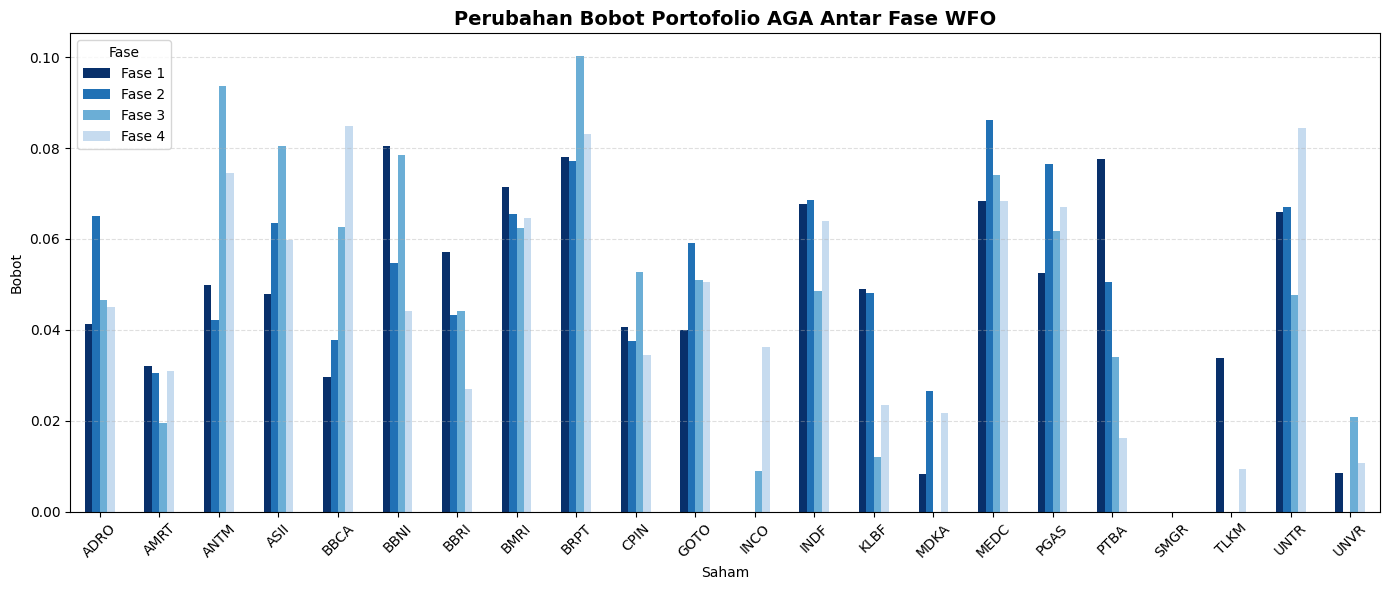

In [ ]:
# ============================================================
# GRAFIK REBALANCING ANTAR FASE
# ============================================================

import matplotlib.pyplot as plt

weights_phase_df_aga.plot(
    kind="bar",
    figsize=(14,6),
    color=phase_colors
)

plt.title(
    "Perubahan Bobot Portofolio AGA Antar Fase WFO",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Saham")
plt.ylabel("Bobot")

plt.legend(
    title="Fase"
)

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    "gambar_rebalancing_aga.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# BOBOT PORTOFOLIO ANTAR FASE
# ============================================================

weights_phase_df_ga = pd.DataFrame({

    phase: ga_weights[phase]

    for phase in ga_weights.keys()

})

display(
    weights_phase_df_ga.round(4)
)

weights_phase_df_ga.to_csv(
    "bobot_portofolio_wfo.csv"
)

,Fase 1,Fase 2,Fase 3,Fase 4
ticker,,,,
ADRO,0.0439,0.0788,0.0876,0.0753
AMRT,0.0635,0.0222,0.0656,0.0210
ANTM,0.0317,0.0648,0.0738,0.0651
ASII,0.0885,0.0370,0.0298,0.0366
BBCA,0.0783,0.0442,0.0000,0.0462
BBNI,0.0578,0.0397,0.0266,0.0398
BBRI,0.0281,0.0476,0.0000,0.0480
BMRI,0.0894,0.0795,0.0688,0.0721
BRPT,0.0623,0.0622,0.0862,0.0623


In [ ]:
phase_colors_ga = [
    "#00441B",  # Fase 1
    "#238B45",  # Fase 2
    "#66C2A4",  # Fase 3
    "#CCECE6"   # Fase 4
]

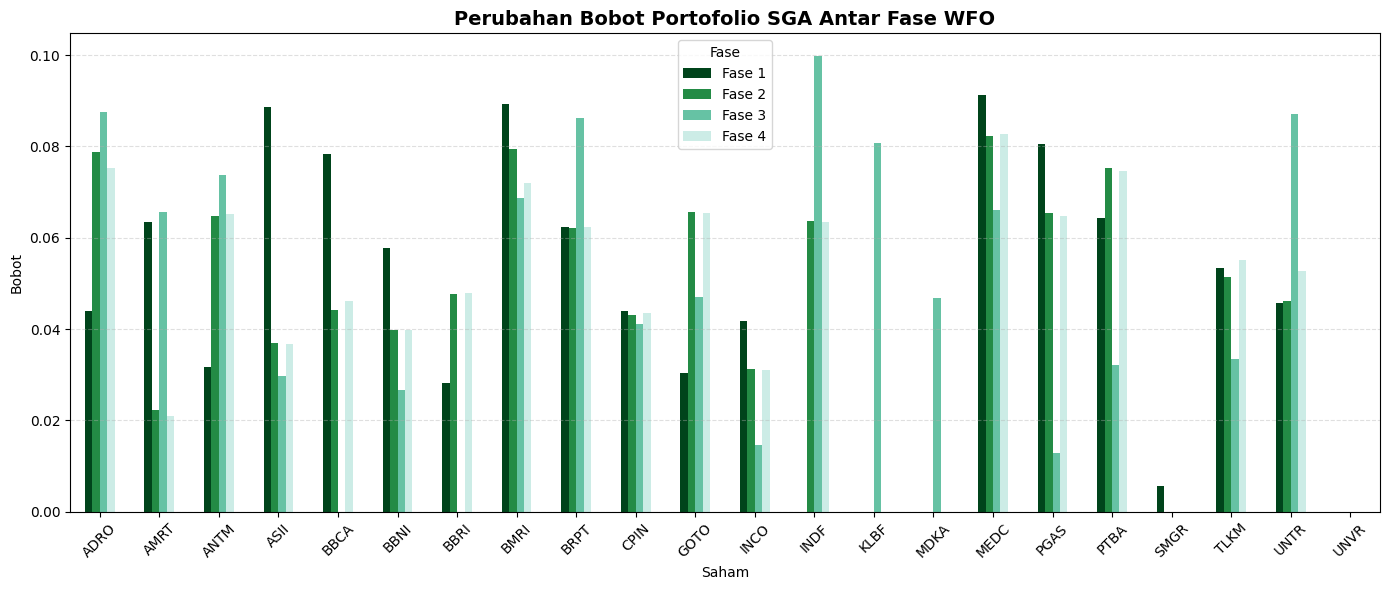

In [ ]:
# ============================================================
# GRAFIK REBALANCING ANTAR FASE
# ============================================================

import matplotlib.pyplot as plt

weights_phase_df_ga.plot(
    kind="bar",
    figsize=(14,6),
    color=phase_colors_ga
)

plt.title(
    "Perubahan Bobot Portofolio SGA Antar Fase WFO",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Saham")
plt.ylabel("Bobot")

plt.legend(
    title="Fase"
)

plt.xticks(rotation=45)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    "gambar_rebalancing_sga.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Data dan Function Evaluasi Performa Algoritma dan Portofoflio Out of Sample

In [ ]:
# ============================================================
# PREPARATION BENCHMARK IDX30
# ============================================================

df_idx = df_raw.copy()

df_idx["Date"] = pd.to_datetime(df_idx["Date"])

df_idx["Close"] = pd.to_numeric(
    df_idx["Close"],
    errors="coerce"
)

df_idx = (
    df_idx
    .dropna()
    .sort_values(["ticker", "Date"])
    .reset_index(drop=True)
)

df_idx["Rit"] = (
    df_idx
    .groupby("ticker")["Close"]
    .pct_change()
)

In [ ]:
# ============================================================
# FUNCTION: CREATE IDX30 BENCHMARK
# ============================================================

def create_idx_benchmark(
    df_idx,
    idx_map,
    start_date,
    end_date=None
):
    """
    Membentuk return benchmark dan bobot IDX30
    sesuai komposisi resmi pada setiap fase.
    """

    tickers = list(idx_map.keys())

    df_phase = df_idx[
        (df_idx["ticker"].isin(tickers)) &
        (df_idx["Date"] >= start_date)
    ]

    if end_date is not None:
        df_phase = df_phase[
            df_phase["Date"] < end_date
        ]

    _, _, returns_phase = compute_statistics(
        df_phase
    )

    weights_phase = np.array([
        idx_map[ticker]
        for ticker in returns_phase.columns
    ])

    return returns_phase, weights_phase

In [ ]:
# ============================================================
# FASE 1 : FEBRUARI - APRIL 2025
# ============================================================

idx30_map_p1 = {
    'ADRO': 0.0167, 'AKRA': 0.0060, 'AMRT': 0.0354, 'ANTM': 0.0091, 'ARTO': 0.0069,
    'ASII': 0.0646, 'BBCA': 0.1500, 'BBNI': 0.0493, 'BBRI': 0.1500, 'BMRI': 0.1500,
    'BRPT': 0.0173, 'CPIN': 0.0187, 'EXCL': 0.0071, 'GOTO': 0.0552, 'ICBP': 0.0173,
    'INCO': 0.0056, 'INDF': 0.0224, 'INKP': 0.0102, 'ISAT': 0.0086, 'KLBF': 0.0164,
    'MAPI': 0.0079, 'MBMA': 0.0098, 'MDKA': 0.0143, 'MEDC': 0.0053, 'PGAS': 0.0121,
    'PTBA': 0.0073, 'SMGR': 0.0070, 'TLKM': 0.0880, 'UNTR': 0.0246, 'UNVR': 0.0070
}

ret_idx_p1, w_idx_p1 = create_idx_benchmark(
    df_idx,
    idx30_map_p1,
    start_date="2025-01-27",
    end_date="2025-05-01"
)

In [ ]:
# ============================================================
# FASE 2 : MEI - JULI 2025
# ============================================================

idx30_map_p2 = {
    'ADRO': 0.0144, 'AKRA': 0.0059, 'AMRT': 0.0272, 'ANTM': 0.0148, 'ASII': 0.0699,
    'BBCA': 0.1500, 'BBNI': 0.0476, 'BBRI': 0.1500, 'BBTN': 0.0044, 'BMRI': 0.1382,
    'BRPT': 0.0159, 'CPIN': 0.0184, 'EXCL': 0.0103, 'GOTO': 0.0565, 'ICBP': 0.0193,
    'INCO': 0.0045, 'INDF': 0.0246, 'INKP': 0.0085, 'ISAT': 0.0074, 'KLBF': 0.0177,
    'MAPI': 0.0091, 'MBMA': 0.0084, 'MDKA': 0.0154, 'MEDC': 0.0054, 'PGAS': 0.0141,
    'PTBA': 0.0084, 'SMGR': 0.0068, 'TLKM': 0.0964, 'UNTR': 0.0244, 'UNVR': 0.0062
}

ret_idx_p2, w_idx_p2 = create_idx_benchmark(
    df_idx,
    idx30_map_p2,
    start_date="2025-05-01",
    end_date="2025-08-01"
)

In [ ]:
# ============================================================
# FASE 3 : AGUSTUS - OKTOBER 2025
# ============================================================

idx30_map_p3 = {
    'ADRO': 0.0130, 'AKRA': 0.0060, 'AMRT': 0.0291, 'ANTM': 0.0187, 'ASII': 0.0661,
    'BBCA': 0.1500, 'BBNI': 0.0439, 'BBRI': 0.1500, 'BMRI': 0.1231, 'BRPT': 0.0413,
    'CPIN': 0.0206, 'EXCL': 0.0091, 'GOTO': 0.0387, 'ICBP': 0.0174, 'INCO': 0.0058,
    'INDF': 0.0259, 'INKP': 0.0096, 'ISAT': 0.0089, 'ITMG': 0.0066, 'JPFA': 0.0059,
    'KLBF': 0.0197, 'MBMA': 0.0121, 'MDKA': 0.0204, 'MEDC': 0.0155, 'PGAS': 0.0123,
    'PTBA': 0.0068, 'SMGR': 0.0059, 'TLKM': 0.0978, 'UNTR': 0.0231, 'UNVR': 0.0064
}

ret_idx_p3, w_idx_p3 = create_idx_benchmark(
    df_idx,
    idx30_map_p3,
    start_date="2025-08-01",
    end_date="2025-11-01"
)

In [ ]:
# ============================================================
# FASE 4 : NOVEMBER 2025 - JANUARI 2026
# ============================================================

idx30_map_p4 = {
    'AADI': 0.0079, 'ADRO': 0.0103, 'AMRT': 0.0265, 'ANTM': 0.0182, 'ASII': 0.0784,
    'BBCA': 0.1500, 'BBNI': 0.0420, 'BBRI': 0.1500, 'BMRI': 0.1068, 'BRPT': 0.0649,
    'CPIN': 0.0199, 'GOTO': 0.0335, 'ICBP': 0.0136, 'INCO': 0.0062, 'INDF': 0.0213,
    'INKP': 0.0109, 'ISAT': 0.0071, 'ITMG': 0.0061, 'JPFA': 0.0086, 'KLBF': 0.0145,
    'MBMA': 0.0116, 'MDKA': 0.0176, 'MEDC': 0.0058, 'PGAS': 0.0126, 'PGEO': 0.0042,
    'PTBA': 0.0060, 'SMGR': 0.0059, 'TLKM': 0.1070, 'UNTR': 0.0244, 'UNVR': 0.0082
}

ret_idx_p4, w_idx_p4 = create_idx_benchmark(
    df_idx,
    idx30_map_p4,
    start_date="2025-11-01",
    end_date=None
)

In [ ]:
# ============================================================
# BACKTESTING DATA PREPARATION
# ============================================================
#
# Membagi data BACKTESTING menjadi 4 fase sesuai
# skenario Walk-Forward Optimization (WFO).
#
# Setiap fase menggunakan:
# - data return yang berbeda
# - bobot hasil retraining masing-masing fase
# - alignment ticker otomatis
#
# ============================================================

# ============================================================
# BACKTESTING RETURN PER PHASE
# ============================================================

ret_test_p1 = returns_test[
    (returns_test.index >= "2025-01-27") &
    (returns_test.index < "2025-05-01")
]

ret_test_p2 = returns_test[
    (returns_test.index >= "2025-05-01") &
    (returns_test.index < "2025-08-01")
]

ret_test_p3 = returns_test[
    (returns_test.index >= "2025-08-01") &
    (returns_test.index < "2025-11-01")
]

ret_test_p4 = returns_test[
    (returns_test.index >= "2025-11-01")
]

# ============================================================
# RETURN CONTAINER
# ============================================================

list_returns = [
    ret_test_p1,
    ret_test_p2,
    ret_test_p3,
    ret_test_p4
]

# ============================================================
# ALIGN PORTFOLIO WEIGHTS DENGAN RETURN TESTING
# ============================================================

w_ga_p1 = ga_weights["Fase 1"].reindex(
    ret_test_p1.columns
)

w_ga_p2 = ga_weights["Fase 2"].reindex(
    ret_test_p2.columns
)

w_ga_p3 = ga_weights["Fase 3"].reindex(
    ret_test_p3.columns
)

w_ga_p4 = ga_weights["Fase 4"].reindex(
    ret_test_p4.columns
)

w_aga_p1 = aga_weights["Fase 1"].reindex(
    ret_test_p1.columns
)

w_aga_p2 = aga_weights["Fase 2"].reindex(
    ret_test_p2.columns
)

w_aga_p3 = aga_weights["Fase 3"].reindex(
    ret_test_p3.columns
)

w_aga_p4 = aga_weights["Fase 4"].reindex(
    ret_test_p4.columns
)

# ============================================================
# VALIDASI SINKRONISASI TICKER
# ============================================================

for phase, weights in {
    "Fase 1": w_ga_p1,
    "Fase 2": w_ga_p2,
    "Fase 3": w_ga_p3,
    "Fase 4": w_ga_p4,
}.items():

    if weights.isnull().any():

        missing = weights[
            weights.isnull()
        ].index.tolist()

        raise ValueError(
            f"{phase} - Ticker GA tidak sinkron: {missing}"
        )

for phase, weights in {
    "Fase 1": w_aga_p1,
    "Fase 2": w_aga_p2,
    "Fase 3": w_aga_p3,
    "Fase 4": w_aga_p4,
}.items():

    if weights.isnull().any():

        missing = weights[
            weights.isnull()
        ].index.tolist()

        raise ValueError(
            f"{phase} - Ticker AGA tidak sinkron: {missing}"
        )

# ============================================================
# PORTFOLIO WEIGHTS PER PHASE
# ============================================================

weights_ga = [
    w_ga_p1.values,
    w_ga_p2.values,
    w_ga_p3.values,
    w_ga_p4.values
]

weights_aga = [
    w_aga_p1.values,
    w_aga_p2.values,
    w_aga_p3.values,
    w_aga_p4.values
]

# ============================================================
# EQUAL WEIGHT BASELINE
# ============================================================

weights_eq = []

for returns_phase in list_returns:

    w_equal = np.ones(
        len(returns_phase.columns)
    ) / len(returns_phase.columns)

    weights_eq.append(w_equal)

# ============================================================
# IDX30
# ============================================================

weights_idx = [
    w_idx_p1,
    w_idx_p2,
    w_idx_p3,
    w_idx_p4
]

list_returns_idx = [
    ret_idx_p1,
    ret_idx_p2,
    ret_idx_p3,
    ret_idx_p4
]

tickers_bnh = ret_idx_p1.columns

returns_idx_bnh = (
    df_idx[
        (df_idx["ticker"].isin(tickers_bnh)) &
        (df_idx["Date"] >= "2025-01-27")
    ]
)

_, _, returns_idx_bnh = compute_statistics(
    returns_idx_bnh
)

returns_idx_bnh = returns_idx_bnh[
    tickers_bnh
]

In [ ]:
# =================================================================
# BACKTESTING FUNCTION
# =================================================================
#
# Evaluasi performa portofolio berdasarkan:
# - Total Return
# - Annual Return
# - Annual Volatility
# - Sharpe Ratio
# - Maximum Drawdown
# - Total Transaction Cost
#
# Digunakan untuk:
# - Perbandingan AGA vs SGA
# - Perbandingan Equal Weight
# - Perbandingan IDX30
# - Evaluasi Walk-Forward Optimization
#
# =================================================================

def run_rebalancing(
    weights_list,
    returns_list,
    name,
    risk_free_rate=0.06,
    fee_buy=0.0015,
    fee_sell=0.0025
):

    # ============================================================
    # INITIALIZATION
    # ============================================================

    TRADING_DAYS = 252

    combined_portfolio_value = pd.Series(
        dtype="float64"
    )

    capital = 1.0

    end_weights = None

    total_fees_paid = 0.0

    # ============================================================
    # WALK-FORWARD LOOP
    # ============================================================

    for phase_index in range(len(returns_list)):

        phase_returns = returns_list[phase_index]

        current_weights = np.array(
            weights_list[phase_index]
        )

        # ========================================================
        # TRANSACTION COST
        # ========================================================

        if end_weights is not None:

            weight_diff = (
                current_weights
                - end_weights
            )

            rebalance_cost = capital * (
                np.sum(
                    weight_diff[
                        weight_diff > 0
                    ] * fee_buy
                )
                +
                np.sum(
                    np.abs(
                        weight_diff[
                            weight_diff < 0
                        ]
                    ) * fee_sell
                )
            )

        else:

            rebalance_cost = (
                capital * fee_buy
            )

        total_fees_paid += rebalance_cost

        capital -= rebalance_cost

        # ========================================================
        # PORTFOLIO VALUE
        # ========================================================

        cumulative_returns = (
            1 + phase_returns
        ).cumprod()

        start_date = (
            phase_returns.index[0]
            - pd.Timedelta(days=1)
        )

        initial_row = pd.DataFrame(
            np.ones(
                (
                    1,
                    len(phase_returns.columns)
                )
            ),
            index=[start_date],
            columns=phase_returns.columns
        )

        cumulative_returns = pd.concat([
            initial_row,
            cumulative_returns
        ])

        phase_portfolio_value = (
            cumulative_returns.dot(
                current_weights
            )
            * capital
        )

        # ========================================================
        # DRIFTED WEIGHTS
        # ========================================================

        asset_values_end = (
            current_weights
            * cumulative_returns.iloc[-1]
        )

        end_weights = (
            asset_values_end
            / asset_values_end.sum()
        )

        capital = (
            phase_portfolio_value.iloc[-1]
        )

        # ========================================================
        # COMBINE PHASES
        # ========================================================

        if phase_index == 0:

            combined_portfolio_value = (
                phase_portfolio_value
            )

        else:

            combined_portfolio_value = pd.concat([
                combined_portfolio_value,
                phase_portfolio_value.iloc[1:]
            ])

    # ============================================================
    # DAILY RETURNS
    # ============================================================

    daily_returns = (
        combined_portfolio_value
        .pct_change()
        .dropna()
    )

    n_days = len(daily_returns)

    # ============================================================
    # RETURN METRICS
    # ============================================================

    cumulative_return = (
        combined_portfolio_value.iloc[-1]
        - 1.0
    )

    if n_days > 0:

        annual_return = (
            (1 + cumulative_return)
            ** (TRADING_DAYS / n_days)
            - 1
        )

    else:

        annual_return = 0

    # ============================================================
    # RISK METRICS
    # ============================================================

    annual_volatility = (
        daily_returns.std()
        * np.sqrt(TRADING_DAYS)
    )

    running_max = (
        combined_portfolio_value
        .cummax()
    )

    drawdown = (
        combined_portfolio_value
        / running_max
        - 1
    )

    max_drawdown = (
        drawdown.min()
    )

    # ============================================================
    # SHARPE RATIO
    # ============================================================

    if annual_volatility > 0:

        sharpe_ratio = (
            annual_return
            - risk_free_rate
        ) / annual_volatility

    else:

        sharpe_ratio = 0

    # ============================================================
    # RETURN RESULT
    # ============================================================

    return {

        "Method":
            name,

        "Portfolio Value":
            combined_portfolio_value,

        "Daily Returns":
            daily_returns,

        "Total Return":
            cumulative_return,

        "Annual Return":
            annual_return,

        "Annual Volatility":
            annual_volatility,

        "Sharpe Ratio":
            sharpe_ratio,

        "Max Drawdown":
            max_drawdown,

        "Total Fees Paid":
            total_fees_paid,

        "Final Portfolio Value":
            combined_portfolio_value.iloc[-1]
    }

In [ ]:
# =================================================================
# BUY AND HOLD BACKTEST
# =================================================================
#
# Digunakan untuk:
# - Equal Weight Portfolio
# - Benchmark IDX30
#
# Evaluasi:
# - Total Return
# - Annual Return
# - Annual Volatility
# - Sharpe Ratio
# - Maximum Drawdown
# - Transaction Cost
#
# =================================================================

def run_isolated(
    weight_initial,
    returns_full,
    name,
    risk_free_rate=0.06,
    fee_buy=0.0015,
    trading_days=252
):
    """
    Backtesting Buy and Hold.

    Parameters
    ----------
    weight_initial : array-like
        Bobot awal portofolio.

    returns_full : DataFrame
        Return harian seluruh periode pengujian.

    name : str
        Nama strategi.
    """

    # ============================================================
    # INITIALIZATION
    # ============================================================

    weights = np.asarray(
        weight_initial,
        dtype=float
    )

    capital = 1.0

    total_fees_paid = 0.0

    # ============================================================
    # INITIAL BUY COST
    # ============================================================

    buy_cost = capital * fee_buy

    total_fees_paid += buy_cost

    capital -= buy_cost

    # ============================================================
    # PORTFOLIO VALUE
    # ============================================================

    cumulative_returns = (
        1 + returns_full
    ).cumprod()

    start_date = (
        returns_full.index[0]
        - pd.Timedelta(days=1)
    )

    initial_row = pd.DataFrame(
        np.ones(
            (1, len(returns_full.columns))
        ),
        index=[start_date],
        columns=returns_full.columns
    )

    cumulative_returns = pd.concat([
        initial_row,
        cumulative_returns
    ])

    portfolio_value = (
        cumulative_returns.dot(weights)
        * capital
    )

    # ============================================================
    # DAILY RETURNS
    # ============================================================

    daily_returns = (
        portfolio_value
        .pct_change()
        .dropna()
    )

    n_days = len(daily_returns)

    # ============================================================
    # RETURN METRICS
    # ============================================================

    total_return = (
        portfolio_value.iloc[-1]
        - 1
    )

    if n_days > 0:

        annual_return = (
            (1 + total_return)
            ** (trading_days / n_days)
            - 1
        )

    else:

        annual_return = 0

    # ============================================================
    # RISK METRICS
    # ============================================================

    annual_volatility = (
        daily_returns.std()
        * np.sqrt(trading_days)
    )

    running_max = (
        portfolio_value
        .cummax()
    )

    drawdown = (
        portfolio_value
        / running_max
        - 1
    )

    max_drawdown = (
        drawdown.min()
    )

    # ============================================================
    # SHARPE RATIO
    # ============================================================

    if annual_volatility > 0:

        sharpe_ratio = (
            annual_return
            - risk_free_rate
        ) / annual_volatility

    else:

        sharpe_ratio = 0

    # ============================================================
    # RETURN RESULT
    # ============================================================

    return {

        "Method":
            name,

        "Portfolio Value":
            portfolio_value,

        "Daily Returns":
            daily_returns,

        "Total Return":
            total_return,

        "Annual Return":
            annual_return,

        "Annual Volatility":
            annual_volatility,

        "Sharpe Ratio":
            sharpe_ratio,

        "Max Drawdown":
            max_drawdown,

        "Total Fees Paid":
            total_fees_paid,

        "Final Portfolio Value":
            portfolio_value.iloc[-1]
    }

## Evaluasi Performa Algoritma WFO Out of Sample

###Setting

In [ ]:
# ============================================================
# EVALUASI PERFORMA ALGORITMA OPTIMASI
# BAGIAN 1 : 10 RUNS × 4 FASE RETRAINING
# ============================================================
#
# Tujuan:
# Mengevaluasi performa GA dan AGA berdasarkan:
# 1. Kualitas solusi
# 2. Stabilitas solusi
# 3. Efisiensi komputasi
# 4. Konvergensi numerik
#
# Catatan:
# - Fitness bersifat minimisasi
# - Shared initial population digunakan agar fair
# - Parameter terbaik hasil tuning tetap digunakan
#
# Output:
# df_phase_results
#
# Jumlah eksperimen:
# 4 fase × 10 run × 2 algoritma = 80 eksperimen
#
# ============================================================

# ============================================================
# PARAMETER FINAL
# ============================================================

N_RUNS = 10

# ------------------------
# GA
# ------------------------
BEST_POP_GA = 440
BEST_GEN_GA = 100
BEST_PC = 0.5
BEST_PM = 0.9

# ------------------------
# AGA
# ------------------------
BEST_POP_AGA = 500
BEST_GEN_AGA = 88

best_k = {
    "k1": 0.9,
    "k2": 0.9,
    "k3": 0.1,
    "k4": 0.9,
    "k5": 0.9,
    "k6": 0.3
}

# ============================================================
# FINAL ADAPTIVE FUNCTION
# ============================================================

def final_adaptive_func(
    fc,
    f_ind,
    f_min,
    f_max,
    f_avg
):
    return calculate_adaptive_rates(
        fc,
        f_ind,
        f_min,
        f_max,
        f_avg,
        **best_k
    )

# ============================================================
# DATA FASE RETRAINING
# ============================================================

phase_data = {
    "Fase 1": (mu_f1, cov_f1),
    "Fase 2": (mu_f2, cov_f2),
    "Fase 3": (mu_f3, cov_f3),
    "Fase 4": (mu_f4, cov_f4)
}

In [ ]:
# ============================================================
# FUNGSI EVALUASI PERFORMA ALGORITMA
# ============================================================

def evaluate_algorithm_performance():

    raw_results = []

    sga_best_histories = []
    sga_avg_histories = []

    aga_best_histories = []
    aga_avg_histories = []

    pc_histories = []
    pm_histories = []

    for phase_name, (mu, cov_matrix) in phase_data.items():

        print(f"\n{phase_name}")

        for run in range(N_RUNS):

            seed_run = SEED + run

            # ====================================================
            # SHARED INITIAL POPULATION
            # ====================================================

            np.random.seed(seed_run)

            shared_population = initialize_population(
                BEST_POP_AGA,
                len(mu),
                max_weight=max_weight
            )

            # ====================================================
            # SGA
            # ====================================================

            result_sga = genetic_algorithm(
                mu=mu,
                cov_matrix=cov_matrix,
                pop_size=BEST_POP_GA,
                generations=BEST_GEN_GA,
                pc=BEST_PC,
                pm=BEST_PM,
                seed=seed_run,
                init_pop=shared_population[:BEST_POP_GA]
            )

            # ====================================================
            # AGA
            # ====================================================

            result_aga = adaptive_genetic_algorithm(
                mu=mu,
                cov_matrix=cov_matrix,
                pop_size=BEST_POP_AGA,
                generations=BEST_GEN_AGA,
                seed=seed_run,
                init_pop=shared_population,
                adaptive_func=final_adaptive_func
            )

            # ====================================================
            # SAVE RESULTS
            # ====================================================

            raw_results.extend([
                {
                    "Phase": phase_name,
                    "Algorithm": "SGA",
                    "Run": run + 1,
                    "Fitness": result_sga["best_fitness"],
                    "Sharpe": result_sga["best_sharpe"],
                    "Runtime": result_sga["runtime"],
                    "ConvergenceGen": result_sga["convergence_generation"]
                },
                {
                    "Phase": phase_name,
                    "Algorithm": "AGA",
                    "Run": run + 1,
                    "Fitness": result_aga["best_fitness"],
                    "Sharpe": result_aga["best_sharpe"],
                    "Runtime": result_aga["runtime"],
                    "ConvergenceGen": result_aga["convergence_generation"]
                }
            ])

            # ====================================================
            # CONVERGENCE HISTORY
            # ====================================================

            sga_best_histories.append(
                result_sga["history_best"]
            )

            sga_avg_histories.append(
                result_sga["history_avg"]
            )

            aga_best_histories.append(
                result_aga["history_best"]
            )

            aga_avg_histories.append(
                result_aga["history_avg"]
            )

            # ====================================================
            # ADAPTIVE PARAMETERS
            # ====================================================

            pc_histories.append(
                result_aga["history_pc"]
            )

            pm_histories.append(
                result_aga["history_pm"]
            )

    return (
        pd.DataFrame(raw_results),
        sga_best_histories,
        sga_avg_histories,
        aga_best_histories,
        aga_avg_histories,
        pc_histories,
        pm_histories
    )

###Execution

In [ ]:
(
    df_phase_results,
    sga_best_histories,
    sga_avg_histories,
    aga_best_histories,
    aga_avg_histories,
    pc_histories,
    pm_histories
) = evaluate_algorithm_performance()


Fase 1

Fase 2

Fase 3

Fase 4


In [ ]:
df_phase_results

,Phase,Algorithm,Run,Fitness,Sharpe,Runtime,ConvergenceGen
0,Fase 1,SGA,1,0.012906,0.047577,16.485545,57
1,Fase 1,AGA,1,0.010477,0.047251,16.102916,36
2,Fase 1,SGA,2,0.013386,0.046410,17.475371,85
3,Fase 1,AGA,2,0.012042,0.040414,16.904586,84
4,Fase 1,SGA,3,0.018109,0.037835,17.117895,84
...,...,...,...,...,...,...,...
75,Fase 4,AGA,8,-0.006437,0.056311,16.670552,23
76,Fase 4,SGA,9,0.000932,0.042380,16.479714,0
77,Fase 4,AGA,9,-0.008415,0.062974,15.683345,37
78,Fase 4,SGA,10,-0.001938,0.055727,16.366183,29


In [ ]:
comparison_algorithm = (
    df_phase_results
    .groupby("Algorithm")
    .agg(
        Mean_Fitness=("Fitness", "mean"),
        Std_Fitness=("Fitness", "std"),
        Mean_Sharpe=("Sharpe", "mean"),
        Std_Sharpe=("Sharpe", "std"),
        Mean_Runtime=("Runtime", "mean"),
        Mean_Convergence=("ConvergenceGen", "mean")
    )
    .reset_index()
)

# Simpan ke CSV
comparison_algorithm.to_csv(
    "comparison_algorithm.csv",
    index=False
)

comparison_algorithm

,Algorithm,Mean_Fitness,Std_Fitness,Mean_Sharpe,Std_Sharpe,Mean_Runtime,Mean_Convergence
0,AGA,0.006317,0.011430,0.049257,0.010960,16.431525,46.875
1,SGA,0.011992,0.011914,0.043899,0.013521,16.852341,46.800


In [ ]:
comparison_per_phase = (
    df_phase_results
    .groupby(["Phase", "Algorithm"])
    .agg(
        Mean_Fitness=("Fitness", "mean"),
        Std_Fitness=("Fitness", "std"),
        Mean_Sharpe=("Sharpe", "mean"),
        Std_Sharpe=("Sharpe", "std"),
        Mean_Runtime=("Runtime", "mean"),
        Mean_Convergence=("ConvergenceGen", "mean")
    )
    .reset_index()
)

comparison_per_phase

,Phase,Algorithm,Mean_Fitness,Std_Fitness,Mean_Sharpe,Std_Sharpe,Mean_Runtime,Mean_Convergence
0,Fase 1,AGA,0.011102,0.000943,0.046926,0.002741,16.405148,49.6
1,Fase 1,SGA,0.016800,0.003267,0.040993,0.004558,17.212568,53.4
2,Fase 2,AGA,0.022160,0.000594,0.033629,0.002057,16.397596,46.6
3,Fase 2,SGA,0.028264,0.001703,0.025845,0.006746,17.149100,40.7
4,Fase 3,AGA,-0.000841,0.001058,0.055105,0.003599,16.447205,47.6
5,Fase 3,SGA,0.004860,0.002529,0.051836,0.007653,16.629338,44.8
6,Fase 4,AGA,-0.007153,0.000941,0.061369,0.004175,16.476154,43.7
7,Fase 4,SGA,-0.001956,0.001619,0.056923,0.006109,16.418357,48.3


In [ ]:

# Simpan ke CSV
comparison_per_phase.to_csv(
    "comparison_per_phase.csv",
    index=False
)

comparison_per_phase

,Phase,Algorithm,Mean_Fitness,Std_Fitness,Mean_Sharpe,Std_Sharpe,Mean_Runtime,Mean_Convergence
0,Fase 1,AGA,0.011102,0.000943,0.046926,0.002741,16.405148,49.6
1,Fase 1,SGA,0.016800,0.003267,0.040993,0.004558,17.212568,53.4
2,Fase 2,AGA,0.022160,0.000594,0.033629,0.002057,16.397596,46.6
3,Fase 2,SGA,0.028264,0.001703,0.025845,0.006746,17.149100,40.7
4,Fase 3,AGA,-0.000841,0.001058,0.055105,0.003599,16.447205,47.6
5,Fase 3,SGA,0.004860,0.002529,0.051836,0.007653,16.629338,44.8
6,Fase 4,AGA,-0.007153,0.000941,0.061369,0.004175,16.476154,43.7
7,Fase 4,SGA,-0.001956,0.001619,0.056923,0.006109,16.418357,48.3


### SIGNIFIKANSI

In [ ]:
from scipy.stats import (
    shapiro,
    ttest_rel,
    wilcoxon
)

In [ ]:
# ============================================================
# UJI SIGNIFIKANSI SGA vs AGA PER FASE WFO
# ============================================================

from scipy.stats import shapiro
from scipy.stats import ttest_rel
from scipy.stats import wilcoxon

def compare_significance(
    df,
    metric="Sharpe",
    alpha=0.05
):

    results = []

    for phase in sorted(df["Phase"].unique()):

        # ====================================================
        # Ambil data sesuai fase
        # ====================================================

        df_phase = df[df["Phase"] == phase]

        sga = (
            df_phase[df_phase["Algorithm"]=="SGA"]
            .sort_values("Run")[metric]
            .values
        )

        aga = (
            df_phase[df_phase["Algorithm"]=="AGA"]
            .sort_values("Run")[metric]
            .values
        )

        # ====================================================
        # Uji Normalitas Selisih
        # ====================================================

        difference = aga - sga

        shapiro_stat, shapiro_p = shapiro(difference)

        if shapiro_p > alpha:

            normality = "Normal"

            method = "Paired t-test"

            statistic, p_value = ttest_rel(
                aga,
                sga
            )

        else:

            normality = "Tidak Normal"

            method = "Wilcoxon Signed-Rank"

            statistic, p_value = wilcoxon(
                aga,
                sga
            )

        # ====================================================
        # Kesimpulan
        # ====================================================

        if p_value < alpha:

            conclusion = (
                "Terdapat perbedaan signifikan "
                "antara SGA dan AGA"
            )

        else:

            conclusion = (
                "Tidak terdapat perbedaan signifikan "
                "antara SGA dan AGA"
            )

        results.append({

            "Phase": phase,

            "Metric": metric,

            "Mean SGA": np.mean(sga),
            "Std SGA": np.std(sga, ddof=1),

            "Mean AGA": np.mean(aga),
            "Std AGA": np.std(aga, ddof=1),

            "Normality Test": "Shapiro-Wilk",
            "Normality p-value": shapiro_p,
            "Distribution": normality,

            "Statistical Test": method,

            "Statistic": statistic,

            "p-value": p_value,

            "Conclusion": conclusion

        })

    return pd.DataFrame(results)

In [ ]:
df_significance_sharpe = compare_significance(
    df_phase_results,
    metric="Sharpe"
)

display(df_significance_sharpe)

,Phase,Metric,Mean SGA,Std SGA,Mean AGA,Std AGA,Normality Test,Normality p-value,Distribution,Statistical Test,Statistic,p-value,Conclusion
0,Fase 1,Sharpe,0.040993,0.004558,0.046926,0.002741,Shapiro-Wilk,0.463569,Normal,Paired t-test,3.114459,0.012429,Terdapat perbedaan signifikan antara SGA dan AGA
1,Fase 2,Sharpe,0.025845,0.006746,0.033629,0.002057,Shapiro-Wilk,0.038636,Tidak Normal,Wilcoxon Signed-Rank,0.000000,0.001953,Terdapat perbedaan signifikan antara SGA dan AGA
2,Fase 3,Sharpe,0.051836,0.007653,0.055105,0.003599,Shapiro-Wilk,0.317137,Normal,Paired t-test,1.945867,0.083519,Tidak terdapat perbedaan signifikan antara SGA...
3,Fase 4,Sharpe,0.056923,0.006109,0.061369,0.004175,Shapiro-Wilk,0.914355,Normal,Paired t-test,1.651376,0.133056,Tidak terdapat perbedaan signifikan antara SGA...


In [ ]:
df_significance_fitness = compare_significance(
    df_phase_results,
    metric="Fitness"
)

display(df_significance_fitness)

,Phase,Metric,Mean SGA,Std SGA,Mean AGA,Std AGA,Normality Test,Normality p-value,Distribution,Statistical Test,Statistic,p-value,Conclusion
0,Fase 1,Fitness,0.016800,0.003267,0.011102,0.000943,Shapiro-Wilk,0.706612,Normal,Paired t-test,-6.281968,0.000144,Terdapat perbedaan signifikan antara SGA dan AGA
1,Fase 2,Fitness,0.028264,0.001703,0.022160,0.000594,Shapiro-Wilk,0.500916,Normal,Paired t-test,-9.456456,0.000006,Terdapat perbedaan signifikan antara SGA dan AGA
2,Fase 3,Fitness,0.004860,0.002529,-0.000841,0.001058,Shapiro-Wilk,0.512746,Normal,Paired t-test,-8.005050,0.000022,Terdapat perbedaan signifikan antara SGA dan AGA
3,Fase 4,Fitness,-0.001956,0.001619,-0.007153,0.000941,Shapiro-Wilk,0.367356,Normal,Paired t-test,-8.771830,0.000011,Terdapat perbedaan signifikan antara SGA dan AGA


In [ ]:
df_significance_runtime = compare_significance(
    df_phase_results,
    metric="Runtime"
)

display(df_significance_runtime)

,Phase,Metric,Mean SGA,Std SGA,Mean AGA,Std AGA,Normality Test,Normality p-value,Distribution,Statistical Test,Statistic,p-value,Conclusion
0,Fase 1,Runtime,17.212568,0.471982,16.405148,0.965063,Shapiro-Wilk,0.008260,Tidak Normal,Wilcoxon Signed-Rank,10.000000,0.083984,Tidak terdapat perbedaan signifikan antara SGA...
1,Fase 2,Runtime,17.149100,0.791582,16.397596,0.660293,Shapiro-Wilk,0.466429,Normal,Paired t-test,-2.456025,0.036395,Terdapat perbedaan signifikan antara SGA dan AGA
2,Fase 3,Runtime,16.629338,0.312072,16.447205,0.585790,Shapiro-Wilk,0.334928,Normal,Paired t-test,-1.043789,0.323807,Tidak terdapat perbedaan signifikan antara SGA...
3,Fase 4,Runtime,16.418357,0.236087,16.476154,0.706906,Shapiro-Wilk,0.332860,Normal,Paired t-test,0.268875,0.794088,Tidak terdapat perbedaan signifikan antara SGA...


In [ ]:
df_significance_sharpe.to_csv(
    "significance_sharpe.csv",
    index=False
)

df_significance_fitness.to_csv(
    "significance_fitness.csv",
    index=False
)

df_significance_runtime.to_csv(
    "significance_runtime.csv",
    index=False
)

### Konvergensi

In [ ]:
aga_runs = (
    df_phase_results[
        df_phase_results["Algorithm"] == "AGA"
    ]
    .sort_values("Fitness")
    .reset_index(drop=True)
)

representative_aga = aga_runs.iloc[
    len(aga_runs)//2
]

In [ ]:
phase_name = representative_aga["Phase"]
run_number = representative_aga["Run"]

seed_run = SEED + run_number - 1

In [ ]:
representative_sga = (
    df_phase_results[
        (df_phase_results["Algorithm"] == "SGA") &
        (df_phase_results["Phase"] == phase_name) &
        (df_phase_results["Run"] == run_number)
    ]
    .iloc[0]
)

In [ ]:
representative_info = pd.DataFrame([
    {
        "Algorithm": "SGA",
        "Phase": representative_sga["Phase"],
        "Run": representative_sga["Run"],
        "Fitness": representative_sga["Fitness"],
        "Sharpe": representative_sga["Sharpe"]
    },
    {
        "Algorithm": "AGA",
        "Phase": representative_aga["Phase"],
        "Run": representative_aga["Run"],
        "Fitness": representative_aga["Fitness"],
        "Sharpe": representative_aga["Sharpe"]
    }
])

representative_info

,Algorithm,Phase,Run,Fitness,Sharpe
0,SGA,Fase 1,4,0.015202,0.045005
1,AGA,Fase 1,4,0.010053,0.046995


In [ ]:
# ============================================================
# SAVE REPRESENTATIVE RUN
# ============================================================

representative_info.to_csv(
    "representative_run_info.csv",
    index=False
)

In [ ]:
mu, cov_matrix = phase_data[phase_name]

In [ ]:
np.random.seed(seed_run)

shared_population = initialize_population(
    BEST_POP_AGA,
    len(mu),
    max_weight=max_weight
)

In [ ]:
# =========================
# Genetic Algorithm (Standard)
# =========================
def genetic_algorithm(
    mu,
    cov_matrix,
    pop_size=440,
    generations=100,
    max_weight=max_weight,
    seed=SEED,
    init_pop=None,
    save_pop_history=False,
    pc=0.5,
    pm=0.9
):
    start_time = time.time()
    np.random.seed(seed)
    n_assets = len(mu)

    if init_pop is not None:
        population = init_pop.copy()
    else:
        population = initialize_population(pop_size, n_assets, max_weight)

    # =========================
    # Logging Metrics (Sama dengan AGA)
    # =========================
    best_hist = []
    avg_hist = []
    diversity_hist = []

    pc_hist = []
    pm_hist = []

    best_weights_history = []
    pop_history = []

    global_best_fitness = np.inf
    global_best_weights = None

    last_improvement_gen = None
    tol = 1e-6

    # =========================
    # Main Loop
    # =========================
    for gen in range(generations):

        fitness = np.array([
            fitness_function(w, mu, cov_matrix)
            for w in population
        ])

        best_idx = np.argmin(fitness)
        best_fit = fitness[best_idx]

        # =========================
        # Tracking Global Best
        # =========================
        if best_fit < global_best_fitness - tol:
            global_best_fitness = best_fit
            global_best_weights = population[best_idx].copy()
            last_improvement_gen = gen

        # =========================
        # Logging
        # =========================
        best_hist.append(best_fit)
        avg_hist.append(fitness.mean())
        diversity_hist.append(np.mean(np.std(population, axis=0)))

        best_weights_history.append(population[best_idx].copy())

        if save_pop_history:
            pop_history.append(population.copy())

        # =========================
        # Create New Population
        # =========================
        new_pop = []

        pc_list = []
        pm_list = []

        while len(new_pop) < pop_size:

            idx1 = tournament_selection(population, fitness)
            idx2 = tournament_selection(population, fitness)

            p1 = population[idx1]
            p2 = population[idx2]

            # Standard Crossover
            child = crossover(p1, p2, pc=pc)

            # Standard Mutation
            child = mutation(child, pm=pm, scale=0.05, max_weight=max_weight)

            # Repair
            child = repair_weights(child, max_weight)

            new_pop.append(child)

            pc_list.append(pc)
            pm_list.append(pm)

        population = np.array(new_pop)

        pc_hist.append(np.mean(pc_list))
        pm_hist.append(np.mean(pm_list))

    # =========================
    # Convergence Definition
    # =========================
    if last_improvement_gen is None:
        convergence_gen = generations
    else:
        convergence_gen = last_improvement_gen

    # =========================
    # Final Evaluation
    # =========================
    port_return = np.dot(global_best_weights, mu)
    port_risk = np.sqrt(global_best_weights @ cov_matrix @ global_best_weights)

    sharpe = port_return / port_risk if port_risk != 0 else 0
    runtime = time.time() - start_time

    return {
        "best_weights": global_best_weights,
        "best_fitness": global_best_fitness,
        "best_return": port_return,
        "best_risk": port_risk,
        "best_sharpe": sharpe,

        "history_best": best_hist,
        "history_avg": avg_hist,
        "history_diversity": diversity_hist,

        "history_pc": pc_hist,
        "history_pm": pm_hist,

        "best_weights_history": best_weights_history,
        "population_history": pop_history if save_pop_history else None,

        "convergence_generation": convergence_gen,
        "runtime": runtime
    }

In [ ]:
# ============================================================
# Perhitungan probabilitas adaptif
# ============================================================

def calculate_adaptive_rates(
    fc,
    f_ind,
    f_min,
    f_max,
    f_avg,
    k1=0.9,
    k2=0.9,
    k3=0.1,
    k4=0.9,
    k5=0.9,
    k6=0.3
):
    """
    Menghitung probabilitas crossover dan mutasi adaptif
    berdasarkan distribusi fitness populasi.
    """

    # Menghindari pembagian dengan nol
    denom_crossover = f_avg - f_min
    denom_mutation = f_avg - f_min

    # Menggunakan parameter standar apabila populasi telah konvergen
    if denom_crossover <= 1e-4:
        return k1, k4

    # Menghitung probabilitas crossover adaptif
    if fc <= f_avg:

        pc_adaptive = (
            k1
            - ((k1 - k3)
               * (f_avg - fc)
               / denom_crossover)
        )

        pc = max(pc_adaptive, k3)

    else:
        pc = k2

    # Menghitung probabilitas mutasi adaptif
    if f_ind <= f_avg:

        pm_adaptive = (
            k4
            - ((k4 - k6)
               * (f_avg - f_ind)
               / denom_mutation)
        )

        pm = max(pm_adaptive, k6)

    else:
        pm = k5

    return pc, pm

In [ ]:
# ============================================================
# Implementasi Adaptive Genetic Algorithm (AGA)
# ============================================================

def adaptive_genetic_algorithm(
    mu,
    cov_matrix,
    pop_size=500,
    generations=88,
    max_weight=max_weight,
    seed=None,
    init_pop=None,
    save_pop_history=False,
    adaptive_func=calculate_adaptive_rates
):
    """
    Menjalankan proses optimasi portofolio menggunakan
    Adaptive Genetic Algorithm (AGA) dengan menyesuaikan
    probabilitas crossover dan mutasi secara adaptif
    berdasarkan distribusi fitness populasi untuk menjaga
    keseimbangan antara eksplorasi dan eksploitasi.
    """

    # Inisialisasi parameter eksperimen
    start_time = time.time()

    if seed is not None:
        np.random.seed(seed)

    n_assets = len(mu)

    # Membentuk populasi awal
    if init_pop is not None:
        population = init_pop.copy()
    else:
        population = initialize_population(
            pop_size,
            n_assets,
            max_weight
        )

    # Inisialisasi penyimpanan riwayat evolusi
    best_hist, avg_hist, diversity_hist = [], [], []
    pc_hist, pm_hist = [], []
    best_weights_history, pop_history = [], []

    # Inisialisasi solusi terbaik global
    global_best_fitness = np.inf
    global_best_weights = None
    last_improvement_gen = None
    tol = 1e-6

    # Proses evolusi pada setiap generasi
    for gen in range(generations):

        # Menghitung fitness seluruh individu
        fitness = np.array([
            fitness_function(w, mu, cov_matrix)
            for w in population
        ])

        f_max = np.max(fitness)
        f_min = np.min(fitness)
        f_avg = np.mean(fitness)

        best_idx = np.argmin(fitness)
        best_fit = fitness[best_idx]

        # Memperbarui solusi terbaik
        if best_fit < global_best_fitness - tol:
            global_best_fitness = best_fit
            global_best_weights = population[best_idx].copy()
            last_improvement_gen = gen

        # Mencatat metrik evolusi
        best_hist.append(best_fit)
        avg_hist.append(f_avg)

        diversity_hist.append(
            np.mean(np.std(population, axis=0))
        )

        best_weights_history.append(
            population[best_idx].copy()
        )

        if save_pop_history:
            pop_history.append(population.copy())

        # Membentuk populasi generasi berikutnya
        new_pop, pc_list, pm_list = [], [], []

        while len(new_pop) < pop_size:

            # Seleksi parent
            idx1 = tournament_selection(
                population,
                fitness
            )

            idx2 = tournament_selection(
                population,
                fitness
            )

            p1, p2 = population[idx1], population[idx2]
            f1, f2 = fitness[idx1], fitness[idx2]

            # Menempatkan parent terbaik sebagai acuan reproduksi
            if f2 < f1:
                p1, p2 = p2, p1
                f1, f2 = f2, f1

            # Menghitung probabilitas adaptif
            fc = min(f1, f2)
            f_child_est = (f1 + f2) / 2

            pc_adapt, pm_adapt = adaptive_func(
                fc,
                f_child_est,
                f_min,
                f_max,
                f_avg
            )

            # Crossover adaptif
            child = crossover(
                p1,
                p2,
                pc=pc_adapt
            )

            # Mutasi adaptif
            child = mutation(
                child,
                pm=pm_adapt,
                scale=0.05,
                max_weight=max_weight
            )

            # Perbaikan bobot agar memenuhi kendala
            child = repair_weights(
                child,
                max_weight
            )

            new_pop.append(child)

            pc_list.append(pc_adapt)
            pm_list.append(pm_adapt)

        population = np.array(new_pop)

        pc_hist.append(np.mean(pc_list))
        pm_hist.append(np.mean(pm_list))

    # Menentukan generasi konvergensi
    convergence_gen = (
        generations
        if last_improvement_gen is None
        else last_improvement_gen
    )

    # Menghitung performa portofolio terbaik
    port_return = np.dot(
        global_best_weights,
        mu
    )

    port_risk = np.sqrt(
        global_best_weights
        @ cov_matrix
        @ global_best_weights
    )

    # Mengembalikan hasil optimasi dan riwayat evolusi
    return {
        "best_weights": global_best_weights,
        "best_fitness": global_best_fitness,
        "best_return": port_return,
        "best_risk": port_risk,
        "best_sharpe": (
            port_return / port_risk
            if port_risk != 0 else 0
        ),
        "history_best": best_hist,
        "history_avg": avg_hist,
        "history_diversity": diversity_hist,
        "history_pc": pc_hist,
        "history_pm": pm_hist,
        "best_weights_history": best_weights_history,
        "population_history": (
            pop_history if save_pop_history else None
        ),
        "convergence_generation": convergence_gen,
        "runtime": time.time() - start_time
    }

In [ ]:
sga_rep = genetic_algorithm(
    mu=mu,
    cov_matrix=cov_matrix,
    pop_size=440,
    generations=100,
    seed=seed_run,
    init_pop=shared_population[:440]
)

In [ ]:
aga_rep = adaptive_genetic_algorithm(
    mu=mu,
    cov_matrix=cov_matrix,
    pop_size=500,
    generations=88,
    seed=seed_run,
    init_pop=shared_population,
)

In [ ]:
# ============================================================
# WARNA VISUALISASI SKRIPSI
# ============================================================

COLOR_AGA = "#2171B5"      # Biru
COLOR_SGA = "#2CA25F"      # Hijau

LINEWIDTH = 2.5

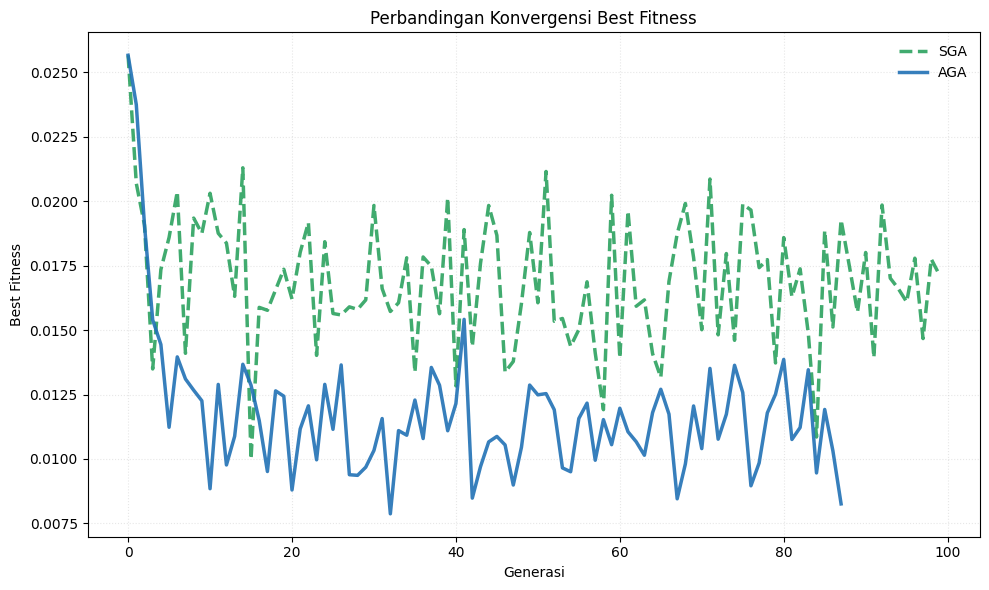

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    sga_rep["history_best"],
    linestyle="--",
    linewidth=LINEWIDTH,
    color=COLOR_SGA,
    alpha=0.9,
    label="SGA"
)

plt.plot(
    aga_rep["history_best"],
    linewidth=LINEWIDTH,
    color=COLOR_AGA,
    alpha=0.9,
    label="AGA"
)

plt.xlabel("Generasi")
plt.ylabel("Best Fitness")

plt.title(
    "Perbandingan Konvergensi Best Fitness"
)

plt.legend(frameon=False)

plt.grid(
    alpha=0.3,
    linestyle=":"
)

plt.tight_layout()

plt.savefig(
    "comparison_best_fitness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

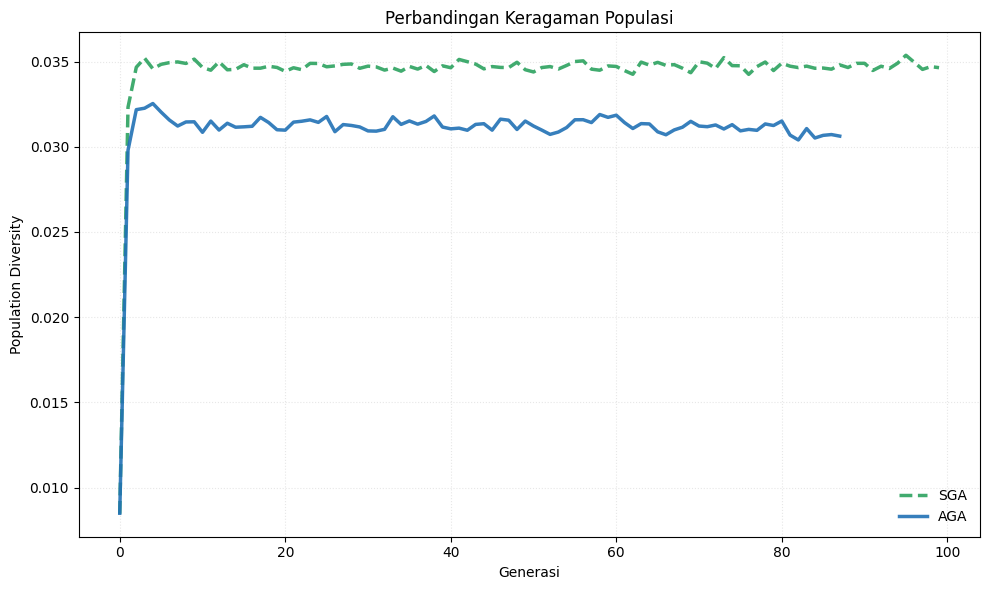

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    sga_rep["history_diversity"],
    linestyle="--",
    linewidth=LINEWIDTH,
    color=COLOR_SGA,
    alpha=0.9,
    label="SGA"
)

plt.plot(
    aga_rep["history_diversity"],
    linewidth=LINEWIDTH,
    color=COLOR_AGA,
    alpha=0.9,
    label="AGA"
)

plt.xlabel("Generasi")
plt.ylabel("Population Diversity")

plt.title(
    "Perbandingan Keragaman Populasi"
)

plt.legend(frameon=False)

plt.grid(
    alpha=0.3,
    linestyle=":"
)

plt.tight_layout()

plt.savefig(
    "comparison_diversity.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

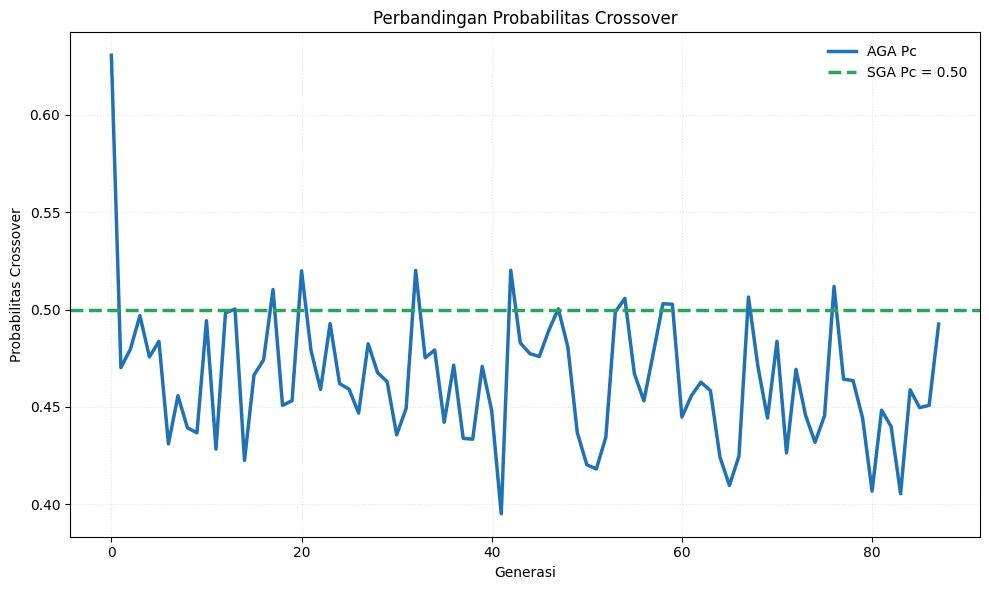

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    aga_rep["history_pc"],
    linewidth=LINEWIDTH,
    color=COLOR_AGA,
    label="AGA Pc"
)

plt.axhline(
    y=BEST_PC,
    linestyle="--",
    linewidth=LINEWIDTH,
    color=COLOR_SGA,
    label=f"SGA Pc = {BEST_PC:.2f}"
)

plt.xlabel("Generasi")
plt.ylabel("Probabilitas Crossover")

plt.title(
    "Perbandingan Probabilitas Crossover"
)

plt.legend(frameon=False)

plt.grid(
    alpha=0.3,
    linestyle=":"
)

plt.tight_layout()

plt.savefig(
    "comparison_pc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

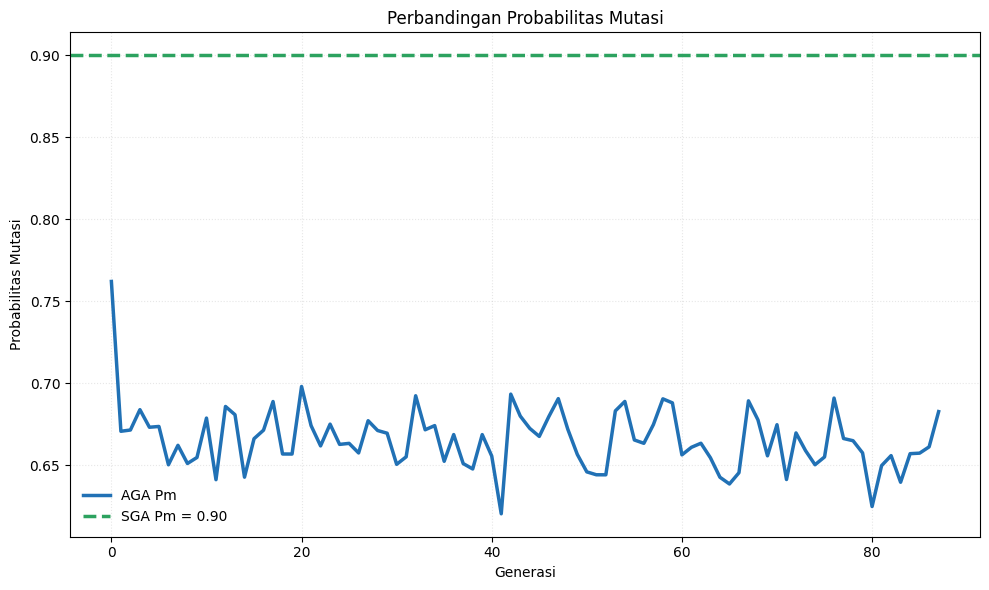

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    aga_rep["history_pm"],
    linewidth=LINEWIDTH,
    color=COLOR_AGA,
    label="AGA Pm"
)

plt.axhline(
    y=BEST_PM,
    linestyle="--",
    linewidth=LINEWIDTH,
    color=COLOR_SGA,
    label=f"SGA Pm = {BEST_PM:.2f}"
)

plt.xlabel("Generasi")
plt.ylabel("Probabilitas Mutasi")

plt.title(
    "Perbandingan Probabilitas Mutasi"
)

plt.legend(frameon=False)

plt.grid(
    alpha=0.3,
    linestyle=":"
)

plt.tight_layout()

plt.savefig(
    "comparison_pm.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Evaluasi Performa Portofolio WFO Out of Sample

### WFO ISOLATED PHASE EVALUATION

In [ ]:
# =================================================================
# ISOLATED PHASE EVALUATION
# =================================================================

def run_isolated_per_phase(
    ret_test_p,
    ret_idx_p,
    w_aga,
    w_ga,
    w_idx,
    phase_name
):

    print("\n" + "=" * 70)
    print(f"EVALUASI TERISOLASI : {phase_name.upper()}")
    print("=" * 70)

    # ============================================================
    # EQUAL WEIGHT
    # ============================================================

    equal_weight = (
        np.ones(len(ret_test_p.columns))
        / len(ret_test_p.columns)
    )

    # ============================================================
    # BACKTEST
    # ============================================================

    res_aga = run_isolated(
        w_aga,
        ret_test_p,
        f"AGA ({phase_name})"
    )

    res_ga = run_isolated(
        w_ga,
        ret_test_p,
        f"SGA ({phase_name})"
    )

    res_idx = run_isolated(
        w_idx,
        ret_idx_p,
        f"IDX30 ({phase_name})"
    )

    res_equal = run_isolated(
        equal_weight,
        ret_test_p,
        f"Equal Weight ({phase_name})"
    )

    results = [
        res_aga,
        res_ga,
        res_idx,
        res_equal
    ]

    # ============================================================
    # SUMMARY TABLE
    # ============================================================

    df_result = pd.DataFrame([
        {
            "Strategi":
                r["Method"],

            "Total Return (%)":
                r["Total Return"] * 100,

            "Annual Return (%)":
                r["Annual Return"] * 100,

            "Annual Volatility (%)":
                r["Annual Volatility"] * 100,

            "Sharpe Ratio":
                r["Sharpe Ratio"],

            "Max Drawdown (%)":
                r["Max Drawdown"] * 100,

            "Transaction Cost (%)":
                r["Total Fees Paid"] * 100
        }

        for r in results
    ])

    df_result = (
        df_result
        .sort_values(
            "Sharpe Ratio",
            ascending=False
        )
        .reset_index(drop=True)
    )

    df_result.insert(
        0,
        "Rank",
        range(1, len(df_result) + 1)
    )

    display(
        df_result.round(4)
    )

    return df_result, results


HASIL WALK-FORWARD OPTIMIZATION : FASE 1

EVALUASI TERISOLASI : FASE 1


,Rank,Strategi,Total Return (%),Annual Return (%),Annual Volatility (%),Sharpe Ratio,Max Drawdown (%),Transaction Cost (%)
0,1,AGA (Fase 1),-1.5474,-6.6621,32.6149,-0.3882,-15.7424,0.15
1,2,Equal Weight (Fase 1),-2.4597,-10.4259,35.6571,-0.4607,-18.7795,0.15
2,3,IDX30 (Fase 1),-4.7369,-19.3088,36.1163,-0.7008,-17.1428,0.15
3,4,SGA (Fase 1),-5.0989,-20.6559,33.1101,-0.8051,-17.3522,0.15


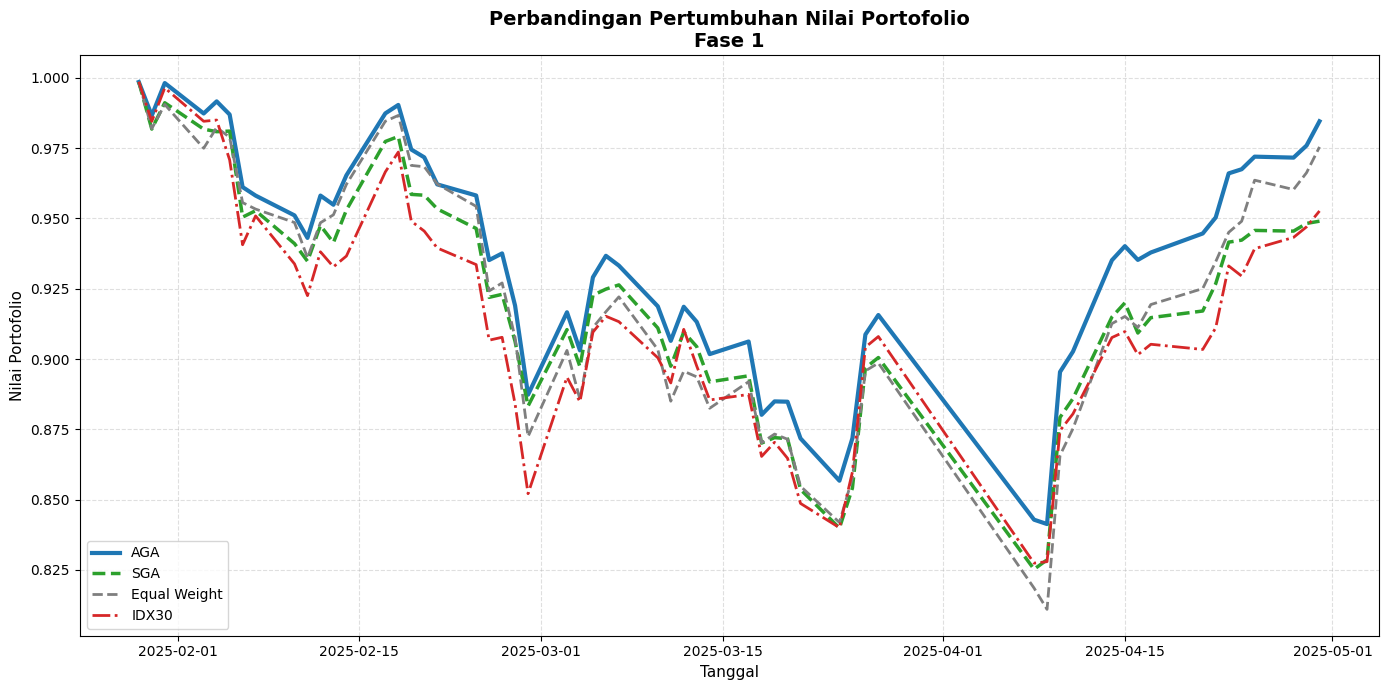

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


TABEL PERFORMA FASE 1


...


Strategi terbaik pada Fase 1: AGA (Fase 1)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


HASIL WALK-FORWARD OPTIMIZATION : FASE 2

EVALUASI TERISOLASI : FASE 2


,Rank,Strategi,Total Return (%),Annual Return (%),Annual Volatility (%),Sharpe Ratio,Max Drawdown (%),Transaction Cost (%)
0,1,AGA (Fase 2),25.8246,171.3091,17.7922,9.2911,-5.6535,0.15
1,2,SGA (Fase 2),22.5366,141.8243,17.8748,7.5987,-6.2541,0.15
2,3,Equal Weight (Fase 2),19.9154,120.1397,17.5609,6.4997,-6.6488,0.15
3,4,IDX30 (Fase 2),6.0985,29.3308,16.3216,1.4294,-7.3740,0.15


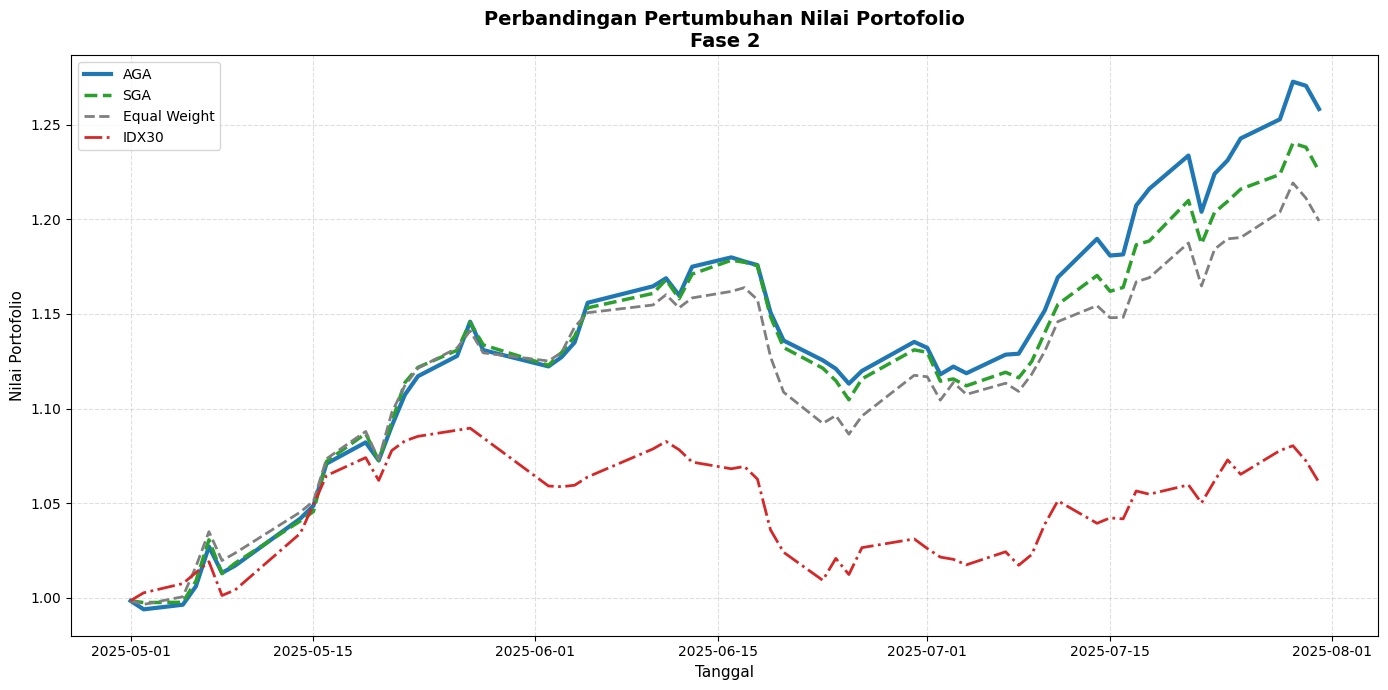

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


TABEL PERFORMA FASE 2


...


Strategi terbaik pada Fase 2: AGA (Fase 2)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


HASIL WALK-FORWARD OPTIMIZATION : FASE 3

EVALUASI TERISOLASI : FASE 3


,Rank,Strategi,Total Return (%),Annual Return (%),Annual Volatility (%),Sharpe Ratio,Max Drawdown (%),Transaction Cost (%)
0,1,AGA (Fase 3),8.2338,36.5537,16.2624,1.8788,-3.8129,0.15
1,2,Equal Weight (Fase 3),7.8951,34.8788,15.7500,1.8336,-3.7337,0.15
2,3,IDX30 (Fase 3),7.7113,33.9764,19.0369,1.4696,-6.7133,0.15
3,4,SGA (Fase 3),3.5376,14.6698,15.9206,0.5446,-5.1580,0.15


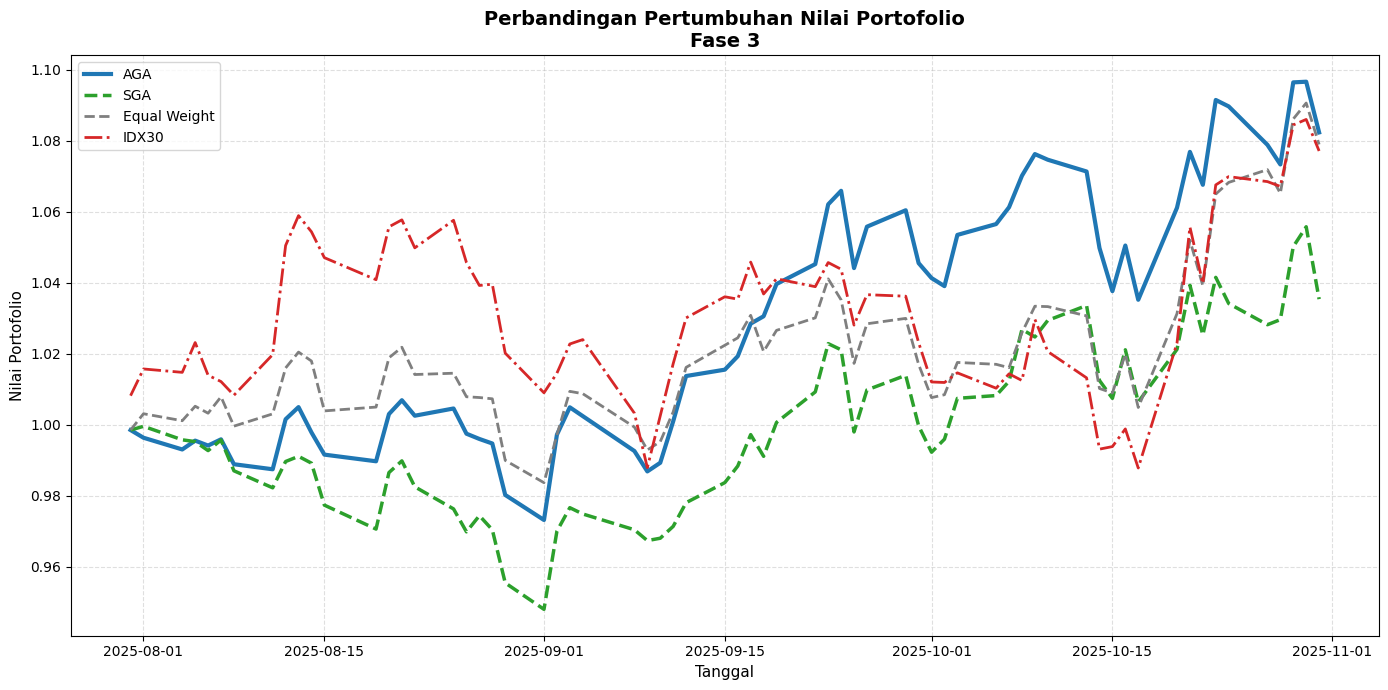

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


TABEL PERFORMA FASE 3


...


Strategi terbaik pada Fase 3: AGA (Fase 3)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


HASIL WALK-FORWARD OPTIMIZATION : FASE 4

EVALUASI TERISOLASI : FASE 4


,Rank,Strategi,Total Return (%),Annual Return (%),Annual Volatility (%),Sharpe Ratio,Max Drawdown (%),Transaction Cost (%)
0,1,SGA (Fase 4),11.0509,60.2692,12.6101,4.3036,-2.4225,0.15
1,2,Equal Weight (Fase 4),8.9500,47.0697,12.5986,3.2599,-2.9339,0.15
2,3,AGA (Fase 4),9.0204,47.4976,13.2826,3.1242,-2.3100,0.15
3,4,IDX30 (Fase 4),4.0090,19.3493,12.1106,1.1023,-2.8113,0.15


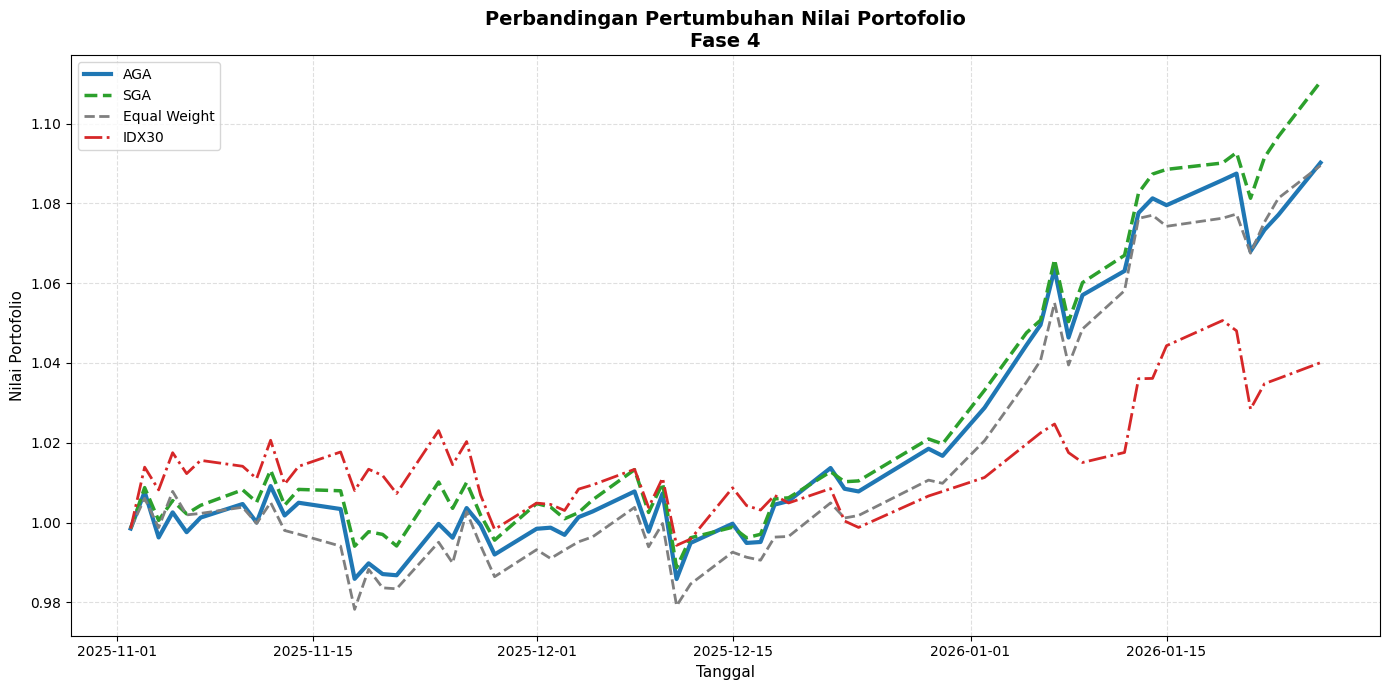

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


TABEL PERFORMA FASE 4


...

<IPython.core.display.Javascript object>


REKAP PERFORMA SELURUH FASE


,Rank,Strategi,Total Return (%),Annual Return (%),Annual Volatility (%),Sharpe Ratio,Max Drawdown (%),Transaction Cost (%),Phase
0,1,AGA (Fase 1),-1.5474,-6.6621,32.6149,-0.3882,-15.7424,0.15,Fase 1
1,2,Equal Weight (Fase 1),-2.4597,-10.4259,35.6571,-0.4607,-18.7795,0.15,Fase 1
2,3,IDX30 (Fase 1),-4.7369,-19.3088,36.1163,-0.7008,-17.1428,0.15,Fase 1
3,4,SGA (Fase 1),-5.0989,-20.6559,33.1101,-0.8051,-17.3522,0.15,Fase 1
4,1,AGA (Fase 2),25.8246,171.3091,17.7922,9.2911,-5.6535,0.15,Fase 2
5,2,SGA (Fase 2),22.5366,141.8243,17.8748,7.5987,-6.2541,0.15,Fase 2
6,3,Equal Weight (Fase 2),19.9154,120.1397,17.5609,6.4997,-6.6488,0.15,Fase 2
7,4,IDX30 (Fase 2),6.0985,29.3308,16.3216,1.4294,-7.3740,0.15,Fase 2
8,1,AGA (Fase 3),8.2338,36.5537,16.2624,1.8788,-3.8129,0.15,Fase 3
9,2,Equal Weight (Fase 3),7.8951,34.8788,15.7500,1.8336,-3.7337,0.15,Fase 3


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =================================================================
# VISUALISASI HASIL PER FASE WALK-FORWARD OPTIMIZATION
# =================================================================
#
# Digunakan pada:
# 4.4 Implementasi dan Hasil Walk-Forward Optimization
#
# Menampilkan:
# - Grafik pertumbuhan nilai portofolio setiap fase
# - Tabel performa setiap fase
# - Rekap seluruh fase
#
# =================================================================

# ============================================================
# CONTAINER
# ============================================================

isolated_results = {}

phase_names = [
    "Fase 1",
    "Fase 2",
    "Fase 3",
    "Fase 4"
]

# ============================================================
# LOOP SELURUH FASE
# ============================================================

for i, phase in enumerate(phase_names):

    print("\n" + "=" * 80)
    print(f"HASIL WALK-FORWARD OPTIMIZATION : {phase.upper()}")
    print("=" * 80)

    # ========================================================
    # BACKTEST PER FASE
    # ========================================================

    df_report, detail = run_isolated_per_phase(
        ret_test_p=list_returns[i],
        ret_idx_p=list_returns_idx[i],
        w_aga=weights_aga[i],
        w_ga=weights_ga[i],
        w_idx=weights_idx[i],
        phase_name=phase
    )

    isolated_results[phase] = {
        "report": df_report,
        "detail": detail
    }

    # ========================================================
    # VALIDASI
    # ========================================================

    for result in detail:

        assert "Portfolio Value" in result, (
            f"Portfolio Value tidak ditemukan "
            f"pada {result['Method']}"
        )

        assert len(result["Portfolio Value"]) > 0, (
            f"Portfolio Value kosong "
            f"pada {result['Method']}"
        )

    # ========================================================
    # VISUALISASI NILAI PORTOFOLIO
    # ========================================================

    plt.figure(figsize=(14, 7))

    plot_configs = [

        (detail[0], "AGA", "#1f77b4", "-", 3.0),

        (detail[1], "SGA", "#2ca02c", "--", 2.5),

        (detail[3], "Equal Weight", "#7f7f7f", "--", 2.0),

        (detail[2], "IDX30", "#d62728", "-.", 2.0)

    ]

    for result, label, color, linestyle, linewidth in plot_configs:

        plt.plot(
            result["Portfolio Value"].index,
            result["Portfolio Value"],
            label=label,
            color=color,
            linestyle=linestyle,
            linewidth=linewidth
        )

    plt.title(
        f"Perbandingan Pertumbuhan Nilai Portofolio\n{phase}",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(
        "Tanggal",
        fontsize=11
    )

    plt.ylabel(
        "Nilai Portofolio",
        fontsize=11
    )

    plt.grid(
        True,
        linestyle="--",
        alpha=0.4
    )

    plt.legend()

    plt.tight_layout()

    # ========================================================
    # SAVE FIGURE
    # ========================================================

    figure_name = (
        f"portfolio_value_"
        f"{phase.lower().replace(' ', '_')}.png"
    )

    plt.savefig(
        figure_name,
        dpi=600,
        bbox_inches="tight"
    )

    plt.show()

    files.download(
        figure_name
    )

    # ========================================================
    # SAVE CURVE DATA
    # ========================================================

    df_curve = pd.DataFrame({

        "AGA":
            detail[0]["Portfolio Value"],

        "SGA":
            detail[1]["Portfolio Value"],

        "Equal Weight":
            detail[3]["Portfolio Value"],

        "IDX30":
            detail[2]["Portfolio Value"]

    })

    curve_name = (
        f"portfolio_curve_"
        f"{phase.lower().replace(' ', '_')}.csv"
    )

    df_curve.to_csv(
        curve_name,
        index=True
    )

    files.download(
        curve_name
    )

    # ========================================================
    # TABEL PERFORMA
    # ========================================================

    print(
        f"\nTABEL PERFORMA {phase.upper()}"
    )

    display(
        df_report.round(4)
    )

    # ========================================================
    # STRATEGI TERBAIK
    # ========================================================

    best_strategy = (
        df_report.iloc[0]["Strategi"]
    )

    print(
        f"\nStrategi terbaik pada "
        f"{phase}: {best_strategy}"
    )

    # ========================================================
    # SAVE TABLE
    # ========================================================

    table_name = (
        f"performance_"
        f"{phase.lower().replace(' ', '_')}.csv"
    )

    df_report.to_csv(
        table_name,
        index=False
    )

    files.download(
        table_name
    )

    # ========================================================
    # SIMPAN KE CONTAINER
    # ========================================================

    isolated_results[phase]["performance_table"] = (
        df_report.copy()
    )

    isolated_results[phase]["curve_data"] = (
        df_curve.copy()
    )

# ============================================================
# REKAP SELURUH FASE
# ============================================================

all_phase_tables = []

for phase in phase_names:

    temp = (
        isolated_results[phase]["report"]
        .copy()
    )

    temp["Phase"] = phase

    all_phase_tables.append(temp)

df_all_phase_results = pd.concat(
    all_phase_tables,
    ignore_index=True
)

print("\n" + "=" * 80)
print("REKAP PERFORMA SELURUH FASE")
print("=" * 80)

display(
    df_all_phase_results.round(4)
)

# ============================================================
# SAVE REKAP
# ============================================================

df_all_phase_results.to_csv(
    "all_phase_performance.csv",
    index=False
)

files.download(
    "all_phase_performance.csv"
)

### WFO CUMULATIVE


✓ Seluruh backtest berhasil dijalankan.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

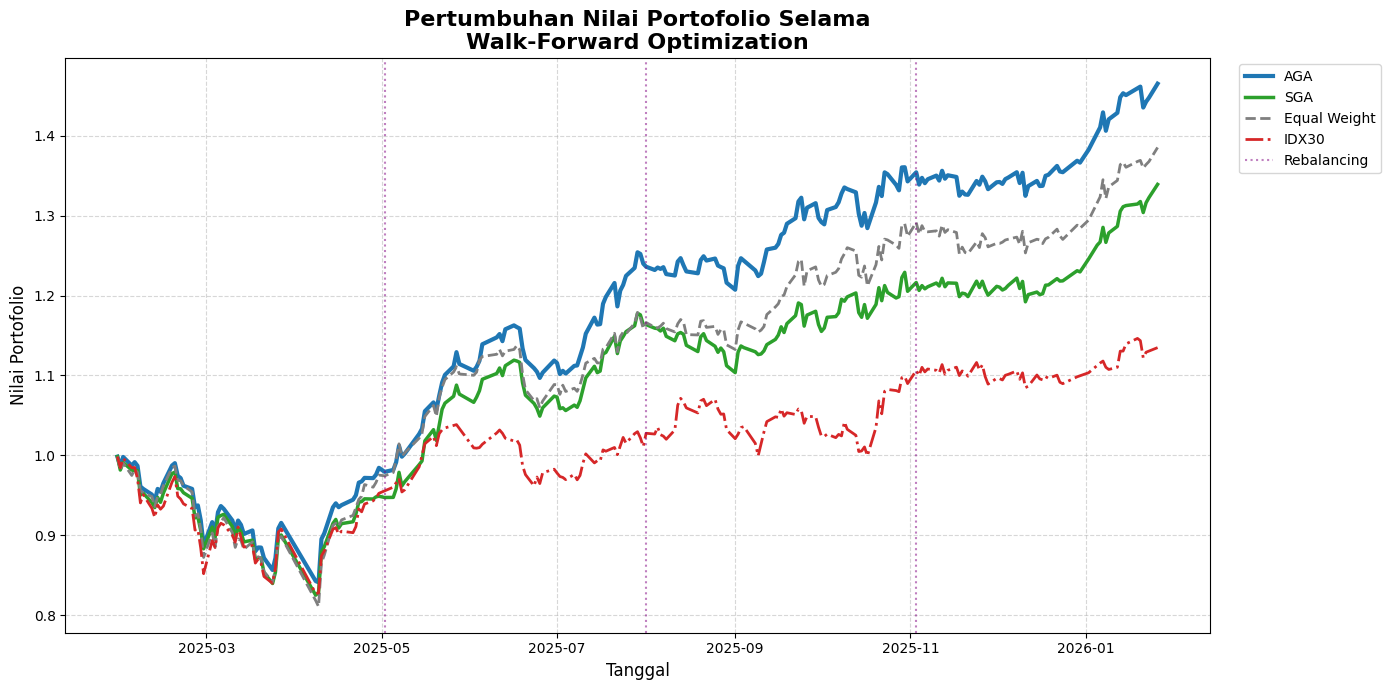

In [ ]:
# =================================================================
# WALK-FORWARD OPTIMIZATION (CUMULATIVE BACKTEST)
# =================================================================
#
# Digunakan untuk BAB Evaluasi Performa Portofolio
#
# Perbandingan:
# 1. Adaptive Genetic Algorithm (AGA)
# 2. Standard Genetic Algorithm (SGA)
# 3. Equal Weight
# IDX30
#
# Evaluasi dilakukan menggunakan:
# - Total Return
# - Annual Return
# - Annual Volatility
# - Sharpe Ratio
# - Maximum Drawdown
#
# =================================================================

from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd

# ================================================================
# BACKTEST SELURUH PERIODE WFO
# ================================================================

res_aga_rebalanced = run_rebalancing(
    weights_aga,
    list_returns,
    "AGA"
)

res_ga_rebalanced = run_rebalancing(
    weights_ga,
    list_returns,
    "SGA"
)

res_idx_rebalanced = run_rebalancing(
    weights_idx,
    list_returns_idx,
    "IDX30"
)

# ================================================================
# EQUAL WEIGHT
# ================================================================

equal_weight = (
    np.ones(len(selected_tickers))
    / len(selected_tickers)
)

res_equal_weight = run_isolated(
    equal_weight,
    returns_test,
    "Equal Weight"
)

# ================================================================
# KUMPULKAN HASIL
# ================================================================

all_results = [

    res_aga_rebalanced,
    res_ga_rebalanced,
    res_equal_weight,
    res_idx_rebalanced

]

# ================================================================
# VALIDASI
# ================================================================

for result in all_results:

    assert "Portfolio Value" in result, (
        f"Portfolio Value tidak ditemukan "
        f"pada {result['Method']}"
    )

    assert len(result["Portfolio Value"]) > 0, (
        f"Portfolio Value kosong "
        f"pada {result['Method']}"
    )

print("\n✓ Seluruh backtest berhasil dijalankan.")

# ================================================================
# GRAFIK PERTUMBUHAN NILAI PORTOFOLIO
# ================================================================

plt.figure(figsize=(14, 7))

plot_configs = [

    (
        res_aga_rebalanced,
        "#1f77b4",
        "-",
        3.0
    ),

    (
        res_ga_rebalanced,
        "#2ca02c",
        "-",
        2.5
    ),

    (
        res_equal_weight,
        "#7f7f7f",
        "--",
        2.0
    ),

    (
        res_idx_rebalanced,
        "#d62728",
        "-.",
        2.0
    )
]

for result, color, linestyle, linewidth in plot_configs:

    plt.plot(
        result["Portfolio Value"].index,
        result["Portfolio Value"],
        label=result["Method"],
        color=color,
        linestyle=linestyle,
        linewidth=linewidth
    )

# ================================================================
# TITIK REBALANCING
# ================================================================

for i in range(1, len(list_returns)):

    plt.axvline(
        x=list_returns[i].index[0],
        color="purple",
        linestyle=":",
        alpha=0.5,
        label="Rebalancing"
        if i == 1 else ""
    )

# ================================================================
# GRAFIK
# ================================================================

plt.title(
    "Pertumbuhan Nilai Portofolio Selama\n"
    "Walk-Forward Optimization",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Tanggal",
    fontsize=12
)

plt.ylabel(
    "Nilai Portofolio",
    fontsize=12
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.5
)

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.tight_layout()

# ================================================================
# SAVE FIGURE
# ================================================================

plt.savefig(
    "wfo_portfolio_growth.png",
    dpi=300,
    bbox_inches="tight"
)

files.download(
    "wfo_portfolio_growth.png"
)

plt.show()

In [ ]:
# ================================================================
# TABEL PERFORMA WFO
# ================================================================

df_report_wfo = pd.DataFrame([

    {

        "Strategi":
            result["Method"],

        "Total Return (%)":
            result["Total Return"] * 100,

        "Annual Return (%)":
            result["Annual Return"] * 100,

        "Annual Volatility (%)":
            result["Annual Volatility"] * 100,

        "Sharpe Ratio":
            result["Sharpe Ratio"],

        "Max Drawdown (%)":
            result["Max Drawdown"] * 100,

        "Biaya Transaksi (%)":
            result["Total Fees Paid"] * 100

    }

    for result in all_results

]).round(4)

# ================================================================
# RANKING SHARPE RATIO
# ================================================================

df_report_wfo = (

    df_report_wfo

    .sort_values(
        by="Sharpe Ratio",
        ascending=False
    )

    .reset_index(drop=True)

)

df_report_wfo.insert(
    0,
    "Rank",
    range(1, len(df_report_wfo) + 1)
)

print(
    "\n=== TABEL PERBANDINGAN PERFORMA WALK-FORWARD ==="
)

display(df_report_wfo)

# ================================================================
# SAVE TABEL UTAMA
# ================================================================

df_report_wfo.to_csv(
    "comparison_portfolio_performance.csv",
    index=False
)

files.download(
    "comparison_portfolio_performance.csv"
)

# ================================================================
# TABEL
# RETURN DAN RISIKO
# ================================================================

table_return_risk = df_report_wfo[
    [
        "Strategi",
        "Total Return (%)",
        "Annual Return (%)",
        "Annual Volatility (%)"
    ]
]

display(table_return_risk)

table_return_risk.to_csv(
    "table_return_risk.csv",
    index=False
)

files.download(
    "table_return_risk.csv"
)

# ================================================================
# TABEL
# SHARPE RATIO
# ================================================================

table_sharpe = df_report_wfo[
    [
        "Strategi",
        "Sharpe Ratio"
    ]
]

display(table_sharpe)

table_sharpe.to_csv(
    "table_sharpe_ratio.csv",
    index=False
)

files.download(
    "table_sharpe_ratio.csv"
)

# ================================================================
# TABEL
# MAXIMUM DRAWDOWN
# ================================================================

table_drawdown = df_report_wfo[
    [
        "Strategi",
        "Max Drawdown (%)"
    ]
]

display(table_drawdown)

table_drawdown.to_csv(
    "table_max_drawdown.csv",
    index=False
)

files.download(
    "table_max_drawdown.csv"
)

# ================================================================
# NILAI AKHIR PORTOFOLIO
# ================================================================

table_final_value = pd.DataFrame([

    {
        "Strategi":
            result["Method"],

        "Nilai Akhir Portofolio":
            result["Final Portfolio Value"]
    }

    for result in all_results

])

display(table_final_value)

table_final_value.to_csv(
    "table_final_portfolio_value.csv",
    index=False
)

files.download(
    "table_final_portfolio_value.csv"
)


=== TABEL PERBANDINGAN PERFORMA WALK-FORWARD ===


,Rank,Strategi,Total Return (%),Annual Return (%),Annual Volatility (%),Sharpe Ratio,Max Drawdown (%),Biaya Transaksi (%)
0,1,AGA,46.4914,50.5937,21.2094,2.1025,-15.7424,0.4291
1,2,Equal Weight,38.5142,41.8176,22.4410,1.5961,-18.7795,0.1500
2,3,SGA,33.8970,36.7545,21.2583,1.4467,-17.3522,0.4979
3,4,IDX30,13.4829,14.5260,22.6332,0.3767,-17.1428,0.3775


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Strategi,Total Return (%),Annual Return (%),Annual Volatility (%)
0,AGA,46.4914,50.5937,21.2094
1,Equal Weight,38.5142,41.8176,22.4410
2,SGA,33.8970,36.7545,21.2583
3,IDX30,13.4829,14.5260,22.6332


...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Strategi,Nilai Akhir Portofolio
0,AGA,1.464914
1,SGA,1.338970
2,Equal Weight,1.385142
3,IDX30,1.134829


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =================================================================
# WALK-FORWARD REBALANCING BACKTEST
# =================================================================
#
# Evaluasi performa out-of-sample selama periode pengujian
# menggunakan strategi dynamic rebalancing berbasis
# Walk-Forward Optimization (WFO).
#
# Strategi yang dibandingkan:
# 1. Adaptive Genetic Algorithm (AGA)
# 2. Standard Genetic Algorithm (GA)
# 3. IDX30 Benchmark
# 4. Equal Weight Portfolio
#
# =================================================================

# ================================================================
# DYNAMIC REBALANCING
# ================================================================

res_aga_rebalanced = run_rebalancing(
    weights_aga,
    list_returns,
    "1. AGA (4× Rebalanced)"
)

res_ga_rebalanced = run_rebalancing(
    weights_ga,
    list_returns,
    "2. GA Standar (4× Rebalanced)"
)

res_idx_rebalanced = run_rebalancing(
    weights_idx,
    list_returns_idx,
    "3. IDX30 (4× Rebalanced)"
)

# ================================================================
# EQUAL WEIGHT BASELINE
# ================================================================
#
# Portofolio benchmark sederhana dengan bobot yang
# sama pada seluruh saham selama periode pengujian.
#
# ================================================================

equal_weight = np.ones(len(selected_tickers)) / len(selected_tickers)

res_equal_weight = run_isolated(
    equal_weight,
    returns_test,
    "4. Equal Weight"
)

# ================================================================
# KUMPULKAN HASIL
# ================================================================

all_results = [
    res_aga_rebalanced,
    res_ga_rebalanced,
    res_idx_rebalanced,
    res_equal_weight
]

# ================================================================
# VALIDASI HASIL
# ================================================================

for result in all_results:

    assert "Portfolio Value" in result, \
        f"Portfolio Value tidak ditemukan pada {result['Method']}"

    assert len(result["Portfolio Value"]) > 0, \
        f"Equity curve kosong pada {result['Method']}"

print("\n✓ Seluruh backtest berhasil dijalankan.")

print("\nStrategi yang dievaluasi:")
for result in all_results:
    print(f"- {result['Method']}")


✓ Seluruh backtest berhasil dijalankan.

Strategi yang dievaluasi:
- 1. AGA (4× Rebalanced)
- 2. GA Standar (4× Rebalanced)
- 3. IDX30 (4× Rebalanced)
- 4. Equal Weight


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

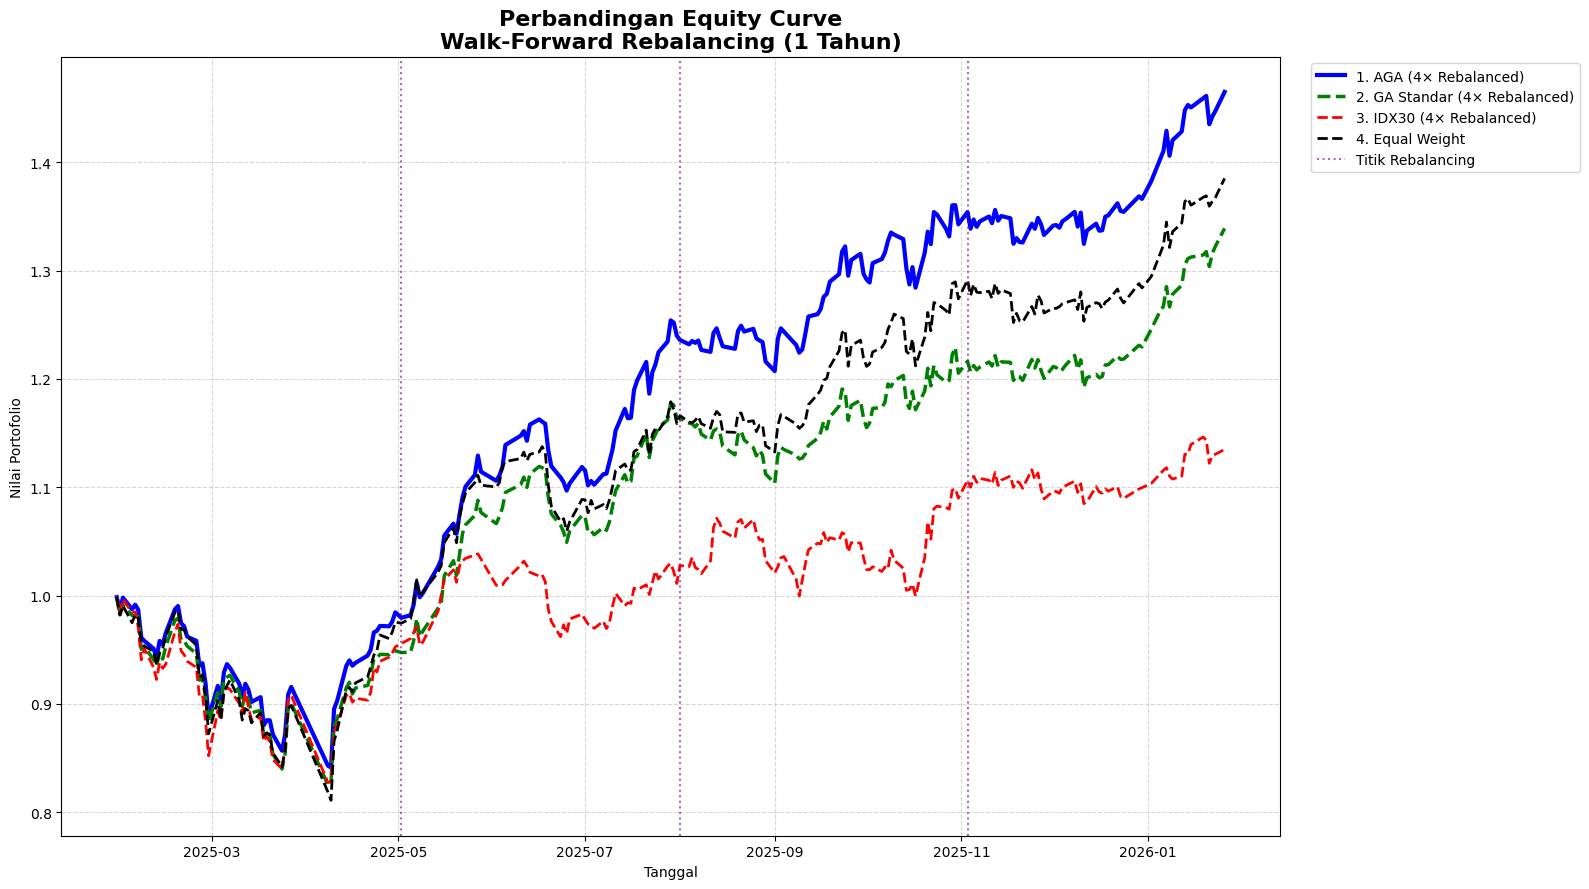

In [ ]:
# ================================================================
# HASIL YANG AKAN DITAMPILKAN
# ================================================================

all_results = [
    res_aga_rebalanced,
    res_ga_rebalanced,
    res_idx_rebalanced,
    res_equal_weight
]

# ================================================================
# VALIDASI HASIL
# ================================================================

for result in all_results:

    assert "Portfolio Value" in result, \
        f"Portfolio Value tidak ditemukan pada {result['Method']}"

    assert len(result["Portfolio Value"]) > 0, \
        f"Equity curve kosong pada {result['Method']}"

# ================================================================
# INITIALIZE FIGURE
# ================================================================

plt.figure(figsize=(16, 9))

# ================================================================
# PLOT EQUITY CURVE
# ================================================================

plot_configs = [
    (res_aga_rebalanced, "blue", 3.0, "-"),
    (res_ga_rebalanced, "green", 2.5, "--"),
    (res_idx_rebalanced, "red", 2.0, "--"),
    (res_equal_weight, "black", 2.0, "--")
]

for result, color, linewidth, linestyle in plot_configs:

    plt.plot(
        result["Portfolio Value"].index,
        result["Portfolio Value"],
        label=result["Method"],
        color=color,
        linewidth=linewidth,
        linestyle=linestyle
    )

# ================================================================
# TITIK REBALANCING
# ================================================================

for i in range(1, len(list_returns)):

    plt.axvline(
        x=list_returns[i].index[0],
        color="purple",
        linestyle=":",
        alpha=0.6,
        label="Titik Rebalancing" if i == 1 else ""
    )

# ================================================================
# GRAPH CONFIGURATION
# ================================================================

plt.title(
    "Perbandingan Equity Curve\n"
    "Walk-Forward Rebalancing (1 Tahun)",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Tanggal")
plt.ylabel("Nilai Portofolio")

plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()

plt.savefig(
    "equity_curve_wfo.png",
    dpi=300,
    bbox_inches="tight"
)

files.download("equity_curve_wfo.png")

plt.show()

In [ ]:
# ================================================================
# TABEL PERFORMA WFO
# ================================================================

df_report_wfo = pd.DataFrame([

    {
        "Strategi":
            result["Method"],

        "Total Return (%)":
            result["Total Return"] * 100,

        "Annual Return (%)":
            result["Annual Return"] * 100,

        "Annual Volatility (%)":
            result["Annual Volatility"] * 100,

        "Sharpe Ratio":
            result["Sharpe Ratio"],

        "Max Drawdown (%)":
            result["Max Drawdown"] * 100,

        "Biaya Transaksi (%)":
            result["Total Fees Paid"] * 100,

        "Nilai Akhir Portofolio":
            result["Final Portfolio Value"]
    }

    for result in all_results

]).round(4)

In [ ]:
# ================================================================
# RANKING SHARPE RATIO
# ================================================================

df_report_wfo = (
    df_report_wfo
    .sort_values(
        by="Sharpe Ratio",
        ascending=False
    )
    .reset_index(drop=True)
)

df_report_wfo.insert(
    0,
    "Rank",
    range(1, len(df_report_wfo) + 1)
)

In [ ]:
df_report_wfo

,Rank,Strategi,Total Return (%),Annual Return (%),Annual Volatility (%),Sharpe Ratio,Max Drawdown (%),Biaya Transaksi (%),Nilai Akhir Portofolio
0,1,1. AGA (4× Rebalanced),46.4914,50.5937,21.2094,2.1025,-15.7424,0.4291,1.4649
1,2,4. Equal Weight,38.5142,41.8176,22.4410,1.5961,-18.7795,0.1500,1.3851
2,3,2. GA Standar (4× Rebalanced),33.8970,36.7545,21.2583,1.4467,-17.3522,0.4979,1.3390
3,4,3. IDX30 (4× Rebalanced),13.4829,14.5260,22.6332,0.3767,-17.1428,0.3775,1.1348


In [ ]:
# ================================================================
# SAVE TABEL UTAMA
# ================================================================

df_report_wfo.to_csv(
    "comparison_portfolio_performance.csv",
    index=False
)

files.download(
    "comparison_portfolio_performance.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### COMPARATIVE PERFORMANCE VISUALIZATION

In [ ]:
# =================================================================
# FUNCTION: PERFORMANCE COMPARISON
# =================================================================

def plot_evaluation_metrics(
    results,
    title="Evaluasi Komprehensif Portofolio IDX30"
):

    # =============================================================
    # STRATEGY LABELS
    # =============================================================

    strategy_names = [
        result["Method"]
        for result in results
    ]

    # =============================================================
    # METRIC EXTRACTION
    # =============================================================

    metrics = {

        "Total Return (%)": [
            result["Total Return"] * 100
            for result in results
        ],

        "Annual Return (%)": [
            result["Annual Return"] * 100
            for result in results
        ],

        "Annual Volatility (%)": [
            result["Annual Volatility"] * 100
            for result in results
        ],

        "Sharpe Ratio": [
            result["Sharpe Ratio"]
            for result in results
        ],

        "Max Drawdown (%)": [
            result["Max Drawdown"] * 100
            for result in results
        ],

        "Transaction Cost (%)": [
            result["Total Fees Paid"] * 100
            for result in results
        ]
    }

    # =============================================================
    # WARNA KONSISTEN
    # =============================================================

    colors = [
        "#1f77b4",  # AGA
        "#2ca02c",  # SGA
        "#d62728",  # IDX30
        "#7f7f7f"   # Equal Weight
    ]

    # =============================================================
    # FIGURE
    # =============================================================

    fig, axes = plt.subplots(
        nrows=2,
        ncols=3,
        figsize=(20, 11)
    )

    fig.suptitle(
        title,
        fontsize=18,
        fontweight="bold"
    )

    # =============================================================
    # PLOT
    # =============================================================

    for ax, (metric_name, metric_values) in zip(
        axes.flat,
        metrics.items()
    ):

        bars = ax.bar(
            strategy_names,
            metric_values,
            color=colors[:len(strategy_names)],
            edgecolor="black",
            linewidth=0.8
        )

        ax.set_title(
            metric_name,
            fontsize=12,
            fontweight="bold"
        )

        ax.grid(
            axis="y",
            linestyle="--",
            alpha=0.4
        )

        ax.set_axisbelow(True)

        ax.axhline(
            y=0,
            color="black",
            linewidth=1,
            alpha=0.6
        )

        if "%" in metric_name:

            ax.yaxis.set_major_formatter(
                mtick.PercentFormatter()
            )

        max_abs = max(np.abs(metric_values))

        offset = (
            max_abs * 0.03
            if max_abs > 0
            else 0.01
        )

        for bar in bars:

            value = bar.get_height()

            ax.text(
                bar.get_x() + bar.get_width()/2,
                value + (
                    offset
                    if value >= 0
                    else -offset
                ),
                f"{value:.2f}",
                ha="center",
                va=(
                    "bottom"
                    if value >= 0
                    else "top"
                ),
                fontsize=8
            )

        ax.tick_params(
            axis="x",
            rotation=20
        )

    plt.tight_layout(
        rect=[0, 0, 1, 0.96]
    )

    filename = (
        "evaluasi_komprehensif_portofolio.png"
    )

    plt.savefig(
        filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    files.download(filename)

NameError: name 'mtick' is not defined

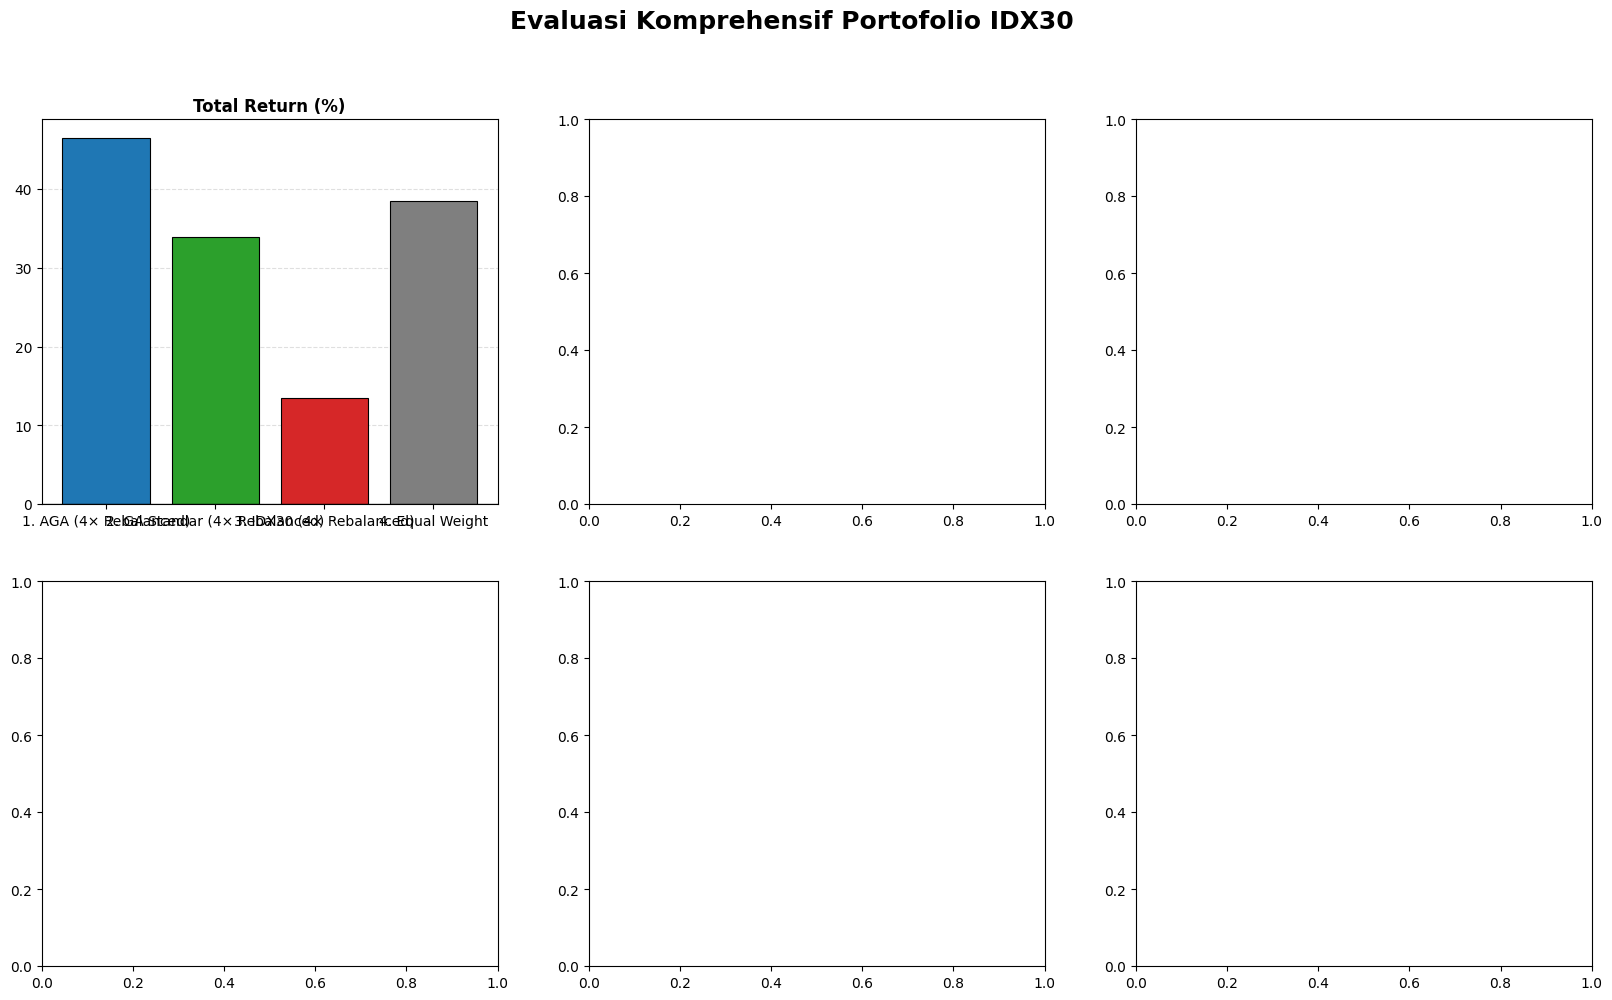

In [ ]:
plot_evaluation_metrics(all_results)